# Prepare

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from copy import deepcopy

import experiments as meas
from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

Failed to read module file 'd:\python\multimode_expts\.pixi\envs\default\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", 

Importing all classes from  D:\python\multimode_expts\experiments\dual_rail
Importing all classes from  D:\python\multimode_expts\experiments\qsim
Importing all classes from  D:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  D:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy
Pending jobs: 0


In [2]:
# Who is running these experiments??
user = 'connie'

print(f"Welcome {user}!")

Failed to read module file 'D:\python\multimode_expts\experiments\qsim\t2_cavity_fluxexcursion.py' for module 'experiments.qsim.t2_cavity_fluxexcursion': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 3793: character maps to <undefined>


Welcome connie!


In [3]:
# Initialize station to retrieve soc and configs
station = MultimodeStation(
    user = user,
    experiment_name = "260218_qsim_scramble_low_kerr",
    # experiment_name = "260224_cross_kerr",

    # hardware_config="CFG-HW-20260223-00021",
    # storage_man_file="CFG-M1-20260218-00124",
    # floquet_file="CFG-FL-20260223-00017",

    # hardware_config=“CFG-HW-20260217-00025”,
#     storage_man_file=“CFG-M1-20260216-00032",
#     floquet_file=“CFG-FL-20260216-00024”,
    # floquet_file="CFG-FL-20260218-00023",
    # storage_man_file = "CFG-M1-20260122-00013",
    # storage_man_file='CFG-M1-20260127-00034',
    # hardware_config="versions/hardware_config/CFG-HW-20260121-00006.yml",
    # floquet_file="CFG-FL-20260205-00023",
    # storage_man_file="versions/man1_storage_swap/CFG-M1-20260121-00005.csv",
    # multiphoton_config="versions/multiphoton_config/CFG-MP-20260115-00001.yml",
    
    # experiment_name = "251111_qec",
)

[STATION] Using main hardware_config version: CFG-HW-20260223-00015
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260224-00019
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00023
Directory created at: D:\experiments\260218_qsim_scramble_low_kerr\plots\autocalibration_2026-02-25
Data, plots, logs will be stored in: D:\experiments\260218_qsim_scramble_low_kerr
Hardware configs will be read from D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260223-00015.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0_230, on JHC

In [4]:
from experiments.MM_dual_rail_base import MM_dual_rail_base
def get_floquet_parameters(station, man_mode_no, stor_mode_no):
    """
    Get pulse parameters for a given storage mode. 
    Also returns prepulse and postpulse (single photon prep and meas for ge meas)

    Args:
        station: MultimodeStation object for managing frequency data.
        man_mode_no: Manipulation mode number.
        stor_mode_no: Storage mode number.

    Returns:
        A tuple containing freq, gain, ch, prepulse, and postpulse.
    """
    stor_name = 'M' + str(man_mode_no) + '-S' + str(stor_mode_no)
    freq = station.ds_floquet.get_freq(stor_name)
    gain = station.ds_floquet.get_gain(stor_name)
    length = station.ds_floquet.get_len(stor_name)
    pi_frac = station.ds_floquet.get_pi_frac(stor_name)
    ch = 'low' if freq < 1000 else 'high'

    mm_base_dummy = MM_dual_rail_base(station.hardware_cfg, station.soccfg)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist() # for ge meas, only do f0g1 and ef pi

    return freq, gain, length, pi_frac, ch, prepulse, postpulse


## Datset for Sidebands

In [ ]:
# # Override/initalize using the storage dataset
# station.ds_floquet.import_from_swap_dataset(station.ds_storage, gain_div=1, 
#                                     pi_div=[15,30,40,30,30,40,15])
# station.snapshot_floquet_storage_swap(update_main=False)

[CONFIG] Created new floquet_storage_swap version CFG-FL-20260220-00001
[CONFIG] Updated main floquet_storage_swap to CFG-FL-20260220-00001


'CFG-FL-20260220-00001'

In [5]:
station.ds_floquet.df

,stor_name,pi_frac,freq (MHz),gain (DAC units),len (mus),ramp_sigma (mus),phase_from_M1-S1 (deg),phase_from_M1-S2 (deg),phase_from_M1-S3 (deg),phase_from_M1-S4 (deg),phase_from_M1-S5 (deg),phase_from_M1-S6 (deg),phase_from_M1-S7 (deg),last_update
0,M1-S1,15,352.805189,3062,0.155040,0.005008,0.000000,3.124849,-0.010766,0.0,0.0,0.000000,-12.480106,2026-02-23 18:45:42.755970
1,M1-S2,30,524.626255,3747,0.076902,0.005008,-3.492669,0.000000,-3.957270,0.0,0.0,-2.695980,-6.049181,2026-02-20 13:38:02.633819
2,M1-S3,40,700.807420,4717,0.042413,0.005008,0.524244,4.753306,0.000000,0.0,0.0,-0.697611,-2.604314,2026-02-20 13:38:02.639194
3,M1-S4,30,880.757057,7158,0.062183,0.005008,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026-02-20 13:38:02.643865
4,M1-S5,30,1056.917751,2493,0.000000,0.005008,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026-02-20 13:38:28.962114
5,M1-S6,40,1248.717666,12761,0.045112,0.005008,0.000000,3.591544,1.160044,0.0,0.0,0.000000,-0.994739,2026-02-20 13:38:02.652875
6,M1-S7,15,1426.859045,9317,0.177648,0.005008,17.044524,4.529378,1.914683,0.0,0.0,1.045383,0.000000,2026-02-23 18:46:36.593687


In [6]:
station.ds_storage.df

,stor_name,freq (MHz),precision (MHz),pi (mus),h_pi (mus),gain (DAC units),last_update,bs_rate_coeffs_g,bs_rate_coeffs_e,freq_coeffs_g,freq_coeffs_e,gain_range_g,gain_range_e,joint_parity,dr_ac_stark_rate,dr_jp_phase
0,M1-S1,352.805051,NaN,2.352172,1.176086,3201.0,2026-02-21 23:35:47.466753,"[-1.2836395105770435e-12, 1.562696017091276e-0...","[-1.0271277777566499e-12, 1.2180616293411382e-...","[2.416727059292405e-18, -4.5676836555436063e-1...","[1.0768268119126192e-17, -2.064263277889986e-1...","[3139.0413060452993, 4847.324955685794]","[3101.448831598782, 4790.574447085415]","[352.945277297742, 3613, 3.633305169492332, 3....",NaN,NaN
1,M1-S2,524.652187,NaN,2.066902,1.153536,4127.0,2026-02-21 22:41:57.396769,"[-1.4281651019406063e-14, 2.806388588329146e-1...","[-1.3801639995141456e-14, 2.522836838797176e-1...","[3.168997973536308e-13, -5.187532491475121e-09...","[1.5879651422642703e-13, -2.550878518704292e-0...","[3768.329130027269, 4601.31156086655]","[3734.908431473402, 4579.9722200091655]","[524.7952187148321, 4126, 3.5772383566017147, ...",NaN,NaN
2,M1-S3,700.803778,NaN,1.696505,0.848253,4706.0,2026-02-22 15:09:06.016050,"[5.6421716124194476e-14, -9.54652575391602e-10...","[5.3668931659321213e-14, -9.081097405814645e-1...","[6.6423838139356915e-15, -1.0891788247748665e-...","[7.707647124928997e-15, -1.287562445371084e-10...","[3691.6725579408326, 4750.653565000185]","[3675.6253949570655, 4747.5907746229]","[700.9623452312223, 3898, 3.5574971282155756, ...",NaN,NaN
3,M1-S4,880.746898,NaN,2.347447,1.173723,5758.0,2026-02-21 14:46:37.560548,"[1.3074330883632018e-13, -3.895577532599537e-0...","[1.0440734314418517e-13, -3.1165658095145888e-...","[-1.7911015967743975e-13, 5.255316029156036e-0...","[1.183456340477642e-13, -3.4848271304432547e-0...","[7130.408130290509, 7845.801085058587]","[7106.808810897533, 7826.805864093215]",NaN,NaN,NaN
4,M1-S5,1057.057548,NaN,2.833119,1.416560,6123.0,2026-02-21 15:08:17.529746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,M1-S6,1248.744297,NaN,2.236056,0.902242,10403.0,2026-02-21 21:32:38.385875,"[-1.3966876001204708e-16, 6.9291826510581826e-...","[-2.6880391715732103e-16, 1.302538630495037e-1...","[3.8362619693507795e-16, -1.8777580937514096e-...","[4.2919235562169526e-16, -2.0702799090883976e-...","[10695.78483095193, 14045.482358218112]","[10727.35496738184, 14406.811373274053]","[1248.8666467863163, 11486, 3.482493636565513,...",NaN,NaN
6,M1-S7,1426.866000,NaN,2.983754,1.491877,9904.0,2026-02-21 13:51:03.918597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,M1-S8,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,M1-S9,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,M1-S10,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
station.ds_floquet.get_columns()

['stor_name',
 'pi_frac',
 'freq (MHz)',
 'gain (DAC units)',
 'len (mus)',
 'ramp_sigma (mus)',
 'phase_from_M1-S1 (deg)',
 'phase_from_M1-S2 (deg)',
 'phase_from_M1-S3 (deg)',
 'phase_from_M1-S4 (deg)',
 'phase_from_M1-S5 (deg)',
 'phase_from_M1-S6 (deg)',
 'phase_from_M1-S7 (deg)',
 'last_update']

In [ ]:
# # Initializing this run dataset to some guess values based on standard storage pulses

# for s in range(1, 8, 1):
#     stor_name = f'M1-S{s}'
#     pi_frac = 12
#     freq = station.ds_storage.get_freq(f'M1-S{s}')
#     gain = station.ds_storage.get_gain(f'M1-S{s}') / 3
#     length = station.ds_storage.get_h_pi(f'M1-S{s}') / 2
#     ramp_sigma = station.soccfg.cycles2us(2, gen_ch=1)
#     station.ds_floquet.update_freq(stor_name, freq)
#     station.ds_floquet.update_pi_frac(stor_name, pi_frac)
#     station.ds_floquet.update_gain(stor_name, gain)
#     station.ds_floquet.update_len(stor_name, length)
#     station.ds_floquet.update_ramp_sigma(stor_name, ramp_sigma)

# # Save dataset
# station.snapshot_floquet_storage_swap(update_main=True)

[CONFIG] Created new floquet_storage_swap version CFG-FL-20260130-00001
[CONFIG] Updated main floquet_storage_swap to CFG-FL-20260130-00001


'CFG-FL-20260130-00001'

In [16]:
# file_path_old = os.path.join(expts_path, 'floquet_storage_swap_dataset_backup.csv')
# # print(os.makedirs(file_path, exist_ok=True))
# ds_backup = floquet_storage_swap_dataset(file_path_old)
# ds_backup.df

In [17]:
# # Initializing this run dataset to some values from another csv with different columns

# for s in range(1, 8, 1):
#     stor_name = f'M1-S{s}'
#     for col in ds_thisrun.df.columns:
#         if col in ds_backup.df.columns:
#             ds_thisrun.df[col] = ds_backup.df[col].copy()
#     # ds_thisrun.update_all(stor_name, pi_frac, freq, gain, length, ramp_sigma, stark_shift) 
# ds_thisrun.df
# # Save dataset to file
# ds.df = ds_thisrun.df.copy()
# ds.save_to_file(ds.filename)

# Single shot

In [7]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    # cavity_freq=4984.373226159381,
    # cavity_gain=400,
    # cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')

Job submitted: JOB-20260225-00017 (queue position: 1)

[0.1s] Job JOB-20260225-00017: pending

[1760.9s] Job JOB-20260225-00017: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260225-00017_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:06<00:03, 498.81it/s]
[1787.6s] Job JOB-20260225-00017: completed
100%|█████████████████████████████████████| 5000/5000 [00:10<00:00, 499.32it/s]
Unrotated:
Ig 149.01081081081082 +/- 87.23172009078135 	 Qg -480.7337837837838 +/- 75.68452653866784 	 Amp g 503.2983137360675
Ie 429.63243243243244 +/- 85.42040844977492 	 Qe -115.9472972972973 +/- 112.35135181465932 	 Amp e 445.0031491443139
Rotated:
Ig -294.4956767360233 +/- 90.96583402893098 	 Qg -411.16371664504345 +/- 71

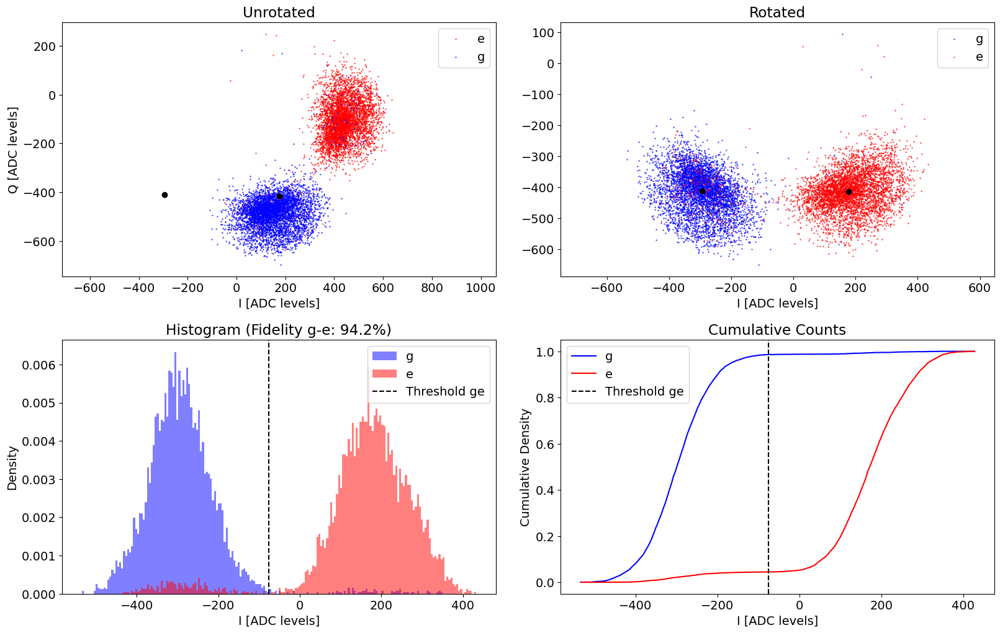

Plot saved to D:\experiments\260218_qsim_scramble_low_kerr\plots\2026-02-25_14-20-17_histogram.png
Plot reference appended to D:\experiments\260218_qsim_scramble_low_kerr\logs\2026-02-25.md
ge fidelity (%): 94.16000000000004
rotation angle (deg): -52.429766800843154
threshold ge: -75.2934577886279


In [8]:
# Execute
# =================================
ss_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
)

ss = ss_runner.execute(
    check_f=False,
    active_reset=False, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
    relax_delay=2000,
    # active_reset=True,
    # man_reset=True,
    # relax_delay=200,
)
ss.display(station)

In [27]:
station.snapshot_hardware_config(update_main=True)
station.preview_config_update()

[CONFIG] Created new hardware_config version CFG-HW-20260219-00004
[CONFIG] Updated main hardware_config to CFG-HW-20260219-00004
Comparing configurations:
Parent config file: D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260218-00040.yml
Key 'device.readout.phase' differs:
  Old value (config1): [122.6332313078414]
  New value (config2): [108.6846513902793]
Key 'device.readout.threshold' differs:
  Old value (config1): [-66.1039087814894]
  New value (config2): [-55.92911458978847]
Key 'device.readout.threshold_list' differs:
  Old value (config1): [[-66.1039087814894]]
  New value (config2): [[-55.92911458978847]]
Key 'device.readout.confusion_matrix_without_reset' differs:
  Old value (config1): [0.9843999999999998, 0.01560000000000017, 0.03660732146429285, 0.9633926785357072]
  New value (config2): [0.9877999999999997, 0.012200000000000322, 0.035799999999999964, 0.9642000000000001]
Key 'device.readout.Ie' differs:
  Old value (config1): [178.4058997358848]
  N

# Floquet pulse calibrations

## Freq chevron

In [7]:
station.ds_floquet.df

,stor_name,pi_frac,freq (MHz),gain (DAC units),len (mus),ramp_sigma (mus),phase_from_M1-S1 (deg),phase_from_M1-S2 (deg),phase_from_M1-S3 (deg),phase_from_M1-S4 (deg),phase_from_M1-S5 (deg),phase_from_M1-S6 (deg),phase_from_M1-S7 (deg),last_update
0,M1-S1,15,352.805558,3165,0.156811,0.005008,0.000000,3.124849,-0.010766,0.0,0.0,0.000000,-7.868584,2026-02-20 13:38:02.624816
1,M1-S2,30,524.626255,3747,0.076902,0.005008,-3.492669,0.000000,-3.957270,0.0,0.0,-2.695980,-6.049181,2026-02-20 13:38:02.633819
2,M1-S3,40,700.807420,4717,0.042413,0.005008,0.524244,4.753306,0.000000,0.0,0.0,-0.697611,-2.604314,2026-02-20 13:38:02.639194
3,M1-S4,30,880.757057,7158,0.062183,0.005008,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026-02-20 13:38:02.643865
4,M1-S5,30,1056.917751,2493,NaN,0.005008,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026-02-20 13:38:02.647877
5,M1-S6,40,1248.717666,12761,0.045112,0.005008,0.000000,3.591544,1.160044,0.0,0.0,0.000000,-0.994739,2026-02-20 13:38:02.652875
6,M1-S7,15,1426.868265,9834,0.198917,0.005008,8.814188,4.529378,1.914683,0.0,0.0,1.045383,0.000000,2026-02-20 13:38:02.657875


In [8]:
station.ds_floquet.update_len('M1-S5', 0)
station.ds_storage.update_pi('M1-S5', 0.01)

In [9]:
floquet_freq_chev_defaults = AttrDict(dict(
    expts = 1,
    reps = 100,
    rounds = 1,
    qubits = [0],
    ro_stor = 0, # storage mode number that gets read out in the end
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    # if 0, this means to read out man instead
    detunes=np.linspace(-0.3, 0.3, 11).tolist(),
    swept_params = ['detune', 'length'],
    normalize = False,
    active_reset = False,
    man_reset = False, 
    storage_reset = False, 
    prepulse=True,
    postpulse=True,
    init_fock=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def floquet_freq_chev_preproc(station, default_expt_cfg, **kwargs):
    assert 'init_stor' in kwargs
    expt_cfg = deepcopy(default_expt_cfg)
    ds_floquet = station.ds_floquet
    init_stor = kwargs.pop('init_stor') # storage mode number to initialize to n=1 Fock state
    lengths = np.linspace(0.01, 3.0 * ds_floquet.get_len(f'M1-S{init_stor}'), 10).tolist()

    expt_cfg.init_stor = init_stor
    expt_cfg.lengths = lengths
    expt_cfg.update(kwargs)
    print(expt_cfg)
    return expt_cfg

def floquet_freq_chev_postproc(station, expt):
    expt_cfg = expt.cfg.expt
    stor_name = f'M{expt_cfg.f0g1_cavity}-S{expt_cfg.init_stor}'

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=np.array(expt.data['ypts']),
        time=np.array(expt.data['xpts']),
        response_matrix=expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )

    chevron_analysis.analyze()
    
    best_detune = chevron_analysis.results.get('best_frequency_contrast')

    if best_detune is not None:
        pi_frac = station.ds_floquet.get_pi_frac(stor_name)
        print(f"Best detune found: {best_detune:.4f} MHz")
        current_freq = station.ds_floquet.get_freq(stor_name)
        new_freq = current_freq + best_detune
        station.ds_floquet.update_freq(stor_name, new_freq)
        print(f"Updated {stor_name} frequency to {new_freq:.4f} MHz")
        frac_pi_len = abs(np.pi / chevron_analysis.results['best_fit_params_period']['omega'])
        station.ds_floquet.update_len(stor_name, frac_pi_len)
        print(f'Updated the pi/{pi_frac} length from {station.ds_floquet.get_len(stor_name):.4f} to {frac_pi_len:.4f}')
    
    chevron_analysis.display_results()
    expt.analysis = chevron_analysis
    station.snapshot_floquet_storage_swap(update_main=False)

Running Floquet Frequency vs Length Chevron for Storage Mode 1
{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'f0g1_cavity': 1, 'detunes': [-0.3, -0.24, -0.18, -0.12, -0.06, 0.0, 0.06, 0.12, 0.18, 0.24000000000000005, 0.3], 'swept_params': ['detune', 'length'], 'normalize': False, 'active_reset': True, 'man_reset': True, 'storage_reset': [1], 'prepulse': True, 'postpulse': True, 'init_fock': True, 'init_stor': 1, 'lengths': [0.01, 0.061159383956943494, 0.11231876791388698, 0.16347815187083048, 0.21463753582777398, 0.2657969197847175, 0.31695630374166095, 0.3681156876986045, 0.41927507165554795, 0.4704344556124914], 'use_qubit_man_reset': True, 'pre_selection_reset': False, 'relax_delay': 1500}
Job submitted: JOB-20260220-00631 (queue position: 1)

[0.2s] Job JOB-20260220-00631: pending

[28.2s] Job JOB-20260220-00631: running
[WORKER] Loading FloquetChevronExperiment from experiments.qsim.floquet_chevron
[WORKER] Creating experiment instance
[WORKER]   Data file: JO

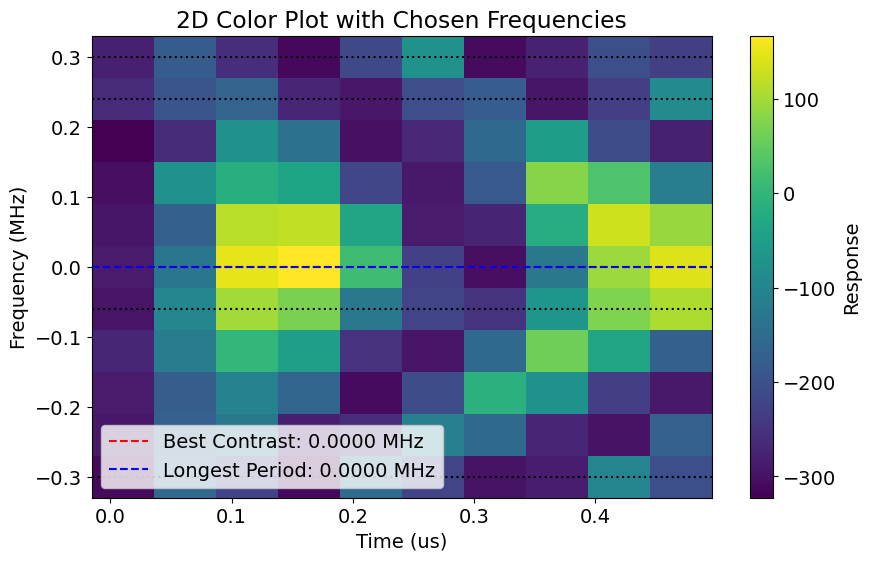

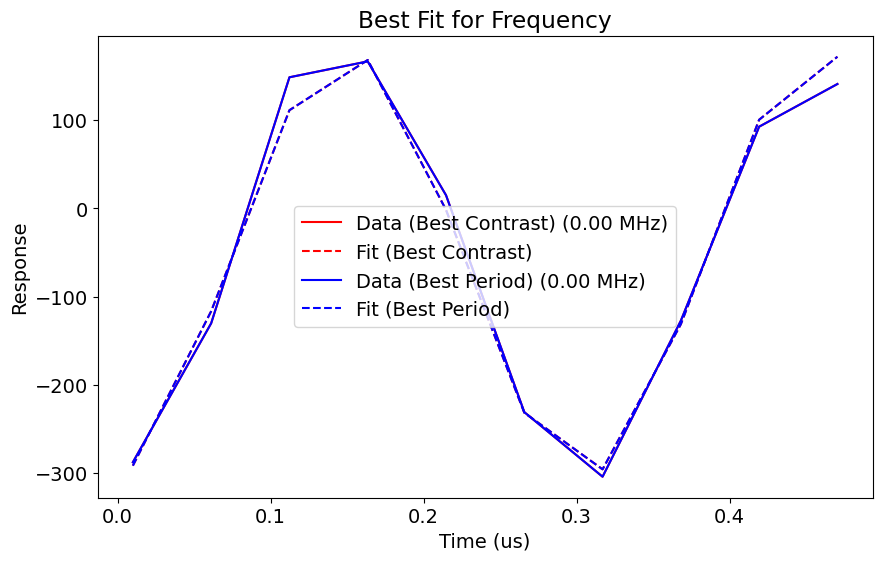

[CONFIG] Created new floquet_storage_swap version CFG-FL-20260220-00003


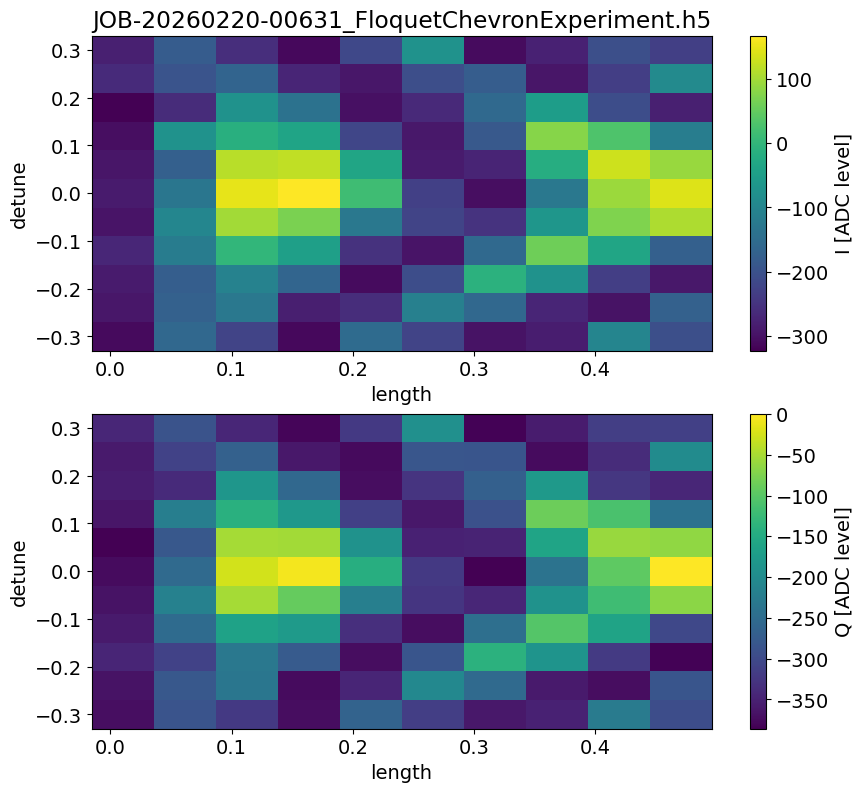

Running Floquet Frequency vs Length Chevron for Storage Mode 7
{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'f0g1_cavity': 1, 'detunes': [-0.3, -0.24, -0.18, -0.12, -0.06, 0.0, 0.06, 0.12, 0.18, 0.24000000000000005, 0.3], 'swept_params': ['detune', 'length'], 'normalize': False, 'active_reset': True, 'man_reset': True, 'storage_reset': [7], 'prepulse': True, 'postpulse': True, 'init_fock': True, 'init_stor': 7, 'lengths': [0.01, 0.07519452626718551, 0.14038905253437103, 0.20558357880155653, 0.27077810506874206, 0.3359726313359276, 0.40116715760311306, 0.4663616838702986, 0.5315562101374841, 0.5967507364046696], 'use_qubit_man_reset': True, 'pre_selection_reset': False, 'relax_delay': 1500}
Job submitted: JOB-20260220-00633 (queue position: 1)

[0.1s] Job JOB-20260220-00633: pending

[29.1s] Job JOB-20260220-00633: running
[WORKER] Loading FloquetChevronExperiment from experiments.qsim.floquet_chevron
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-

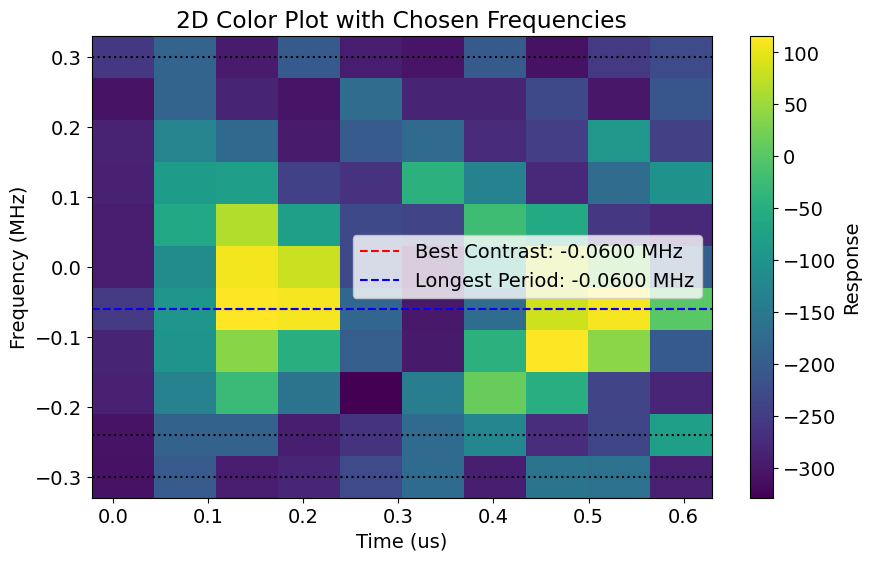

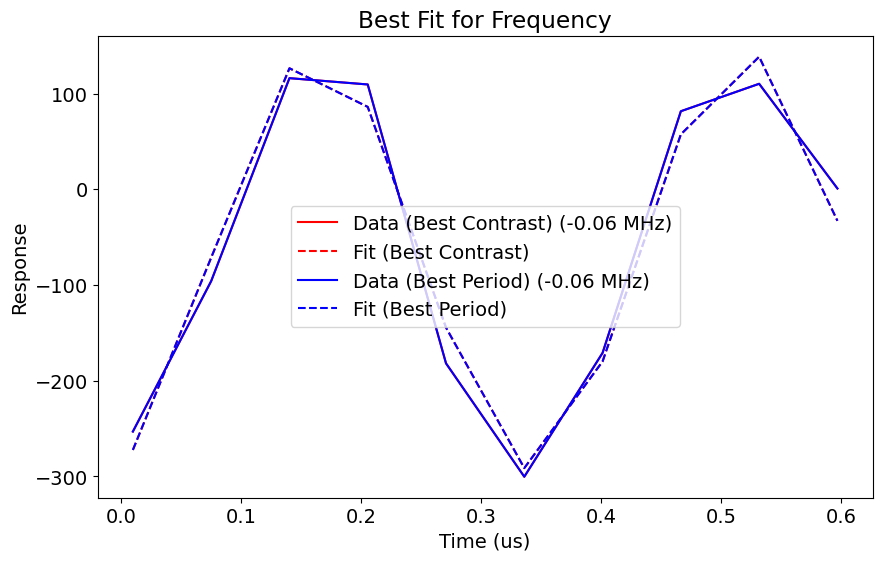

[CONFIG] Created new floquet_storage_swap version CFG-FL-20260220-00004


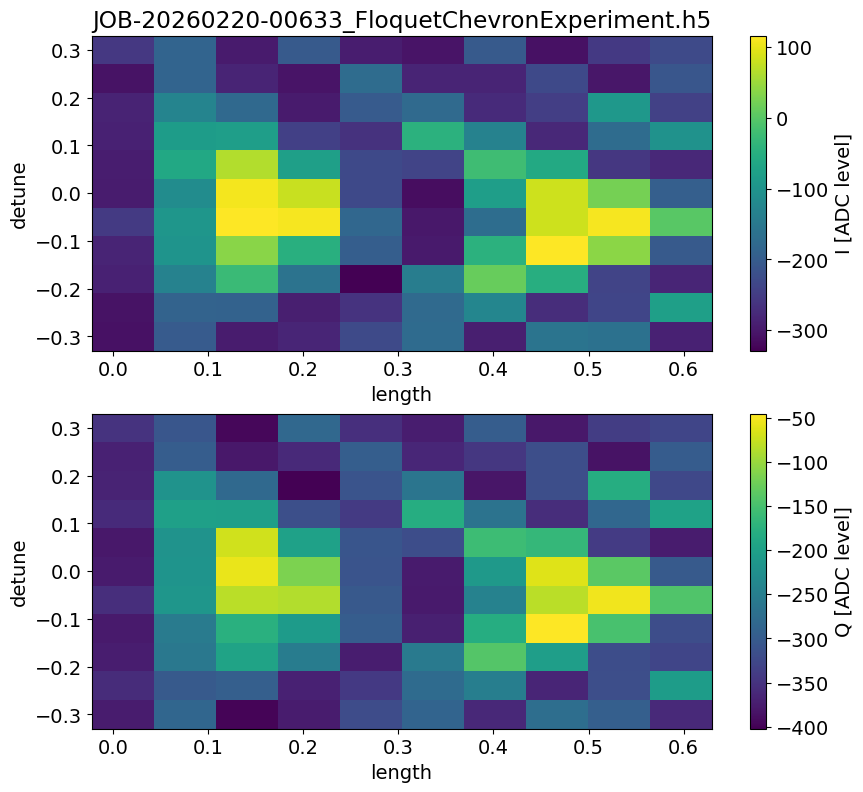

In [10]:
stor_modes_to_run = [1, 7] #list(range(1,8))
freq_len_expt = [None] * len(stor_modes_to_run)

floquet_freq_chev_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.FloquetChevronExperiment,
    ExptProgram=meas.FloquetChevronProgram,
    default_expt_cfg=floquet_freq_chev_defaults,
    preprocessor=floquet_freq_chev_preproc,
    postprocessor=floquet_freq_chev_postproc,
    job_client=client,
)

for i, init_stor in enumerate(stor_modes_to_run):
    # ds_floquet.update_gain(f'M1-S{init_stor}', ds_floquet.get_gain(f'M1-S{init_stor}') * 0.75)
    # print(f'Updating gain for M1-S{init_stor} to {ds_floquet.get_gain(f"M1-S{init_stor}")}')

    print(f'Running Floquet Frequency vs Length Chevron for Storage Mode {init_stor}')
    freq_len_expt[i] = floquet_freq_chev_runner.execute(
        init_stor=init_stor,
        # detunes=np.linspace(-1.0, 1.0, 21).tolist(),
        reps=50,

        # active_reset=False,
        # relax_delay=8000,

        active_reset=True,
        man_reset=True,
        storage_reset=[init_stor],
        use_qubit_man_reset=True,
        pre_selection_reset=False,
        relax_delay=1500,
    )
    freq_len_expt[i].display()
    plt.show()
    # clear_output(wait=True)

In [12]:
# for i in range(len(stor_modes_to_run)):
#     floquet_freq_chev_postproc(station, freq_len_expt[i])

In [11]:
station.snapshot_floquet_storage_swap(update_main=True)

[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260220-00004
[CONFIG] Updated main floquet_storage_swap to CFG-FL-20260220-00004


'CFG-FL-20260220-00004'

## Error amplification on floquet pulses

In [5]:
error_amp_floquet_defaults = AttrDict(dict(
    reps=100,
    rounds=1,
    qubits=[0],
    active_reset=False,
    man_mode_no=1,
    stor_is_dump=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500, 
    expts=25,
    qubit_start_storage='g',
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

error_amp_gain_floquet_coarse_defaults = AttrDict(dict(
    n_pulses=8,
    span=4000,
    expts=30,
))

error_amp_freq_floquet_coarse_defaults = AttrDict(dict(
    n_pulses=7,
    span=0.25,
    expts=50,
))


def error_amp_floquet_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    assert 'parameter_to_test' in kwargs 

    # construct the defaults
    expt_cfg = deepcopy(default_expt_cfg)
    if kwargs['parameter_to_test'] == 'gain':
        expt_cfg.update(error_amp_gain_floquet_coarse_defaults)
    elif kwargs['parameter_to_test'] == 'frequency':
        expt_cfg.update(error_amp_freq_floquet_coarse_defaults)

    # override with the passed kwargs
    expt_cfg.update(kwargs)

    freq, gain, length, pi_frac, ch, prepulse, postpulse = get_floquet_parameters(station, expt_cfg.man_mode_no, expt_cfg.stor_mode_no)
    pulse_type = ['floquet', f'M{expt_cfg.man_mode_no}-{"D" if expt_cfg.stor_is_dump else "S"}{expt_cfg.stor_mode_no}', f'pi/{pi_frac}', 0]

    if expt_cfg.parameter_to_test == 'frequency':
        start = freq - expt_cfg.span / 2
        step = expt_cfg.span / (expt_cfg.expts - 1)
    elif expt_cfg.parameter_to_test == 'gain':
        start = int(gain - expt_cfg.span / 2)
        step = int(expt_cfg.span / (expt_cfg.expts - 1))
    else:
        raise ValueError("parameter_to_test must be either 'frequency' or 'gain'.")
    expt_cfg.start = start
    expt_cfg.step = step
    expt_cfg.pulse_type = pulse_type 
    return expt_cfg

def error_amp_floquet_postproc(station, expt):
    expt.analyze(data=expt.data, state_fin='e')

    opt_val = expt.data['fit_avgi'][2]
    stor_name = 'M1-S' + str(expt.cfg.expt.stor_mode_no)
    if expt.cfg.expt.parameter_to_test == 'gain':
        station.ds_floquet.update_gain(stor_name, opt_val)
        print(f'Updated gain for {stor_name} to {opt_val}')
    elif expt.cfg.expt.parameter_to_test == 'frequency':
        station.ds_floquet.update_freq(stor_name, opt_val)
        print(f'Updated frequency for {stor_name} to {opt_val}')
    station.snapshot_floquet_storage_swap(update_main=False)


error_amp_floquet_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.error_amplification.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_floquet_defaults,
    preprocessor=error_amp_floquet_preproc,
    postprocessor=error_amp_floquet_postproc,
    job_client=client,
)

In [6]:
stor_modes_to_run = [7] #list(range(1,8))
error_amp_gain1 = [None] * len(stor_modes_to_run)
error_amp_freq1 = [None] * len(stor_modes_to_run)
error_amp_gain2 = [None] * len(stor_modes_to_run)
error_amp_freq2 = [None] * len(stor_modes_to_run)

### Coarse

Running M1-S7
Job submitted: JOB-20260223-00189 (queue position: 1)

[0.1s] Job JOB-20260223-00189: pending



[2.1s] Job JOB-20260223-00189: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260223-00189_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
cfg at start of acquire {'reps': 100, 'rounds': 1, 'qubits': [0], 'active_reset': True, 'man_mode_no': 1, 'stor_is_dump': False, 'man_reset': True, 'storage_reset': [7], 'relax_delay': 1500, 'expts': 50, 'qubit_start_storage': 'g', 'n_pulses': 7, 'span': 0.3, 'stor_mode_no': 7, 'parameter_to_test': 'frequency', 'use_qubit_man_reset': True, 'pre_selection_reset': False, 'start': 1426.6680276036032, 'step': 0.006122448979591836, 'pulse_type': ['floquet', 'M1-S7', 'pi/15', 0]}
  0%|                                                    | 0/7 [00:00<?, ?it/s]pulse_to_test: [1426.8180276036032, 9073, 0.1

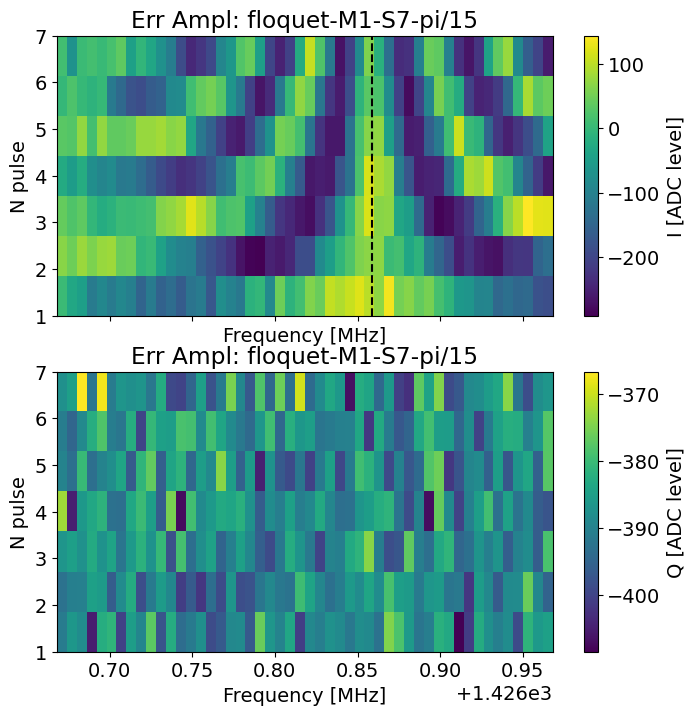

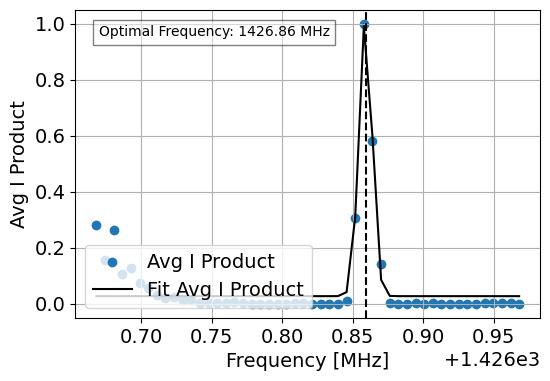

Job submitted: JOB-20260223-00190 (queue position: 1)

[0.1s] Job JOB-20260223-00190: pending

[2.1s] Job JOB-20260223-00190: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260223-00190_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
cfg at start of acquire {'reps': 100, 'rounds': 1, 'qubits': [0], 'active_reset': True, 'man_mode_no': 1, 'stor_is_dump': False, 'man_reset': True, 'storage_reset': [7], 'relax_delay': 1500, 'expts': 30, 'qubit_start_storage': 'g', 'n_pulses': 8, 'span': 2000, 'stor_mode_no': 7, 'parameter_to_test': 'gain', 'use_qubit_man_reset': True, 'pre_selection_reset': False, 'start': 8073, 'step': 68, 'pulse_type': ['floquet', 'M1-S7', 'pi/15', 0]}
  0%|                                                    | 0/8 [00

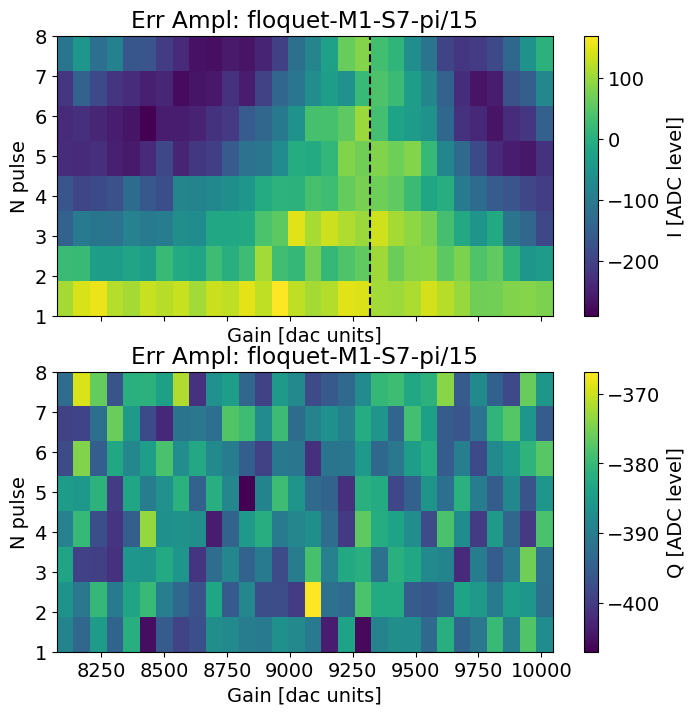

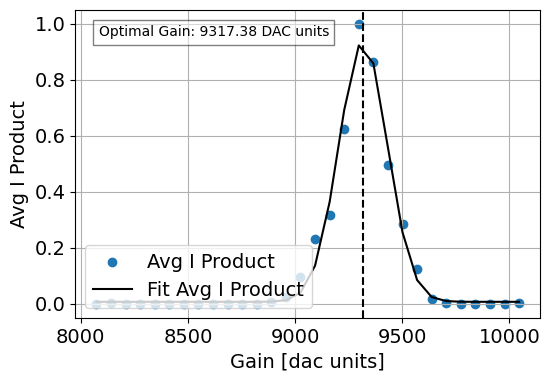

In [7]:
for i, stor_i in enumerate(stor_modes_to_run):
    stor_name = 'M1-S' + str(stor_i)
    print("Running", stor_name)
    error_amp_freq1[i] = error_amp_floquet_runner.execute(
        span=0.3,
        stor_mode_no=stor_i,
        parameter_to_test='frequency',

        active_reset=True,
        man_reset=True,
        storage_reset=[stor_i],
        use_qubit_man_reset=True,
        pre_selection_reset=False,
        relax_delay=1500,
    )
    error_amp_freq1[i].display()

    error_amp_gain1[i] = error_amp_floquet_runner.execute(
        span=2000,
        stor_mode_no=stor_i,
        parameter_to_test='gain',

        active_reset=True,
        man_reset=True,
        storage_reset=[stor_i],
        use_qubit_man_reset=True,
        pre_selection_reset=False,
        relax_delay=1500,
    )
    error_amp_gain1[i].display()

In [8]:
station.snapshot_floquet_storage_swap(update_main=True)

[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260223-00019
[CONFIG] Updated main floquet_storage_swap to CFG-FL-20260223-00019


'CFG-FL-20260223-00019'

In [36]:
# for i, stor_i in enumerate(stor_modes_to_run):
#     stor_name = 'M1-S' + str(stor_i)

#     error_amp_exp = error_amp_gain1[i]
#     error_amp_exp.analyze(state_fin='g')
#     error_amp_exp.display()
#     opt_gain = error_amp_exp.data['fit_avgi'][2]
#     station.ds_floquet.update_gain(stor_name, opt_gain)

#     error_amp_exp = error_amp_freq1[i]
#     error_amp_exp.analyze(state_fin='e')
#     error_amp_exp.display()
#     opt_freq = error_amp_exp.data['fit_avgi'][2]
#     station.ds_floquet.update_freq(stor_name, opt_freq)

### Fine

In [52]:
error_amp_freq_floquet_fine_defaults = AttrDict(dict(
        n_pulses=7,
        span=0.15,
        expts=50,
))

error_amp_gain_floquet_fine_defaults = AttrDict(dict(
        n_pulses=10,
        span=2000,
        expts=40,
))

Running M1-S1
cfg at start of acquire {'reps': 100, 'rounds': 1, 'qubits': [0], 'active_reset': False, 'man_mode_no': 1, 'stor_is_dump': False, 'man_reset': True, 'storage_reset': True, 'relax_delay': 2500, 'expts': 40, 'n_pulses': 10, 'span': 2000, 'stor_mode_no': 1, 'parameter_to_test': 'gain', 'start': 1916, 'step': 51, 'pulse_type': ['floquet', 'M1-S1', 'pi/50', 0]}
n_pts [ 1  2  3  4  5  6  7  8  9 10]


  0%|          | 0/10 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00140_ErrorAmplificationExperiment.h5
fitparams [1.4145815058908406e-05, 0.9999858541849411, 2936, 198.9]


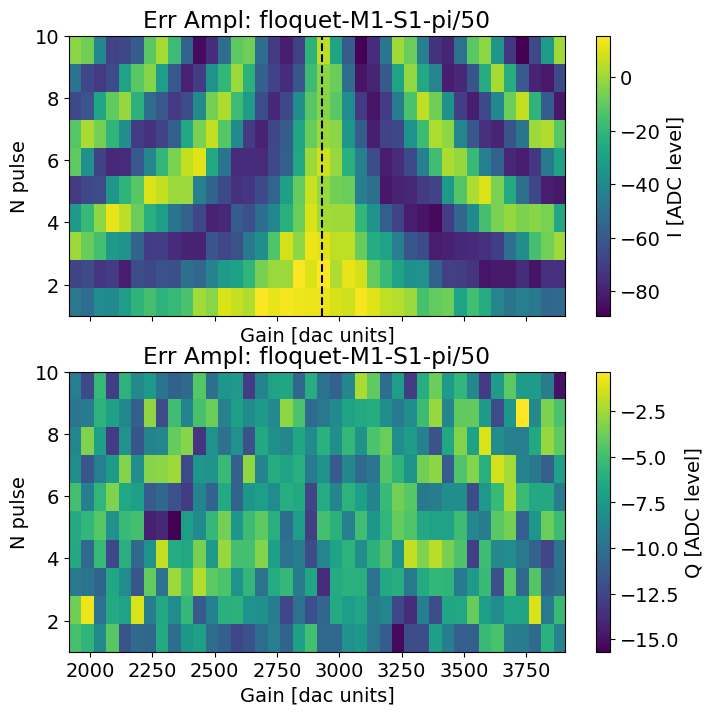

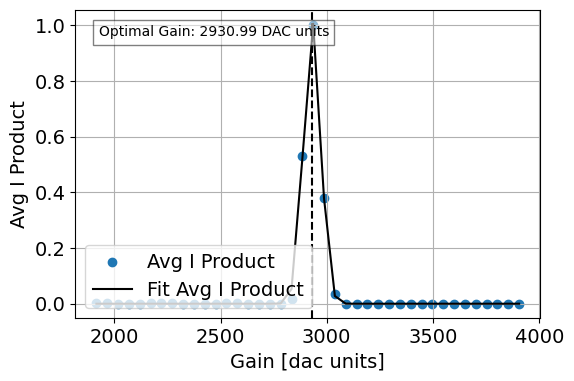

Creating or updating new csv at path: D:\python\multimode_expts\configs\floquet_storage_swap_dataset_new.csv
cfg at start of acquire {'reps': 100, 'rounds': 1, 'qubits': [0], 'active_reset': False, 'man_mode_no': 1, 'stor_is_dump': False, 'man_reset': True, 'storage_reset': True, 'relax_delay': 2500, 'expts': 50, 'n_pulses': 7, 'span': 0.15, 'stor_mode_no': 1, 'parameter_to_test': 'frequency', 'start': 352.73662702894916, 'step': 0.003061224489795918, 'pulse_type': ['floquet', 'M1-S1', 'pi/50', 0]}
n_pts [1 2 3 4 5 6 7]


  0%|          | 0/7 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00141_ErrorAmplificationExperiment.h5
fitparams [-1.0309244062894127e-05, 1.0000103092440629, 352.81009641670425, 0.014999999999997727]


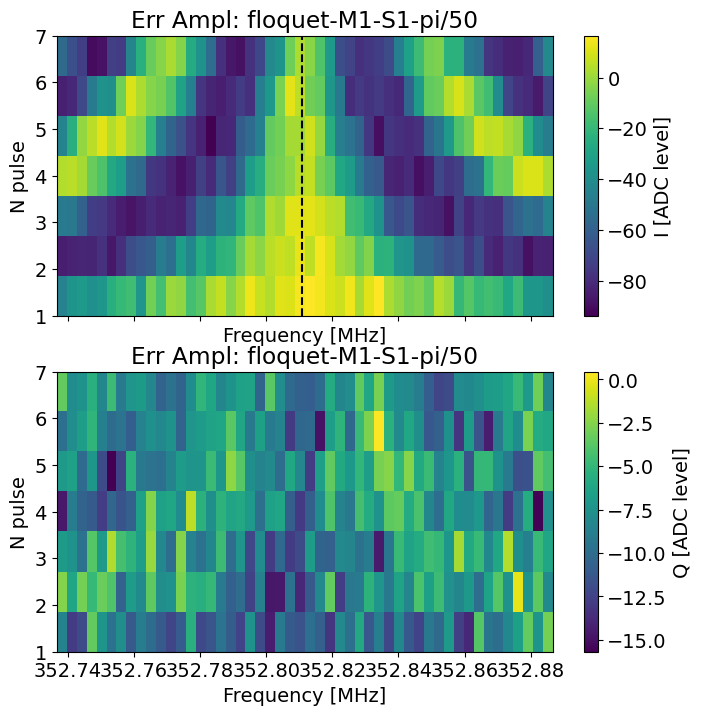

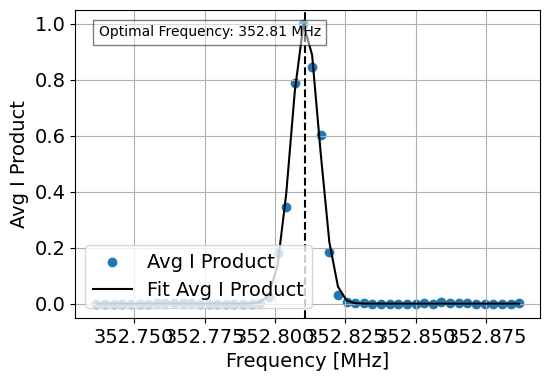

Creating or updating new csv at path: D:\python\multimode_expts\configs\floquet_storage_swap_dataset_new.csv


In [53]:
for i, stor_i in enumerate(stor_modes_to_run):
    stor_name = 'M1-S' + str(stor_i)
    print("Running", stor_name)
    error_amp_gain2[i] = error_amp_floquet_runner.run(
        stor_mode_no=stor_i,
        parameter_to_test='gain',
        go_kwargs=dict(analyze=False, progress=True, display=False),
        **error_amp_gain_floquet_fine_defaults,
    )

    error_amp_freq2[i] = error_amp_floquet_runner.run(
        stor_mode_no=stor_i,
        parameter_to_test='frequency',
        go_kwargs=dict(analyze=False, progress=True, display=False),
        **error_amp_freq_floquet_fine_defaults,
    )

In [54]:
# save new dataset to current_dataset path
station.ds_floquet.save_to_file(
    station.config_dir / station.config_thisrun.device.storage.floquet_man_stor_file
)

Creating or updating new csv at path: D:\python\multimode_expts\configs\floquet_storage_swap_dataset.csv


## Phase accumulation matrix from stark shifts

In [9]:
phase_expts = [[None for _ in range(7)] for _ in range(7)]

In [12]:
sideband_stark_error_amp_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    f0g1_cavity=1,  #  1/2 name of manipulate cavity
    init_stor=0, # storage mode number to initialize to n=1 Fock state (0=man)
    ro_stor=0, # storage mode number that gets read out in the end (0=man)
    advance_phases=np.linspace(-25, 25, 31).tolist(),
    n_pulses=np.arange(0, 24, 4).tolist(),
    swept_params=['n_pulse', 'advance_phase'],
    normalize=False, # not sure what this does
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
    init_fock=True,
))

def sideband_stark_error_amp_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_A' in kwargs
    assert 'stor_B' in kwargs

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    print(expt_cfg)
    return expt_cfg

def sideband_stark_error_amp_postproc(station, expt):
    storA = expt.cfg.expt.stor_A
    storB = expt.cfg.expt.stor_B
    stor_name = 'M1-S' + str(storA)
    from_stor_name = 'M1-S' + str(storB)
    expt.analyze(fit=True)
    expt.display(fit=True)
    # opt_phase = expt.data['fit_avgi'][2] / 2 # divide by 2 since did pi/12, -pi/12 on the from_stor swap
    opt_phase = expt.data['fit_avgi'][2] # not dividing seems to give the correct result somehow? TODO: figure out why
    print("Opt phase on", stor_name, "from", from_stor_name, ":", opt_phase)
    station.ds_floquet.update_phase_from(stor_name, from_stor_name, opt_phase)
    station.snapshot_floquet_storage_swap(update_main=False)

sideband_stark_error_amp_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.SidebandStarkAmplificationExperiment,
    ExptProgram=meas.SidebandStarkAmplificationProgram,
    default_expt_cfg=sideband_stark_error_amp_defaults,
    preprocessor=sideband_stark_error_amp_preproc,
    postprocessor=sideband_stark_error_amp_postproc,
    job_client=client,
)

Starting experiment for storage modes: 1 from 7
{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'f0g1_cavity': 1, 'init_stor': 0, 'ro_stor': 0, 'advance_phases': [-25.0, -23.333333333333332, -21.666666666666668, -20.0, -18.333333333333332, -16.666666666666664, -15.0, -13.333333333333332, -11.666666666666666, -10.0, -8.333333333333332, -6.666666666666664, -5.0, -3.333333333333332, -1.6666666666666643, 0.0, 1.6666666666666679, 3.3333333333333357, 5.0, 6.666666666666668, 8.333333333333336, 10.0, 11.666666666666671, 13.333333333333336, 15.0, 16.66666666666667, 18.333333333333336, 20.0, 21.66666666666667, 23.333333333333336, 25.0], 'n_pulses': [0, 4, 8, 12, 16, 20], 'swept_params': ['n_pulse', 'advance_phase'], 'normalize': False, 'active_reset': True, 'man_reset': True, 'storage_reset': [1, 7], 'prepulse': True, 'postpulse': True, 'init_fock': True, 'stor_A': 1, 'stor_B': 7, 'use_qubit_man_reset': True, 'pre_selection_reset': False, 'relax_delay': 1500}
Job submitted: JOB-20260223-001

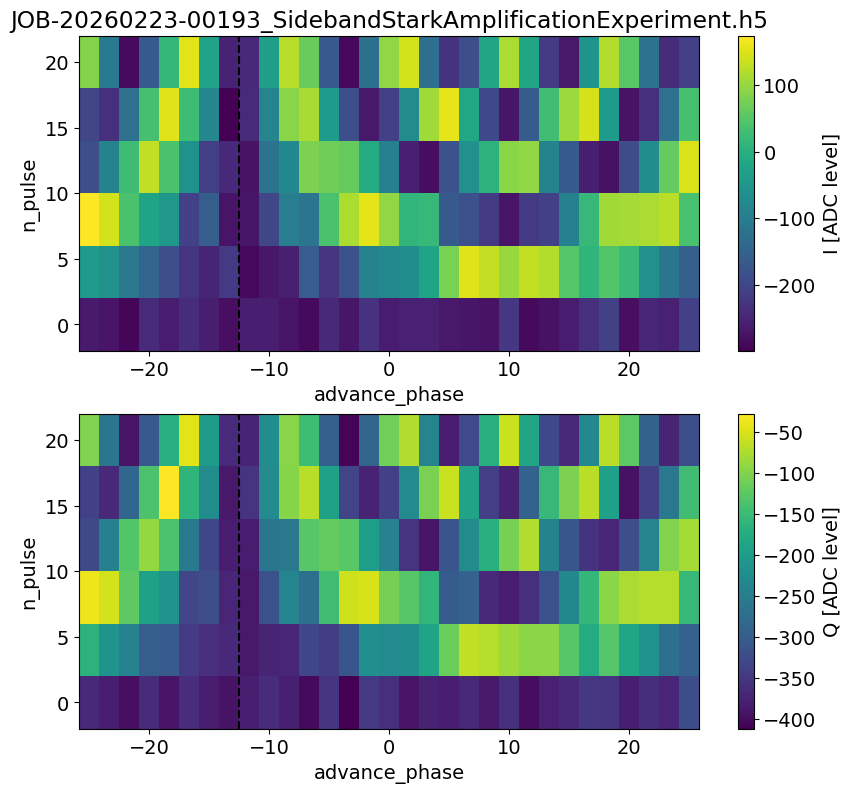

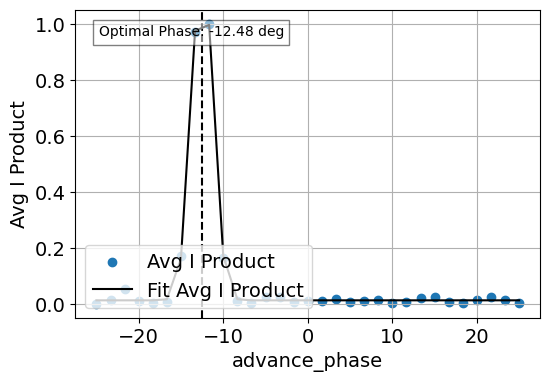

Opt phase on M1-S1 from M1-S7 : -12.480106130660333
[CONFIG] Created new floquet_storage_swap version CFG-FL-20260223-00022
Starting experiment for storage modes: 7 from 1
{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'f0g1_cavity': 1, 'init_stor': 0, 'ro_stor': 0, 'advance_phases': [-25.0, -23.333333333333332, -21.666666666666668, -20.0, -18.333333333333332, -16.666666666666664, -15.0, -13.333333333333332, -11.666666666666666, -10.0, -8.333333333333332, -6.666666666666664, -5.0, -3.333333333333332, -1.6666666666666643, 0.0, 1.6666666666666679, 3.3333333333333357, 5.0, 6.666666666666668, 8.333333333333336, 10.0, 11.666666666666671, 13.333333333333336, 15.0, 16.66666666666667, 18.333333333333336, 20.0, 21.66666666666667, 23.333333333333336, 25.0], 'n_pulses': [0, 4, 8, 12, 16, 20], 'swept_params': ['n_pulse', 'advance_phase'], 'normalize': False, 'active_reset': True, 'man_reset': True, 'storage_reset': [7, 1], 'prepulse': True, 'postpulse': True, 'init_fock': True, 'stor_A': 7, 

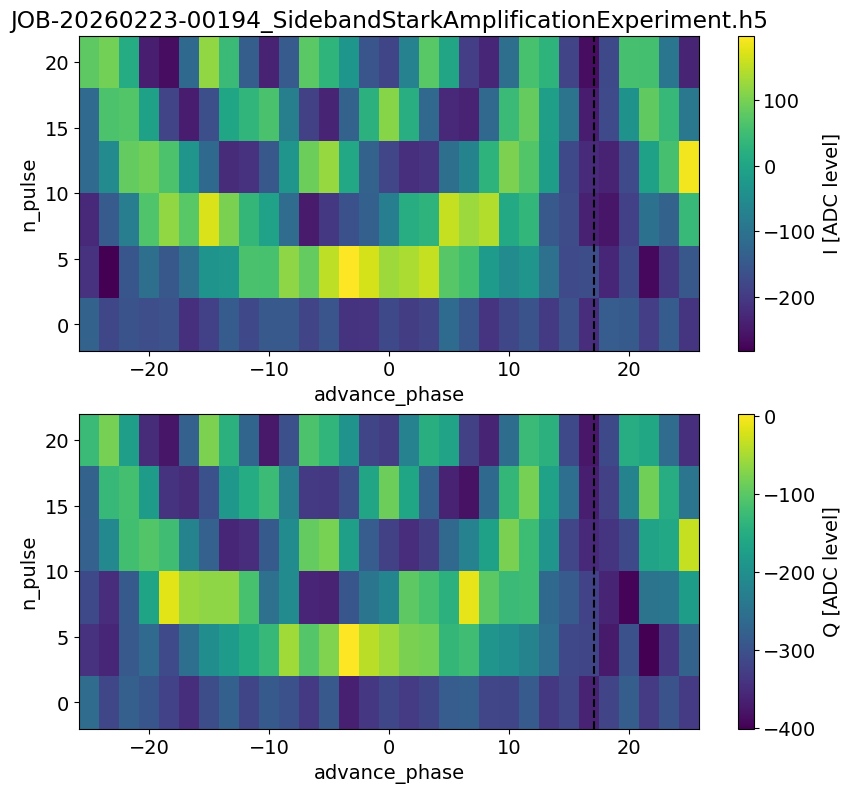

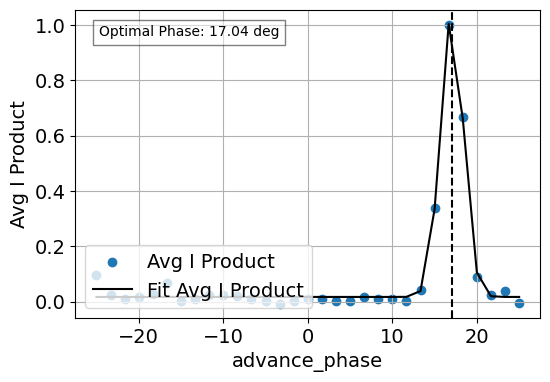

Opt phase on M1-S7 from M1-S1 : 17.044524443984386
[CONFIG] Created new floquet_storage_swap version CFG-FL-20260223-00023


In [13]:
stor_modes_to_run = [1, 7] #list(range(1,8))

for iA, init_storA in enumerate(stor_modes_to_run): #range(1,8):
    for iB, init_storB in enumerate(stor_modes_to_run): #range(1,8):
        if init_storA == init_storB:
            continue
        print("Starting experiment for storage modes:", init_storA, "from", init_storB)

        # expt_params = dict(
        #     stor_A = init_storA, # storage mode on whose phase accumulation we will evaluate (relative to the stark shifted frequency)
        #     stor_B = init_storB, # storage mode on which a drive is applied which contributes the phase accumulation
        # )
        # print("phase sweep", expt_params["advance_phases"])
    
        # qbe = meas.SidebandStarkAmplificationExperiment(
        #     soccfg=soc,
        #     path=expt_path,
        #     prefix=f"SidebandStarkAmplification_S{expt_params['stor_A']}_S{expt_params['stor_B']}",
        #     config_file=config_path,
        #     expt_params=expt_params,
        #     program=meas.SidebandStarkAmplificationProgram,
        #     progress=True)
    
        # qbe.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
        # qbe.go(analyze=False, display=True, progress=True, save=True)
        qbe = sideband_stark_error_amp_runner.execute(
            stor_A=init_storA,
            stor_B=init_storB,
            reps=50,

            # active_reset=False,
            # relax_delay=8000,

            active_reset=True,
            man_reset=True,
            storage_reset=[init_storA, init_storB],
            use_qubit_man_reset=True,
            pre_selection_reset=False,
            relax_delay=1500,
        )
        phase_expts[init_storA - 1][init_storB - 1] = qbe

In [14]:
station.snapshot_floquet_storage_swap(update_main=True)

[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260223-00023
[CONFIG] Updated main floquet_storage_swap to CFG-FL-20260223-00023


'CFG-FL-20260223-00023'

# AC Stark calibration with pi/2 dual rail

  0%|          | 0/31 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00000_FloquetPhaseCal_2on3_via1.h5
('Error in saving cfg into datafile (experiment.py):', TypeError('Object of type floquet_storage_swap_dataset is not JSON serializable'))


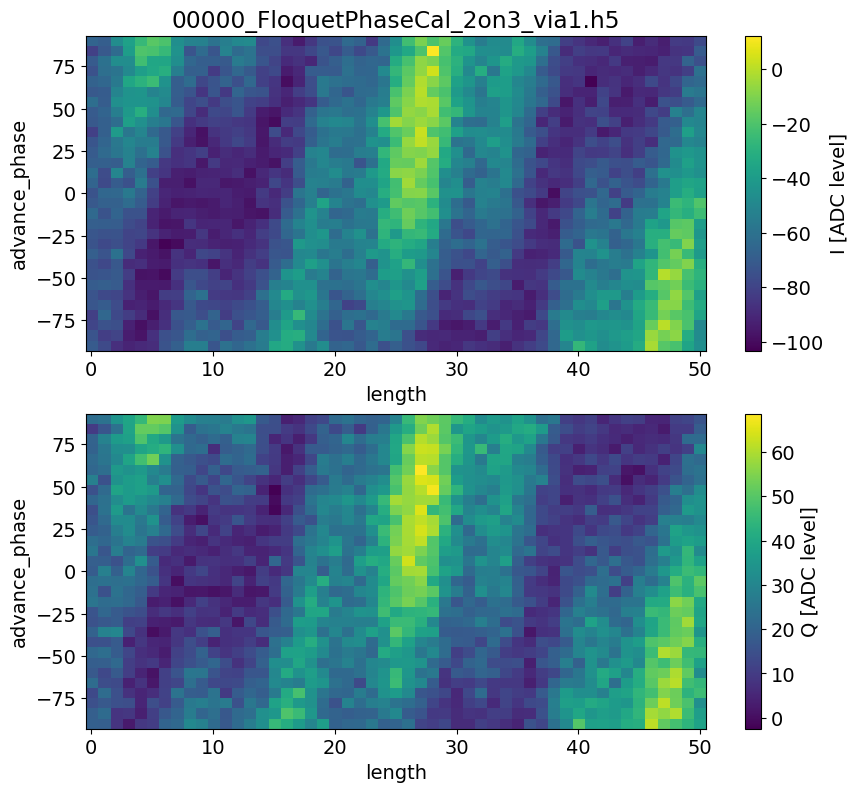

In [25]:
expt_params = dict(
    expts = 1,
    reps = 100,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 0, # storage mode number to initialize to n=1 Fock state
    ro_stor = 0, # storage mode number that gets read out in the end
    stor_row = 3,
    stor_col = 2,
    stor_idle = 1,
    # if 0, this means to read out man instead
    # detunes=np.linspace(-0.2, 0.2, 10).tolist(),
    # lengths=np.linspace(0, 1.5 * ds_thisrun.get_len(f'M1-S{init_stor}'), 10).tolist(),
    # swept_params = ['detune', 'length'],
    advance_phases=np.linspace(-90,90,31).tolist(),
    lengths=np.linspace(0.1, 50, 51).tolist(),
    swept_params = ['advance_phase', 'length'],
    # usage: if you want to sweep cfg.expt.paramName, 
    # include paramName here in this list 
    # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
    # (You want a list instead of numpy array for better yaml export.)
    # Currently handles 1D and 2D sweeps and plots only.
    # For 2D, order is [outer, inner].
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    ds_thisrun=ds_thisrun,
)

qbe = meas.FloquetPhaseCalExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetPhaseCal_{expt_params['stor_col']}on{expt_params['stor_row']}_via{expt_params['stor_idle']}",
    config_file=config_path,
    expt_params=expt_params,
    program=meas.FloquetPhaseCalProgram,
    progress=True)

qbe.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
qbe.go(analyze=False, display=True, progress=True, save=True)
# freq_len_expt[i] = qbe

## Use the period of the 2 storage + M1 random walk to error amplify the phase calibration

In [ ]:
# storA = 2
# storB = 3

for storA, storB in [(2,3),(2,6),(3,6),(2,7),(3,7),(6,7)]:
    print("Starting experiment for storage modes:", storA, "from", storB)
    n_scramble_cycles = [0,1,2,3]
    pifracA, pifracB = ds_thisrun.get_pi_frac(f'M1-S{storA}'), ds_thisrun.get_pi_frac(f'M1-S{storB}')
    n_floquet_per_scramble = int(np.round(2*(pifracA**2 + pifracB**2)**0.5))
    # = for omega1=omega2 the period is 2sqrt(2) * pi_frac

    floquet_cycles = n_floquet_per_scramble * n_scramble_cycles

    expt_params = dict(
        expts = 1,
        reps = 50,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = storA, # storage mode number to initialize to n=1 Fock state (0 = man)
        ro_stor = storB, # storage mode number that gets read out in the end (0 = man)
        storA = storA, # storage mode on whose phase accumulation we will evaluate (relative to the stark shifted frequency)
        storB = storB, # storage mode on which a drive is applied which contributes the phase accumulation
        storA_advance_phases = np.linspace(-15, 15, 61).tolist(),
        storB_advance_phases = np.linspace(-15, 15, 61).tolist(),
        n_scramble_cycles = n_scramble_cycles,
        n_floquet_per_scramble = n_floquet_per_scramble,
        # usage: if you want to sweep cfg.expt.paramName, 
        # include paramName here in this list 
        # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
        # (You want a list instead of numpy array for better yaml export.)
        # Currently handles 1D and 2D sweeps and plots only.
        # For 2D, order is [outer (y), inner (x)].
        normalize = False, # not sure what this does
        active_reset = False,
        man_reset = True, 
        storage_reset = True, 
        ds_thisrun=ds_thisrun,
        prepulse=True,
        postpulse=True,
    )
    print("n_scramble_cycles", expt_params["n_scramble_cycles"])
    print("phase sweep A", expt_params["storA_advance_phases"])
    print("phase sweep B", expt_params["storB_advance_phases"])

    qbe = meas.FloquetCalibrationAmplificationExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"FloquetCalibrationAmplificationExperiment_S{expt_params['storA']}_S{expt_params['storB']}",
        config_file=config_path,
        expt_params=expt_params,
        program=meas.FloquetCalibrationProgram,
        progress=True)

    qbe.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
    qbe.acquire(progress=True, debug=True)
    qbe.save_data()

Starting experiment for storage modes: 2 from 3
n_scramble_cycles [0, 1, 2, 3]
phase sweep A [-15.0, -14.5, -14.0, -13.5, -13.0, -12.5, -12.0, -11.5, -11.0, -10.5, -10.0, -9.5, -9.0, -8.5, -8.0, -7.5, -7.0, -6.5, -6.0, -5.5, -5.0, -4.5, -4.0, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0]
phase sweep B [-15.0, -14.5, -14.0, -13.5, -13.0, -12.5, -12.0, -11.5, -11.0, -10.5, -10.0, -9.5, -9.0, -8.5, -8.0, -7.5, -7.0, -6.5, -6.0, -5.5, -5.0, -4.5, -4.0, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0]
Starting experiment for n_scramble_cycle 0 with total floquet cycles 100


  0%|          | 0/61 [00:00<?, ?it/s]

Starting experiment for n_scramble_cycle 1 with total floquet cycles 300


  0%|          | 0/61 [00:00<?, ?it/s]

Starting experiment for n_scramble_cycle 2 with total floquet cycles 500


...

  0%|          | 0/61 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00000_FloquetCalibrationAmplificationExperiment_S2_S3.h5
Starting experiment for storage modes: 2 from 6
n_scramble_cycles [0, 1, 2, 3]
phase sweep A [-15.0, -14.5, -14.0, -13.5, -13.0, -12.5, -12.0, -11.5, -11.0, -10.5, -10.0, -9.5, -9.0, -8.5, -8.0, -7.5, -7.0, -6.5, -6.0, -5.5, -5.0, -4.5, -4.0, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0]
phase sweep B [-15.0, -14.5, -14.0, -13.5, -13.0, -12.5, -12.0, -11.5, -11.0, -10.5, -10.0, -9.5, -9.0, -8.5, -8.0, -7.5, -7.0, -6.5, -6.0, -5.5, -5.0, -4.5, -4.0, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0]
Starting experiment for n_scramble_cycle 0 with total floquet cycles 100


  0%|          | 0/61 [00:00<?, ?it/s]

Starting experiment for n_scramble_cycle 1 with total floquet cycles 300


  0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
qbe.save_data()
# qbe.analyze()

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00000_FloquetCalibrationAmplificationExperiment_S1_S2.h5


array([1])

# Qsim

## Initial random try

In [24]:
import multimode_expts.experiments.qsim.qsim_experiments as qsim_exp

experiment_name = 'storage_sweep'

flqSwap = qsim_exp.floquet_swap_class(
    soccfg=soc, 
    path=expt_path, 
    prefix=experiment_name, 
    config_file=config_path, 
    exp_param_file=os.path.join(curr_path, 'configs', 'qsim_exp_cfg.yml')
)

flqSwap.run_sweep( sweep_experiment_name = experiment_name)

Loaded:  {'init_storage': 4, 'start': 0.007, 'step': 60, 'qubits': [0], 'expts': 100, 'reps': 100, 'rounds': 1, 'flux_drive': ['low', 874, 9000, 0.05], 'prepulse': True, 'postpulse': True, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'update_post_pulse_phase': [False, 1.07], 'floquet_cycles': 1}
Config is:  {'init_storage': 4, 'start': 0.007, 'step': 60, 'qubits': [0], 'expts': 100, 'reps': 100, 'rounds': 1, 'flux_drive': ['low', 874, 9000, 0.05], 'prepulse': True, 'postpulse': True, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'update_post_pulse_phase': [False, 1.07], 'floquet_cycles': 1}


  0%|          | 0/7 [00:00<?, ?it/s]

[[3569.4780438937673, 3426.2579958470365, 2009.03, 349.1], [11161, 8483, 15000, 3000], [0.0, 0.0, 0.6312695353859414, 0.7865725563918275], [0, 0, 0, 0], [2, 2, 0, 1], ['g', 'g', 'flat_top', 'flat_top'], [0.035, 0.035, 0.005, 0.005]]
[[3569.4780438937673, 3426.2579958470365, 2009.03, 349.1], [11161, 8483, 15000, 3000], [0.0, 0.0, 0.6312695353859414, 0.7865725563918275], [0, 0, 0, 0], [2, 2, 0, 1], ['g', 'g', 'flat_top', 'flat_top'], [0.035, 0.035, 0.005, 0.005]]
[[3569.4780438937673, 3426.2579958470365, 2009.03, 349.1], [11161, 8483, 15000, 3000], [0.0, 0.0, 0.6312695353859414, 0.7865725563918275], [0, 0, 0, 0], [2, 2, 0, 1], ['g', 'g', 'flat_top', 'flat_top'], [0.035, 0.035, 0.005, 0.005]]
[[3569.4780438937673, 3426.2579958470365, 2009.03, 349.1], [11161, 8483, 15000, 3000], [0.0, 0.0, 0.6312695353859414, 0.7865725563918275], [0, 0, 0, 0], [2, 2, 0, 1], ['g', 'g', 'flat_top', 'flat_top'], [0.035, 0.035, 0.005, 0.005]]
[[3569.4780438937673, 3426.2579958470365, 2009.03, 349.1], [11161, 8

## Sideband Ramsey

This is starting to test our channel phases: when we switch from one channel generator freq to diff freq (activating different storage swaps), does our code preserve phase coherence between the successive (partial) pulses. 

We start from a simple M1-Sx Ramsey: qubit ge, qubit ef, f0g1 to initialize man1 into |1>, then do pi/2 on the beam splitter and wait and another pi/2.

In [72]:
from multimode_expts.experiments.qsim.sideband_ramsey_scramble import SidebandRamseyExperiment

In [24]:
from multimode_expts.experiments.qsim.sideband_ramsey import SidebandRamseyExperiment

  0%|          | 0/10000 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00001_SidebandRamsey_M1S1.h5
Current pi pulse frequency: 3571.709750355705
Fit frequency from I [MHz]: 0.3089569532058502 +/- 0.0008688187687284037
Suggested new pi pulse frequency from fit I [MHz]:
 	3571.600793402499
 	3572.2187073089112
T2 Ramsey from fit I [us]: 151.35019342478705
Fit frequency from Q [MHz]: 0.3081087340680849 +/- 0.0012433866916204631
Suggested new pi pulse frequencies from fit Q [MHz]:
 	3571.601641621637
 	3572.2178590897734
T2 Ramsey from fit Q [us]: 91.19102876798401


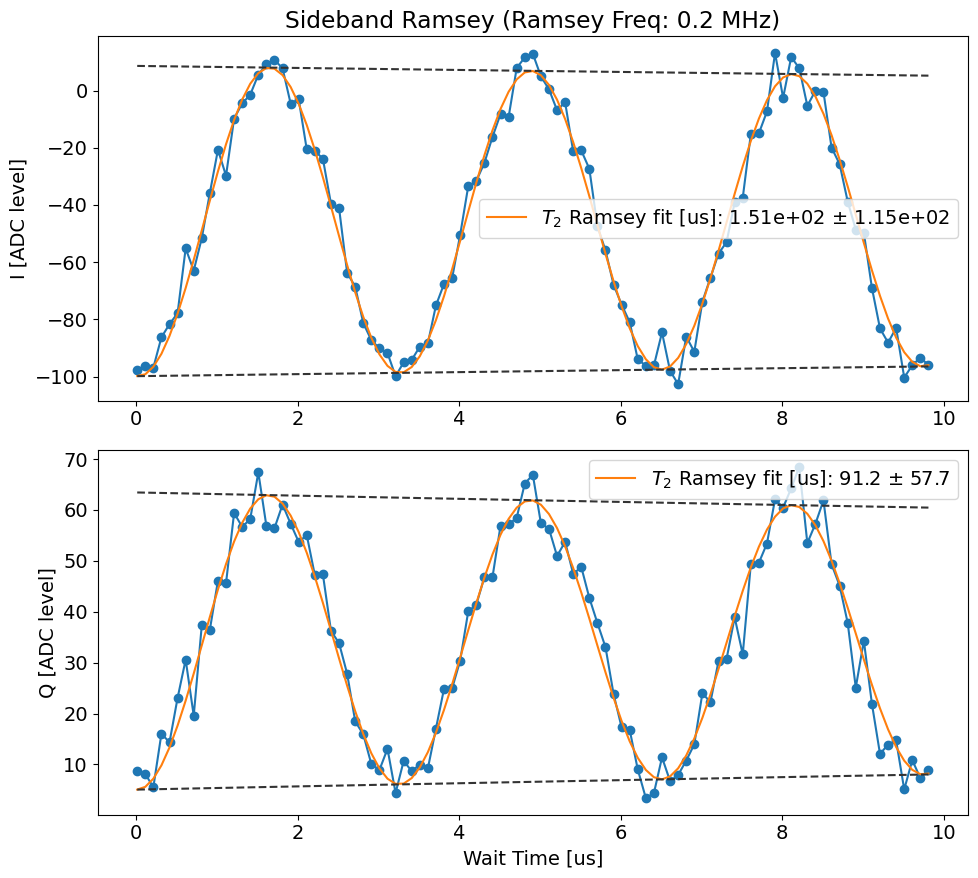

In [27]:
expt_params = dict(
    start = 0.01, # wait time tau [us]
    step = 0.1,  # [us] 1 cycle is 0.0023251488095238095 [us], 2.7901785714285716 # [us]=1200 cycles
    expts = 100,
    ramsey_freq = 0.2, # [MHz]
    detune = 0,
    ac_stark=0.5, # [MHz] not sure how to define sign yet
    # but in any case this needs to be smaller than ramsey_freq
    # because qick can't handle negative numbers
    reps = 100,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    stor_no = 1, # storage mode number, 1 to 7
    normalize = False,
    active_reset = True,
    man_reset = True, 
    storage_reset = True, 
    advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
    echoes = [False, 0], # [on/off, number of echoes]
)

sbr = SidebandRamseyExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"SidebandRamsey_M1S{expt_params['stor_no']}",
    config_file=config_path,
    expt_params = expt_params,
    progress=True)

sbr.cfg.device.readout.relax_delay = [200]  # Wait time between experiments [us]
# sbr.acquire()
sbr.go(analyze=True, display=True, progress=True, save=True)

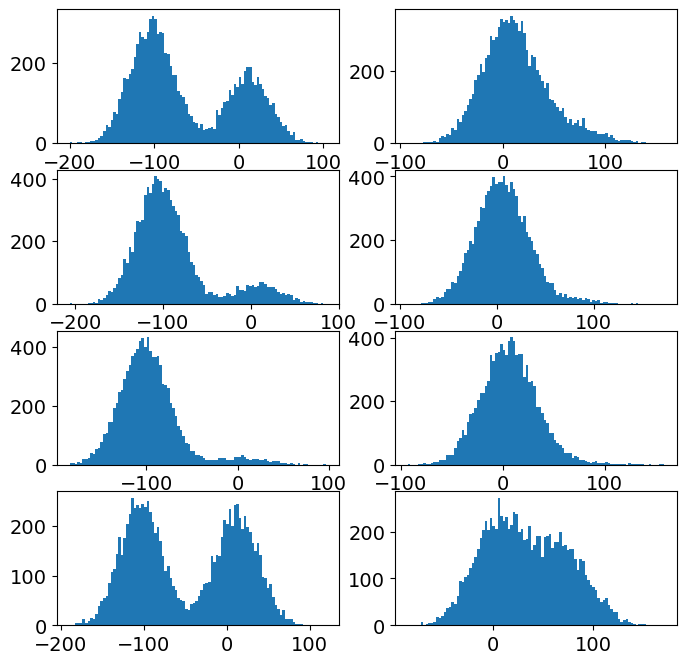

In [28]:
idata = sbr.data['idata']
idata = idata.reshape((len(idata)//4,4))

qdata = sbr.data['qdata']
qdata = qdata.reshape((len(qdata)//4,4))

fig, axs = plt.subplots(nrows=4,ncols=2, figsize=(8,8))
for kk in range(4):
    axs[kk,0].hist(idata[:,kk], bins=100)
    axs[kk,1].hist(qdata[:,kk], bins=100)
None

In [ ]:
0.327922332524605 # current reset version
0.32806373843420333 # without reset
0.3264759424279595 # reset with 100us wait
0.3274569103286323 # only 0 to N+1
0.328382941835013 # only -N to 0
0.327225195204317 # only 0
0.325693135972055 # n set to 30
0.32566986782848 # add 100 to m1d1

### 2D chevron

In [32]:
from multimode_expts.experiments.qsim.sideband_ramsey import SidebandChevronExperiment

In [33]:
expt_params = dict(
    start = 0.01, # wait time tau [us]
    step = 0.05,  # [us] 1 cycle is 0.0023251488095238095 [us], 2.7901785714285716 # [us]=1200 cycles
    expts = 100,
    ramsey_freq = 0.1, # [MHz]
    ac_stark=0.5,
    detune = 0,
    reps = 100,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    stor_no = 1, # storage mode number, 1 to 7
    normalize = False,
    active_reset = False,
    # man_reset = False, 
    # storage_reset = False, 
    advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
    echoes = [False, 0], # [on/off, number of echoes]
)

for stor_no in [5]: #range(1,8):
    expt_params['stor_no'] = stor_no
    sbr = SidebandChevronExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandChevron_M1S{stor_no}",
        config_file=config_path,
        expt_params = expt_params,
        progress=True)
    
    # sbr.acquire()
    sbr.go(analyze=False, display=False, progress=True, save=True)

  0%|          | 0/51 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [85]:
sbr.data.keys()

dict_keys(['avgi', 'avgq', 'amps', 'phases', 'idata', 'qdata', 'xpts', 'ypts'])

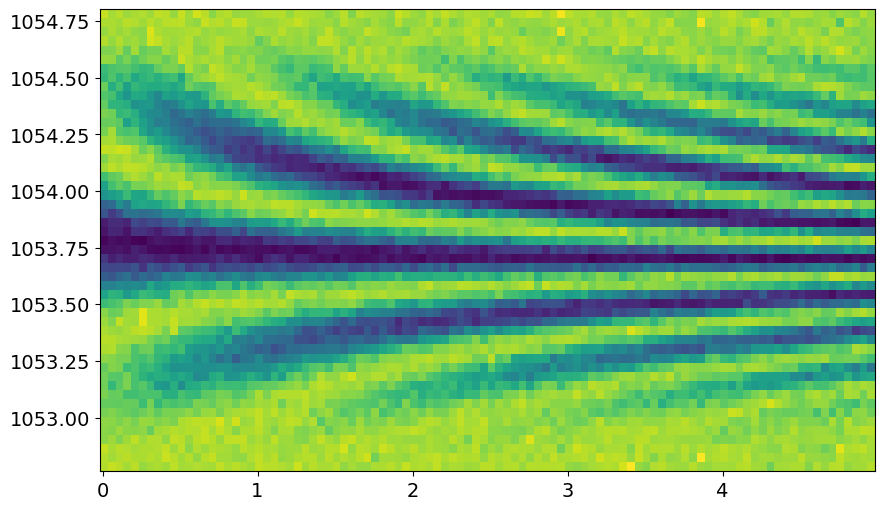

In [ ]:
plt.pcolormesh(sbr.data['xpts'], sbr.data['ypts'], sbr.data['avgi'])

## Sideband scramble

In [17]:
sideband_scramble_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=True,

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def sideband_scramble_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs

    print(expt_cfg)
    return expt_cfg


{'expts': 1, 'reps': 500, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': True, 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': True, 'man_reset': True, 'storage_reset': [1, 7], 'prepulse': True, 'postpulse': True, 'init_stor': 0, 'swap_stors': [1, 7], 'update_phases': True, 'floquet_cycles': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
       35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67,
       69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99]), 'swept_params': ['floquet_cycle'], 'use_qubit_man_reset': True, 'pre_selection_reset': False, 'relax_delay': 1500}
Job submitted: JOB-20260223-00196 (queue position: 1)

[0.1s] Job JOB-20260223-00196: pending



[2.1s] Job JOB-20260223-00196: running
[WORKER] Loading QsimBaseExperiment from experiments.qsim.qsim_base
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260223-00196_QsimBaseExperiment.h5
[WORKER]   Program: SidebandScrambleProgram from experiments.qsim.sideband_scramble
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
  0%|                                                   | 0/50 [00:00<?, ?it/s]resetting stor modes [1, 7]
4 2271.93451257758 60.58134864661368 32000
4 2271.93451257758 60.58134864661368 32000
  2%|▊                                          | 1/50 [00:00<00:47,  1.03it/s]resetting stor modes [1, 7]
4 2271.93451257758 60.58134864661368 32000
4 2271.93451257758 60.58134864661368 32000
  4%|█▋                                         | 2/50 [00:01<00:46,  1.02it/s]resetting stor modes [1, 7]
4 2271.93451257758 60.58134864661368 32000
4 2271.93451257758 60

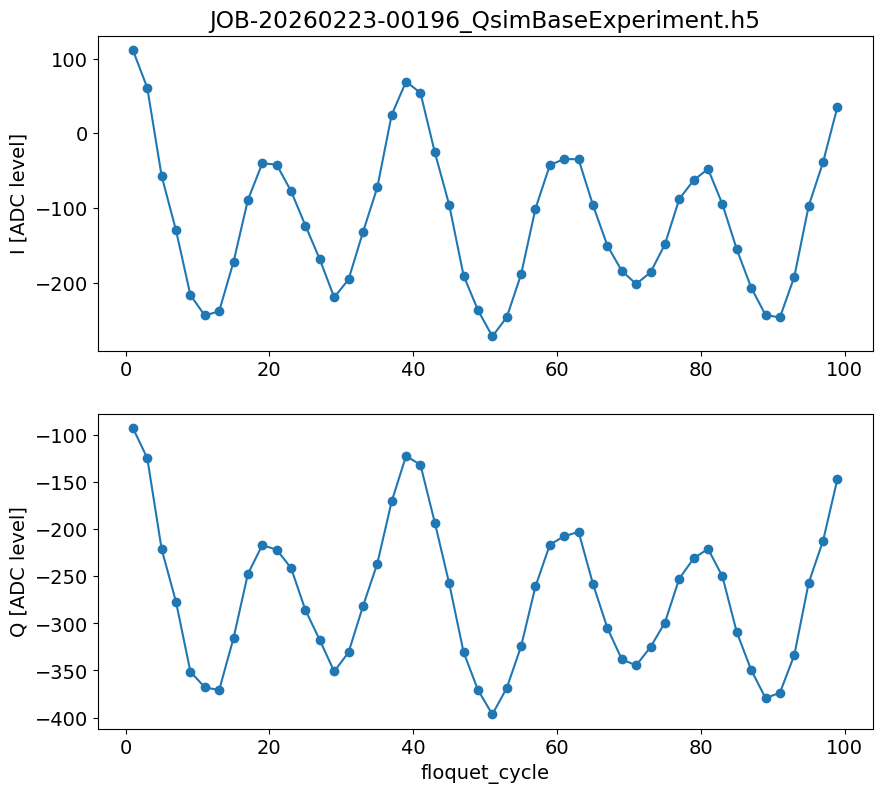

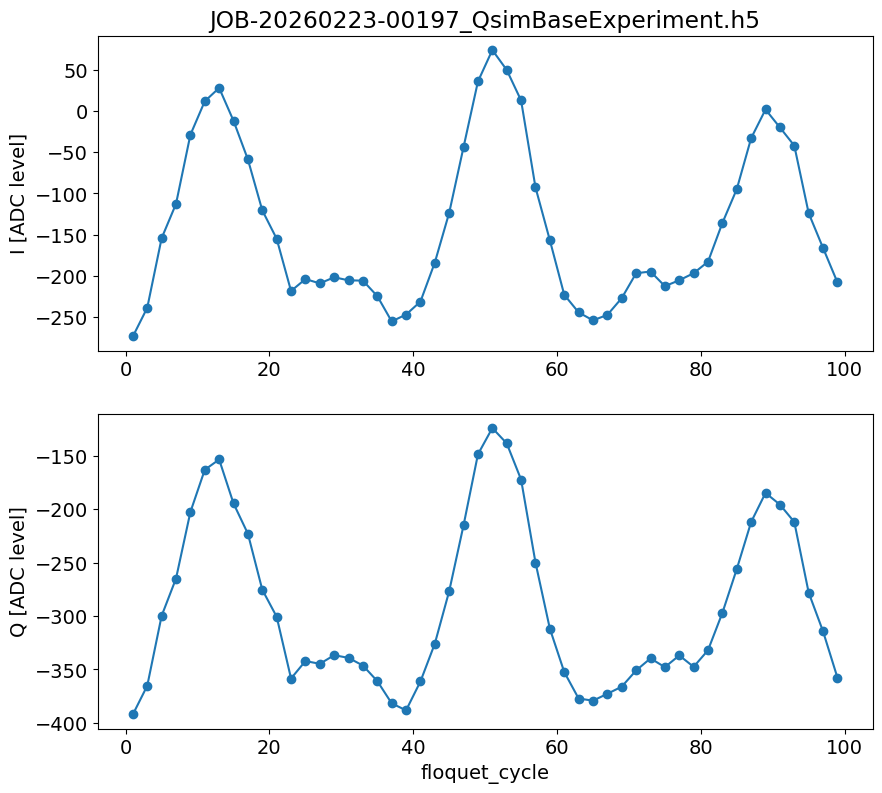

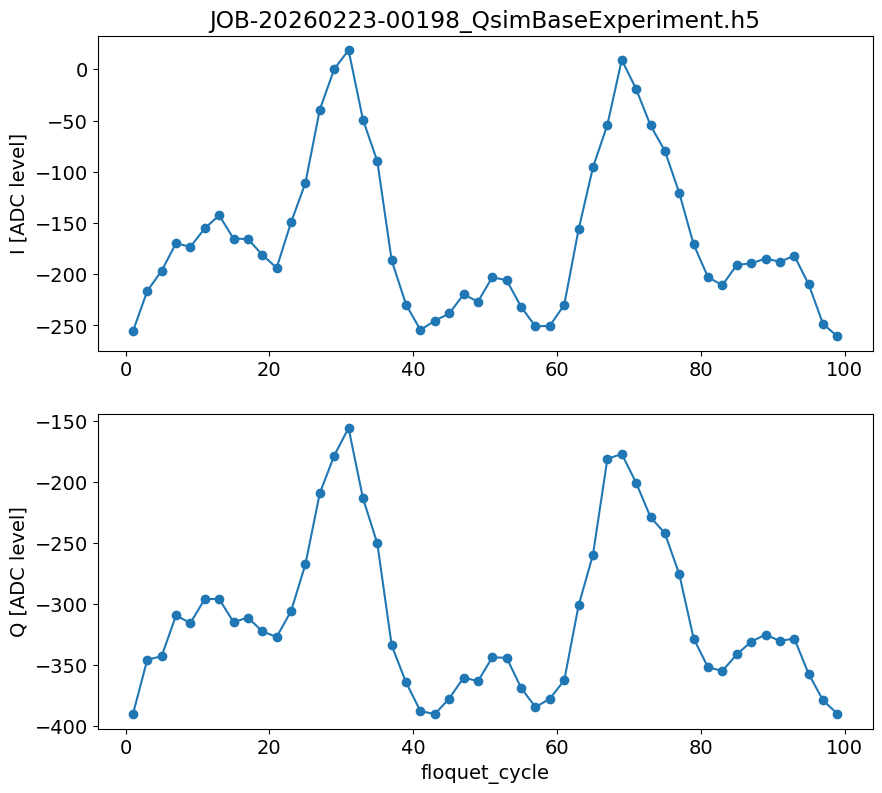

In [18]:
scramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimExperiment,
    ExptProgram=meas.SidebandScrambleProgram,
    default_expt_cfg=sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = np.arange(1, 100, step=2)

meas_stors = [0, 1, 7]
swap_stors = [1, 7]

scramble_expts = []

for meas_stor in meas_stors:
    scramble = scramble_runner.execute(
        reps=500,
        init_fock=True,
        init_stor=0,
        ro_stor=meas_stor,

        # wait_us_times=np.linspace(0, 10, 11).tolist(),
        # swept_params=['wait_us_time'],

        swap_stors=swap_stors,
        update_phases=True,
        floquet_cycles=floquet_cycles,
        swept_params=['floquet_cycle'],

        # sweep_start=0,
        # sweep_stop=5,
        # sweep_npts=3,

        # active_reset=False,
        # relax_delay=8000,

        active_reset=True,
        man_reset=True,
        storage_reset=swap_stors,
        use_qubit_man_reset=True,
        pre_selection_reset=False,
        relax_delay=1500,
    )
    scramble_expts.append(scramble)
    scramble.display()

  0%|          | 0/501 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00028_SidebandScramble_S0_to_S0.h5


  0%|          | 0/501 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00003_SidebandScramble_S0_to_S1.h5


  0%|          | 0/501 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00002_SidebandScramble_S0_to_S2.h5


  0%|          | 0/501 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00003_SidebandScramble_S0_to_S3.h5


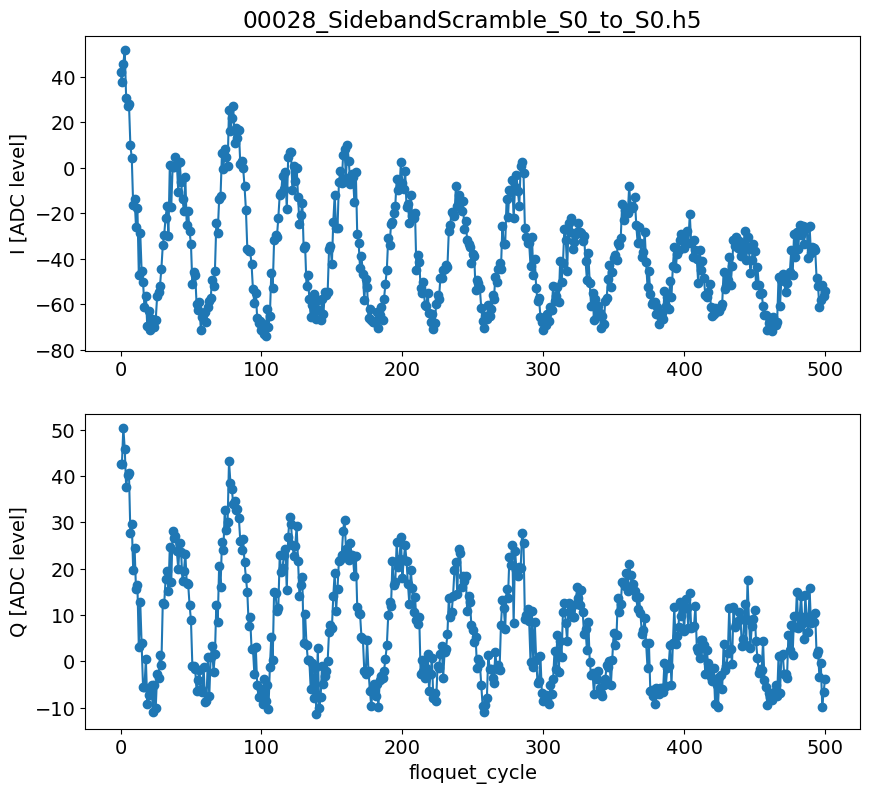

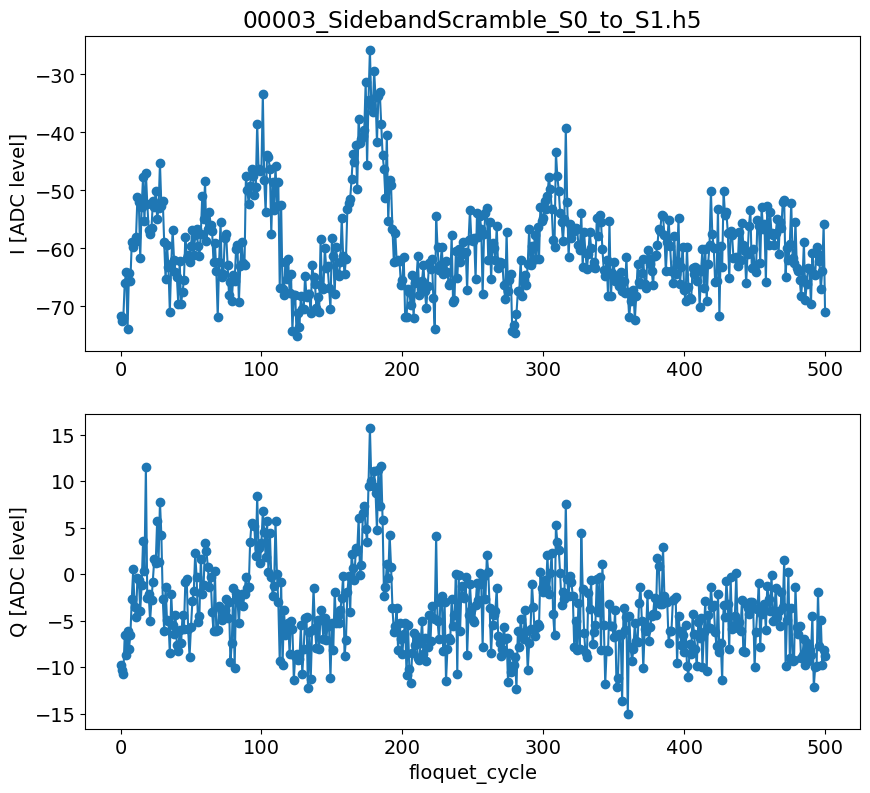

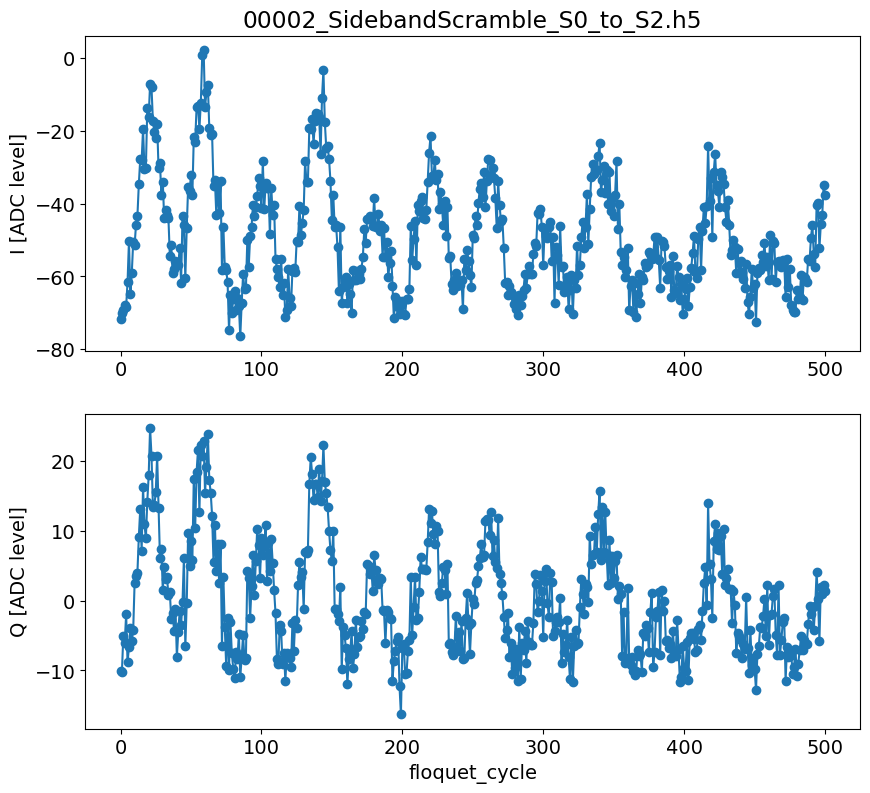

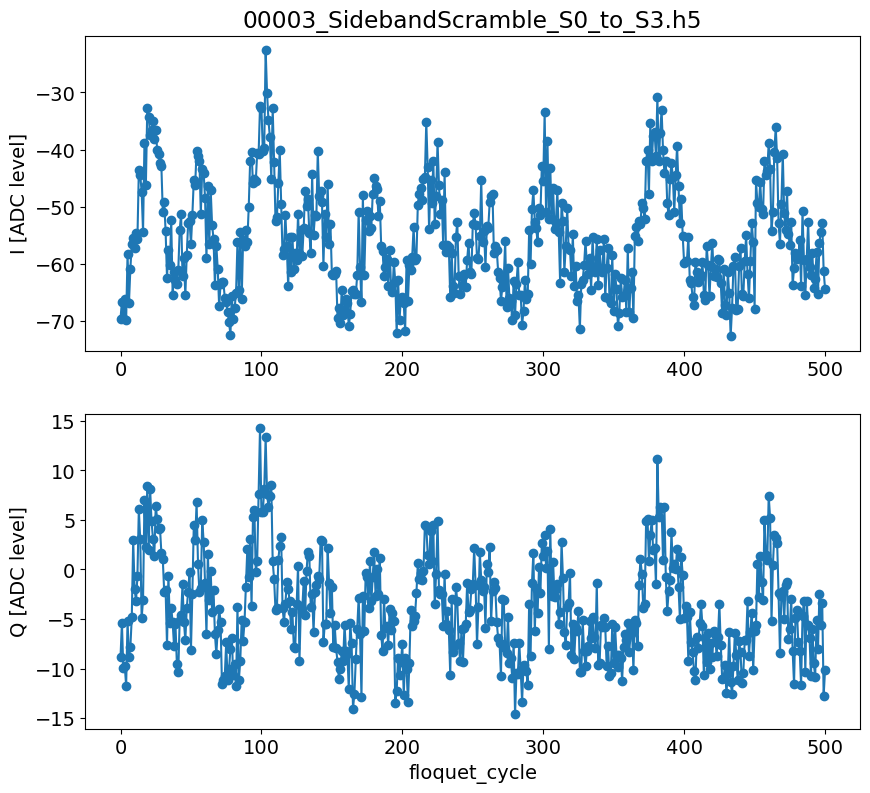

In [40]:
meas_stors = [0,1,2,3]

for update_phases in [True]: # [False, True]:
    for meas_stor in meas_stors:
        expt_params = dict(
            expts = 1,
            reps = 100,
            rounds = 1,
            qubits = [0],
            f0g1_cavity = 1,  #  name of manipulate cavity (1 or 2)
            init_stor = 0, # storage mode number to initialize to n=1 Fock state
            ro_stor = meas_stor, # storage mode number that gets read out in the end
            # if 0, this means to read out man instead
            floquet_cycles = list(range(0,501)),
            detune=0,
            normalize = False,
            active_reset = False,
            man_reset = True, 
            storage_reset = True, 
            # advance_phase=3,
            # swept_params = ['advance_phase', 'floquet_cycle'],
            swept_params = ['floquet_cycle'],
            swap_stors = [1,2,3],
            # floquet_dataset_filename = 'floquet_storage_2Derramp.csv',
            update_phases = update_phases, 
            echoes = [False, 0], # [on/off, number of echoes]
            prepulse=True,
            postpulse=True,
        )
    
        sbs = meas.QsimExperiment(
            soccfg=soc,
            path=expt_path,
            prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
            config_file=config_path,
            expt_params = expt_params,
            program = meas.SidebandScrambleProgram,
            progress=True)
    
        sbs.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
        sbs.go(analyze=False, display=True, progress=True, save=True)

### readout cavity freq sweep at the end

In [43]:
expt_params = dict(
    expts = 1,
    reps = 100,
    rounds = 1000,
    qubits = [0],
    f0g1_cavity = 1,  #  name of manipulate cavity (1 or 2)
    init_stor = 0, # storage mode number to initialize to n=1 Fock state
    ro_stor = 0, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycle = 300,
    detune=0,
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    swept_params = ['readout_freq'],
    readout_freqs = np.linspace(748,751,101).tolist(),
    swap_stors = [1,3],
    # floquet_dataset_filename = 'floquet_storage_2Derramp.csv',
    update_phases = True, 
    echoes = [False, 0], # [on/off, number of echoes]
    prepulse=True,
    postpulse=False,
)

sbs = meas.QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = meas.ReadoutFreqSweepProgram,
    progress=True)

sbs.cfg.device.readout.relax_delay = [500]  # Wait time between experiments [us]
sbs.go(analyze=False, display=True, progress=True, save=True)

  0%|          | 0/101 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [46]:
print(sbs.prog.asm())


// Program

        regwi 3, $12, 466865980;                //freq = 466865980
        regwi 3, $13, 307736202;                //phase = 307736202
        regwi 3, $15, 800;                      //gain = 800
        regwi 3, $16, 590469;                   //phrst| stdysel | mode | | outsel = 0b01001 | length = 645 
        synci 86;
        synci 200;
        regwi 0, $15, 0;
        regwi 0, $14, 99;
LOOP_J: regwi 1, $22, 599114555;                //freq = 2396458223
        bitwi 1, $22, $22 << 2;
        mathi 1, $22, $22 + 3;
        regwi 1, $23, 0;                        //phase = 0
        regwi 1, $25, 0;                        //gain = 0
        regwi 1, $26, 1638410;                  //phrst| stdysel | mode | | outsel = 0b11001 | length = 10 
        regwi 1, $27, 0;                        //t = 0
        set 2, 1, $22, $23, $0, $25, $26, $27;  //ch = 2, pulse @t = $27
        regwi 2, $12, 840205128;                //freq = 3360820513
        bitwi 2, $12, $12 << 2;
       

In [47]:
sbs.prog.cycles2us(10)

0.023251488095238096

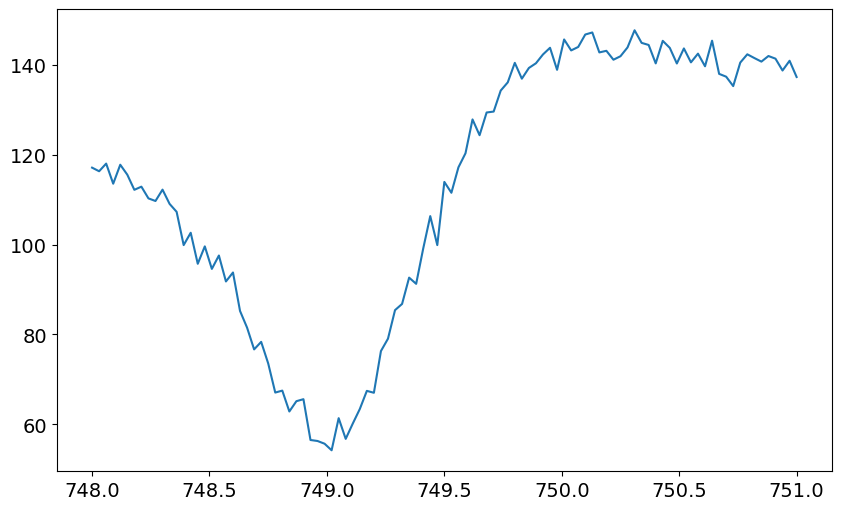

In [28]:
plt.plot(sbs.data['xpts'], sbs.data['amps'])

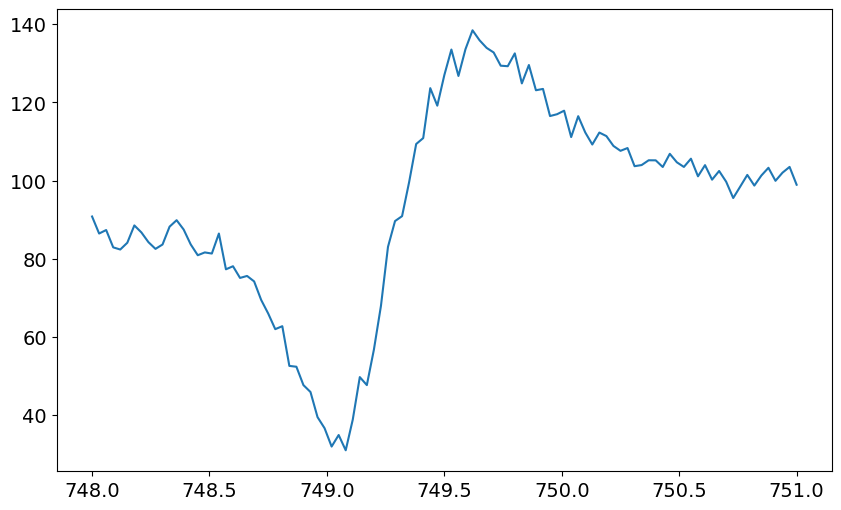

In [ ]:
plt.plot(sbs.data['xpts'], sbs.data['amps'])

  0%|          | 0/101 [00:00<?, ?it/s]

[749.5, 5000, 1000, 0, 186.6986454765322, 185.29089093262422, -17.801072631674074]
[ 749.5897569  -463.55334141  749.08881999    1.72509378  115.29696424
  355.45349252   13.87285143]

Freq with minimum transmission: 750.13
Freq with maximum transmission: 749.47
From fit:
	f0: 749.5897568952053
	Qi: -463.553341408016
	Qe: 749.0888199949264
	Q0: -1216.1102614586064
	kappa [MHz]: -0.6163830539478756
	phi [radians]: 1.7250937755892433
Saving D:\experiments\251031_qsim\data\00008_ResonatorSpectroscopyExperiment.h5


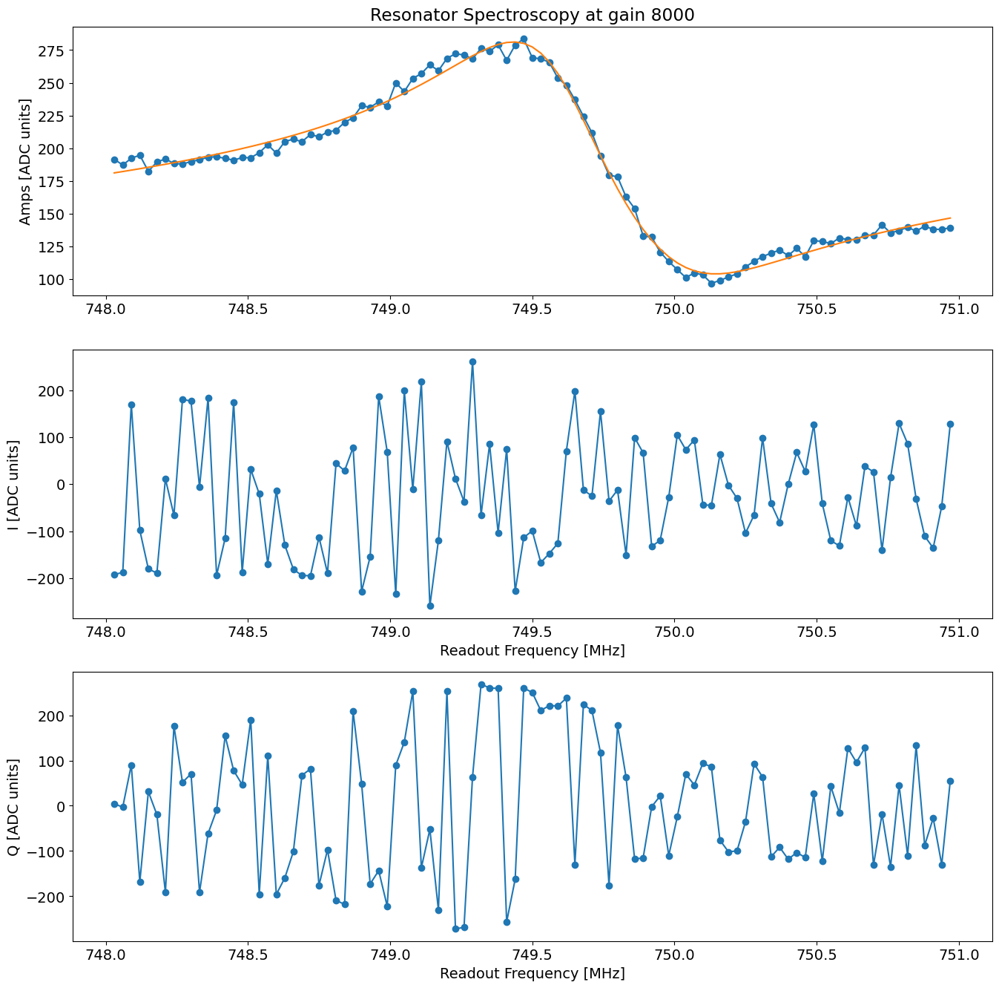

In [41]:
rspec = meas.ResonatorSpectroscopyExperiment(
        soccfg=soc, path=expt_path, prefix='ResonatorSpectroscopyExperiment', config_file=config_path
    )
rspec.cfg = AttrDict(deepcopy(config_thisrun))

rspec.cfg.expt = dict(
    start = 748, # resonator frequency to be mixed up [MHz]
    step = 0.03,
    expts = 101, # Number experiments stepping from start
    reps = 100, # Number averages per point
    pulse_e = True, # add ge pi pulse prior to measurement
    pulse_f = False, # add ef pi pulse prior to measurement
    pulse_cavity = False,  # prepulse on cavity prior to measurement (False also disables next line)
    cavity_pulse = [4984.373226159381, 800, 2, 0], # [frequency, gain, length, phase]  const pulse
    qubit = 0,
)

rspec.cfg.device.readout.gain = [8000]
rspec.cfg.device.readout.relax_delay = [800] # Wait time between experiments [us]
rspec.go(analyze=True, display=True, progress=True, save=True)

### Phase calibration using quantum walk

In [92]:
from multimode_expts.experiments.qsim.sideband_scramble import FloquetCalibrationProgram

In [ ]:
storA = 2
storB = 3

expt_params = dict(
    expts = 1,
    reps = 50,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    storA = storA,
    storB = storB,
    init_stor = storA, # storage mode number to initialize to n=1 Fock state
    ro_stor = storB, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,201,2)), 
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    storA_advance_phases = np.linspace(-20,20,81).tolist(), # advance phase of each successive pulse for the init mode[degrees]
    storB_advance_phase = ds_thisrun.get_phase_from(f'M1-S{storB}', f'M1-S{storA}')*2,
    # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
    swept_params = ['storA_advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    echoes = [False, 0], # [on/off, number of echoes]
    prepulse=True,
    postpulse=True
)


fce = QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = FloquetCalibrationProgram,
    progress=True)

fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
fce.go(analyze=False, display=True, progress=True, save=True)

  0%|          | 0/81 [00:00<?, ?it/s]

In [ ]:
for storA, storB in [(2,6),(2,7),(3,2),(3,6),(3,7),(6,2),(6,3),(6,7),(7,2),(7,3),(7,6)]:
    expt_params = dict(
        expts = 1,
        reps = 50,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        storA = storA,
        storB = storB,
        init_stor = storA, # storage mode number to initialize to n=1 Fock state
        ro_stor = storB, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        floquet_cycles = list(range(1,201,5)), 
        normalize = False,
        active_reset = False,
        man_reset = True, 
        storage_reset = True, 
        storA_advance_phases = np.linspace(-20,20,41).tolist(), # advance phase of each successive pulse for the init mode[degrees]
        storB_advance_phase = ds_thisrun.get_phase_from(f'M1-S{storB}', f'M1-S{storA}')*2,
        # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
        swept_params = ['storA_advance_phase', 'floquet_cycle'],
        # swept_params = ['floquet_cycle'],
        echoes = [False, 0], # [on/off, number of echoes]
        prepulse=True,
        postpulse=True
    )
    
    
    fce = QsimExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
        config_file=config_path,
        expt_params = expt_params,
        program = FloquetCalibrationProgram,
        progress=True)
    
    fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
    fce.go(analyze=False, display=True, progress=True, save=True)

(<Figure size 1000x900 with 4 Axes>,
 array([<Axes: title={'center': '00002_FloquetCalibration_S2_to_S3.h5'}, xlabel='floquet_cycle', ylabel='storA_advance_phase'>,
        <Axes: xlabel='floquet_cycle', ylabel='storA_advance_phase'>],
       dtype=object))

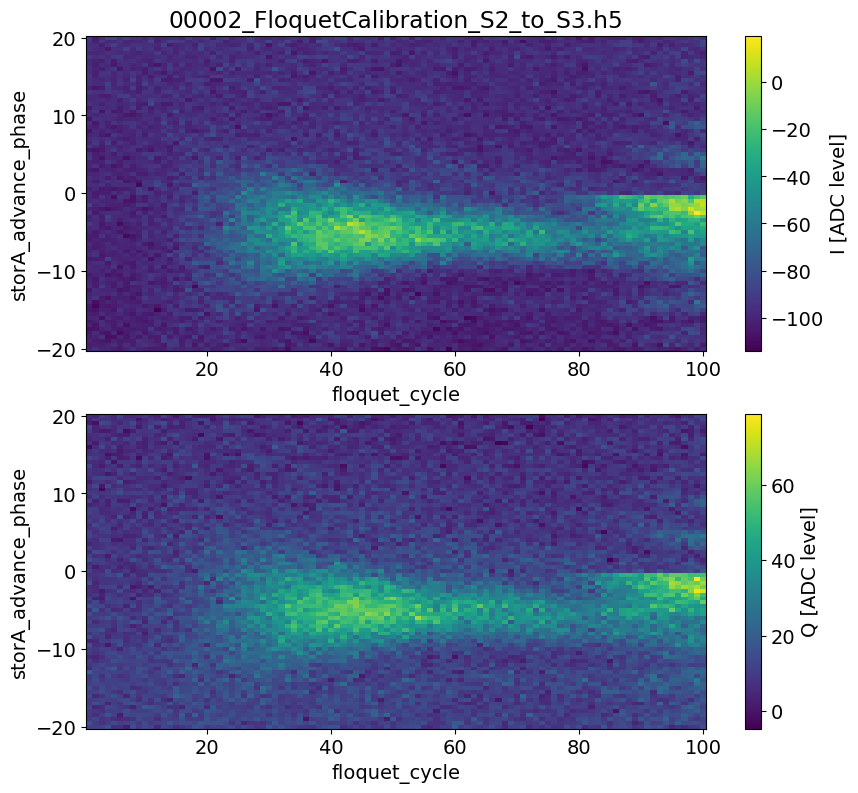

In [105]:
fce.display()

  0%|          | 0/101 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00001_FloquetCalibration_S3_to_S1.h5


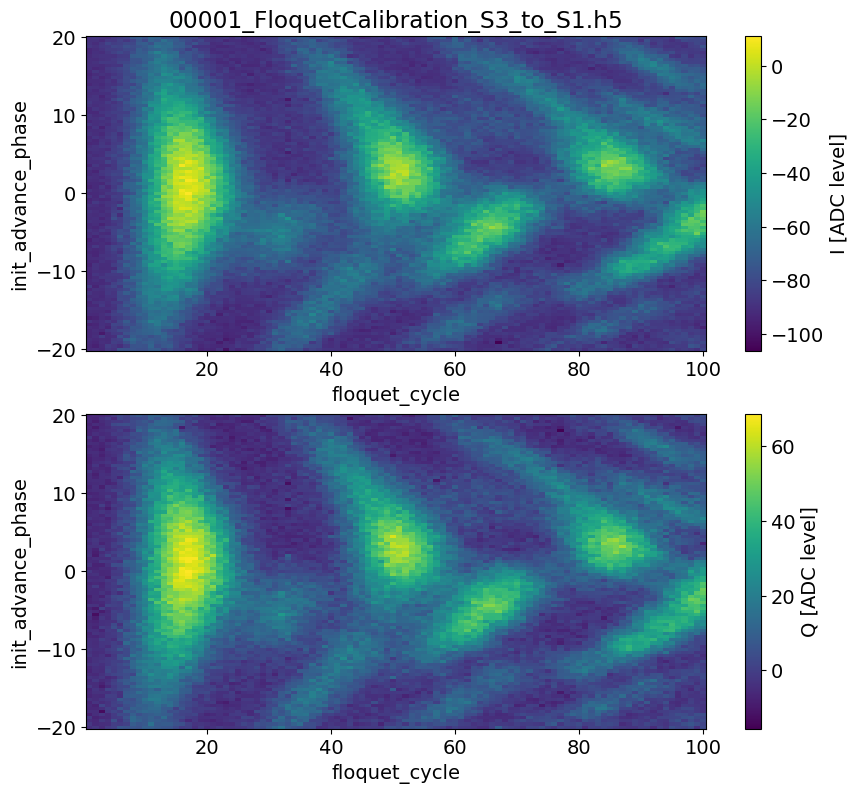

In [51]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 3, # storage mode number to initialize to n=1 Fock state
    ro_stor = 1, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    init_advance_phases = np.linspace(-20,20,101).tolist(), # advance phase of each successive pulse for the init mode[degrees]
    ro_advance_phase = -4,
    # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
    swept_params = ['init_advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    echoes = [False, 0], # [on/off, number of echoes]
)

fce = QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = FloquetCalibrationProgram,
    progress=True)

fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
fce.go(analyze=False, display=True, progress=True, save=True)

  0%|          | 0/101 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00001_FloquetCalibration_S2_to_S3.h5


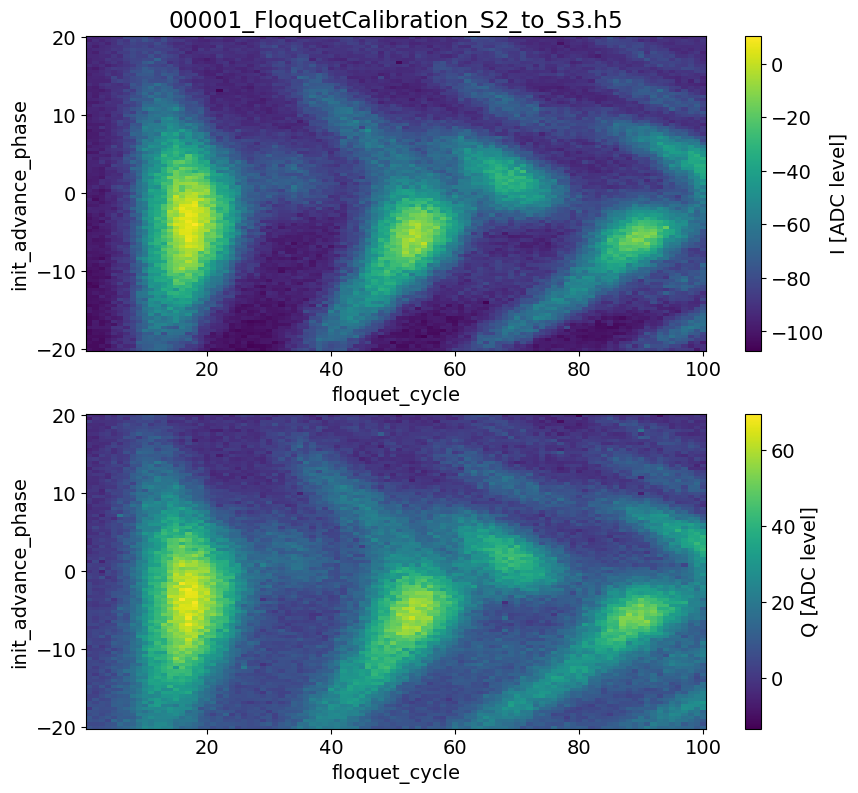

In [60]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 2, # storage mode number to initialize to n=1 Fock state
    ro_stor = 3, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    init_advance_phases = np.linspace(-20,20,101).tolist(), # advance phase of each successive pulse for the init mode[degrees]
    ro_advance_phase = 6,
    # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
    swept_params = ['init_advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    echoes = [False, 0], # [on/off, number of echoes]
)

fce = QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = FloquetCalibrationProgram,
    progress=True)

fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
fce.go(analyze=False, display=True, progress=True, save=True)

  0%|          | 0/101 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00001_FloquetCalibration_S3_to_S2.h5


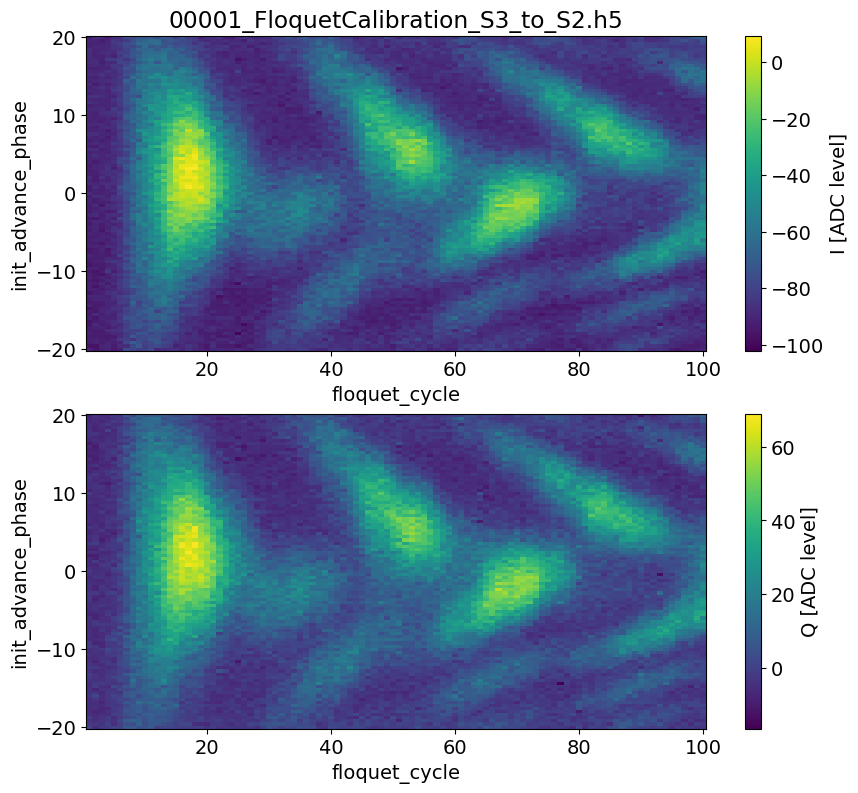

In [61]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 3, # storage mode number to initialize to n=1 Fock state
    ro_stor = 2, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    init_advance_phases = np.linspace(-20,20,101).tolist(), # advance phase of each successive pulse for the init mode[degrees]
    ro_advance_phase = -8,
    # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
    swept_params = ['init_advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    echoes = [False, 0], # [on/off, number of echoes]
)

fce = QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = FloquetCalibrationProgram,
    progress=True)

fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
fce.go(analyze=False, display=True, progress=True, save=True)

  0%|          | 0/60 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00012_SidebandScramble_S1_to_S2.h5


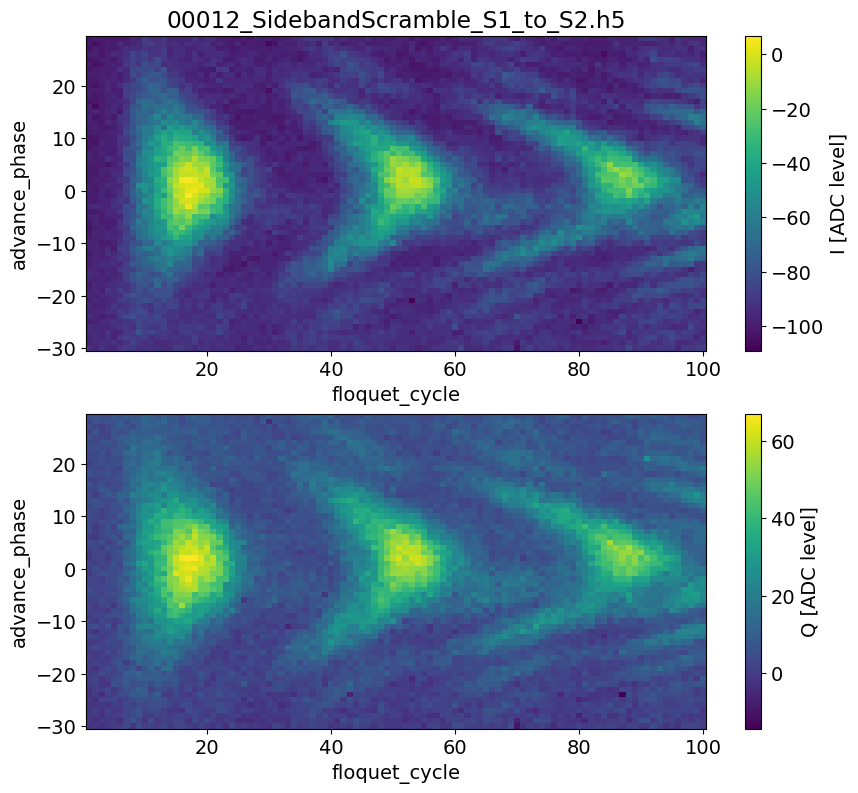

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 1, # storage mode number to initialize to n=1 Fock state
    ro_stor = 3, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    init_advance_phases = list(range(-10,10,0.5)), # advance phase of each successive pulse [degrees]
    ro_advance_phases = list(range(-1k,30,1)), # advance phase of each successive pulse [degrees]
    # advance_phase=0,
    swept_params = ['advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    # swap_stors = [1, 2],
    # update_phases = True, 
    echoes = [False, 0], # [on/off, number of echoes]
)

sbs = QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = SidebandScrambleProgram,
    progress=True)

sbs.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
sbs.go(analyze=False, display=True, progress=True, save=True)

  0%|          | 0/60 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00013_SidebandScramble_S1_to_S2.h5


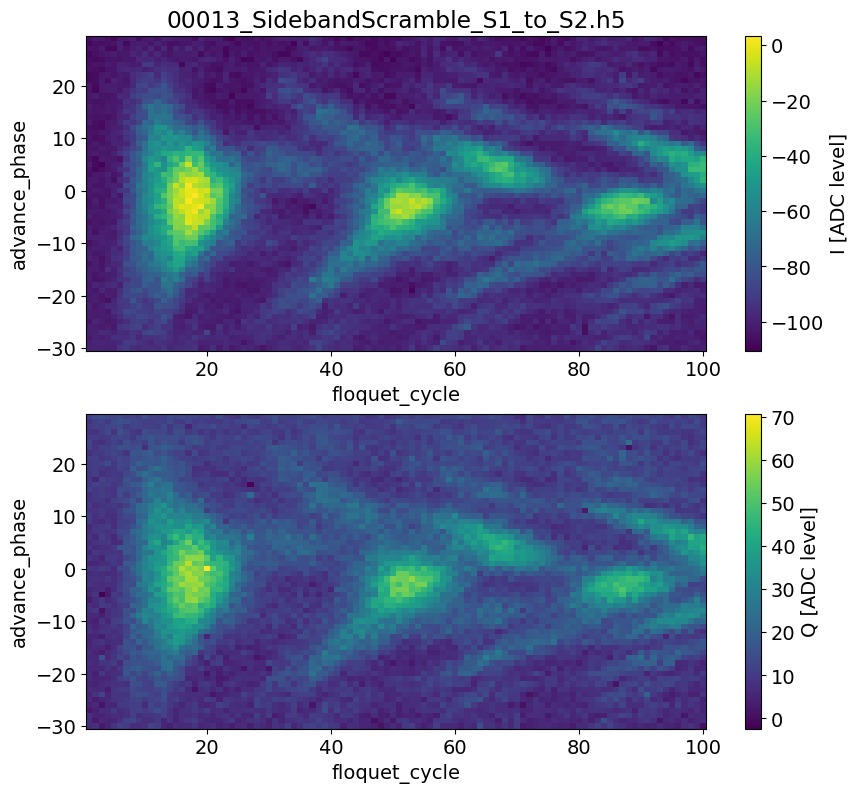

In [46]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 1, # storage mode number to initialize to n=1 Fock state
    ro_stor = 2, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    # gain_div = 3,
    # length_div = 2,
    # detune=0,
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    advance_phases = list(range(-30,30,1)), # advance phase of each successive pulse [degrees]
    # advance_phase=0,
    swept_params = ['advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    # swap_stors = [1, 2],
    # update_phases = True, 
    echoes = [False, 0], # [on/off, number of echoes]
)

sbs = QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = SidebandScrambleProgram,
    progress=True)

sbs.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
sbs.go(analyze=False, display=True, progress=True, save=True)

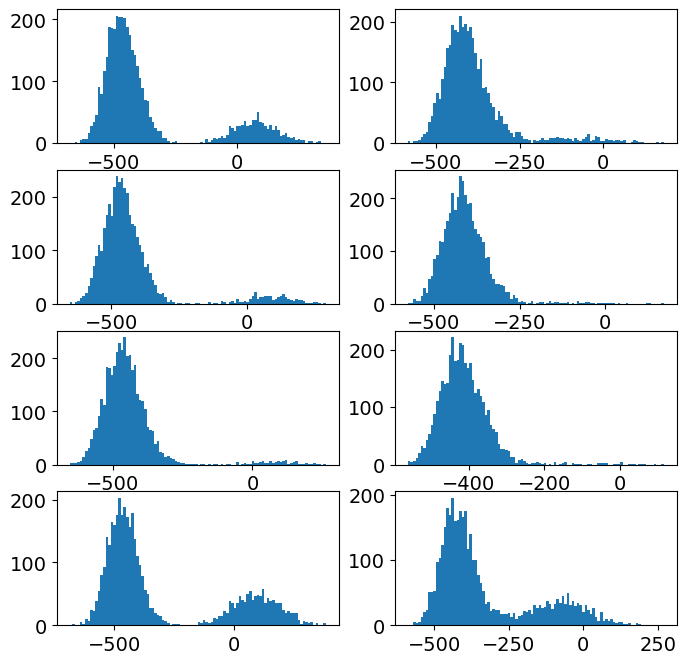

In [98]:
idata = np.array(sbs.data['idata']).ravel()
idata = idata.reshape((len(idata)//4,4))

qdata = np.array(sbs.data['qdata']).ravel()
qdata = qdata.reshape((len(qdata)//4,4))

fig, axs = plt.subplots(nrows=4,ncols=2, figsize=(8,8))
for kk in range(4):
    axs[kk,0].hist(idata[:,kk], bins=100)
    axs[kk,1].hist(qdata[:,kk], bins=100)
None

In [263]:
for init_stor in range(3,8):
    # for ro_stor in range(8):
    ro_stor = 0
    for detune in np.linspace(-0.2,0.2,21):
        expt_params = dict(
            expts = 1,
            reps = 1000,
            rounds = 1,
            qubits = [0],
            f0g1_cavity = 1,  #  1/2 name of manipulate cavity
            init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
            ro_stor = ro_stor, # storage mode number that gets read out in the end
            # if 0, this means to read out man instead
            floquet_cycles = list(range(1,101)),
            detune=detune,
            normalize = False,
            active_reset = True,
            man_reset = True, 
            storage_reset = True, 
            advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
            echoes = [False, 0], # [on/off, number of echoes]
        )
        
        sbs = SidebandScrambleExperiment(
            soccfg=soc,
            path=expt_path,
            prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
            config_file=config_path,
            expt_params = expt_params,
            progress=True)
        
        sbs.cfg.device.readout.relax_delay = [200]  # Wait time between experiments [us]
        sbs.go(analyze=False, display=False, progress=False, save=True)

Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00000_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00001_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00002_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00003_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00004_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00005_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00006_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00007_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00008_SidebandScramble_S3_to_S0.h5
Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00009_SidebandS

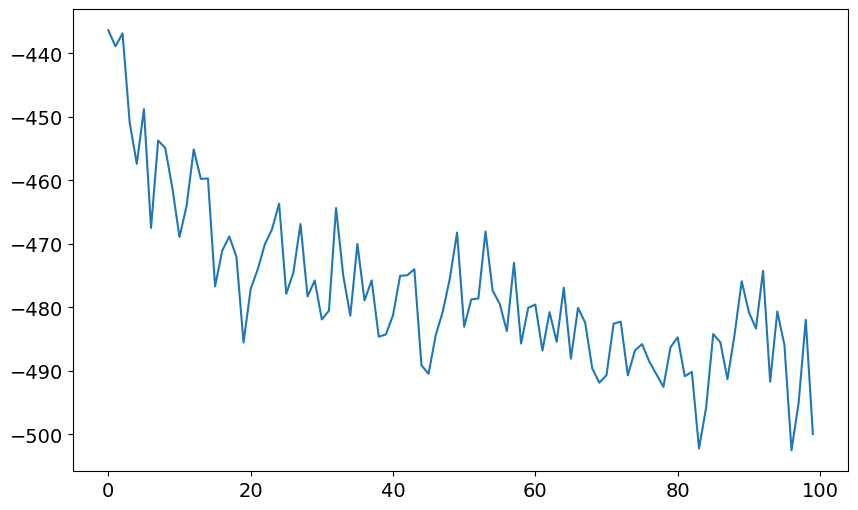

In [259]:
plt.plot(ss[9].data['avgi'])

## Amplitude Rabi

In [11]:
from multimode_expts.experiments.qsim.sideband_amp_rabi import SidebandAmpRabiExperiment

importing from path  C:\_Lib\python\multimode_expts\experiments\fitting.py
imported experiments.fitting
importing from path  C:\_Lib\python\multimode_expts\experiments\qsim
imported experiments.qsim.floquet_general
imported experiments.qsim.qsim_base
imported experiments.qsim.qsim_experiments
imported experiments.qsim.sideband_amp_rabi
imported experiments.qsim.sideband_ramsey
imported experiments.qsim.sideband_ramsey_scramble
imported experiments.qsim.sideband_scramble
imported experiments.qsim.utils
importing from path  C:\_Lib\python\multimode_expts\experiments\qubit_cavity
imported experiments.qubit_cavity.amplitude_rabi_f0g1
imported experiments.qubit_cavity.displacement_enhanced_sideband
imported experiments.qubit_cavity.displace_amplitude_calibration
imported experiments.qubit_cavity.displace_pulse_probe
imported experiments.qubit_cavity.ecd
imported experiments.qubit_cavity.ecd_backup
imported experiments.qubit_cavity.ecd_read_spec
imported experiments.qubit_cavity.non_demoluti

In [47]:
for init_stor in range(1,8):
    ro_stor = 0
    expt_params = dict(
        expts = 1,
        reps = 500,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
        ro_stor = ro_stor, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        detunes=np.linspace(-2,2,101).tolist(),
        gains=list(range(0,20000,100)),
        length=3, # us rabi pulse legnth
        normalize = False,
        active_reset = True,
        man_reset = True, 
        storage_reset = True, 
        advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
        echoes = [False, 0], # [on/off, number of echoes]
    )
    
    sare = SidebandAmpRabiExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandAmpRabi_S{expt_params['init_stor']}",
        config_file=config_path,
        expt_params = expt_params,
        progress=True)
    
    sare.cfg.device.readout.relax_delay = [200]  # Wait time between experiments [us]
    sare.go(analyze=False, display=False, progress=True, save=True)

  0%|          | 0/101 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00000_SidebandAmpRabi_S1.h5


  0%|          | 0/101 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00000_SidebandAmpRabi_S2.h5


  0%|          | 0/101 [00:00<?, ?it/s]

...

Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00000_SidebandAmpRabi_S5.h5


  0%|          | 0/101 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00000_SidebandAmpRabi_S6.h5


  0%|          | 0/101 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250506_qsim\data\00000_SidebandAmpRabi_S7.h5


## Find phase offset for ramsey

In [14]:
from multimode_expts.experiments.qsim.sideband_stark import SidebandStarkExperiment, SidebandStarkProgram

In [15]:
# for init_stor in range(1, 8):
for init_stor in range(1, 3):
    ro_stor = 0
    expt_params = dict(
        expts = 1,
        reps = 100,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
        ro_stor = ro_stor, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        # detunes=np.linspace(-0.1,0.1,101).tolist(),
        detune = 0,
        advance_phases=np.linspace(-90,90,31).tolist(),
        # wait=10, # wait time between two hpi pulses in us
        waits = np.linspace(0,30,31).tolist(),
        swept_params = ['advance_phase', 'wait'],
        # usage: if you want to sweep cfg.expt.paramName, 
        # include paramName here in this list 
        # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
        # (You want a list instead of numpy array for better yaml export.)
        # Currently handles 1D and 2D sweeps and plots only.
        # For 2D, order is [outer, inner].
        normalize = False,
        active_reset = False,
        man_reset = True, 
        storage_reset = True, 
        # advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
        echoes = [False, 0], # [on/off, number of echoes]
    )
    
    sta = SidebandStarkExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandStark_S{expt_params['init_stor']}",
        config_file=config_path,
        expt_params = expt_params,
        program=SidebandStarkProgram,
        progress=True)
    
    sta.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
    sta.go(analyze=False, display=False, progress=True, save=True)

  0%|          | 0/31 [00:00<?, ?it/s]

pulse param ['ge', 'hpi', 0]
channel name qubit
pulse param ['ge', 'parity_M1', 0]
channel name qubit
pulse param ['ge', 'hpi', 180]
channel name qubit
pulse param ['ge', 'pi', 0]
channel name qubit
pulse param ['ef', 'pi', 0]
channel name qubit
pulse param ['M1', 'pi', 0]
channel name man
pulse param ['M1-S1', 'pi', 0]
channel name storage
pulse_data [[3571.6994214615424 3428.4457610447353 2011.6693654525284
  348.702401768369]
 [3429 2770 8000 3000]
 [0.0 0.0 0.5408883810926033 0.9174265564762912]
 [0 0 0 0]
 [2 2 0 1]
 ['gauss' 'gauss' 'flat_top' 'flat_top']
 [0.035 0.035 0.005 0.005]]
pulse param ['M1', 'pi', 0]
channel name man
pulse_data [[2011.6693654525284]
 [8000]
 [0.5408883810926033]
 [0]
 [0]
 ['flat_top']
 [0.005]]
pulse param ['ge', 'hpi', 0]
channel name qubit
pulse param ['ge', 'parity_M1', 0]
channel name qubit
pulse param ['ge', 'hpi', 180]
channel name qubit
pulse param ['ge', 'pi', 0]
channel name qubit
pulse param ['ef', 'pi', 0]
channel name qubit
pulse param ['M1

  0%|          | 0/31 [00:00<?, ?it/s]

pulse param ['ge', 'hpi', 0]
channel name qubit
pulse param ['ge', 'parity_M1', 0]
channel name qubit
pulse param ['ge', 'hpi', 180]
channel name qubit
pulse param ['ge', 'pi', 0]
channel name qubit
pulse param ['ef', 'pi', 0]
channel name qubit
pulse param ['M1', 'pi', 0]
channel name man
pulse param ['M1-S2', 'pi', 0]
channel name storage
pulse_data [[3571.6994214615424 3428.4457610447353 2011.6693654525284
  520.1370383281906]
 [3429 2770 8000 5000]
 [0.0 0.0 0.5408883810926033 1.084581933496189]
 [0 0 0 0]
 [2 2 0 1]
 ['gauss' 'gauss' 'flat_top' 'flat_top']
 [0.035 0.035 0.005 0.005]]
pulse param ['M1', 'pi', 0]
channel name man
pulse_data [[2011.6693654525284]
 [8000]
 [0.5408883810926033]
 [0]
 [0]
 ['flat_top']
 [0.005]]
pulse param ['ge', 'hpi', 0]
channel name qubit
pulse param ['ge', 'parity_M1', 0]
channel name qubit
pulse param ['ge', 'hpi', 180]
channel name qubit
pulse param ['ge', 'pi', 0]
channel name qubit
pulse param ['ef', 'pi', 0]
channel name qubit
pulse param ['M1

c:\Users\26049\.conda\envs\slab\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


AC Stark freq: 0.199627MHz


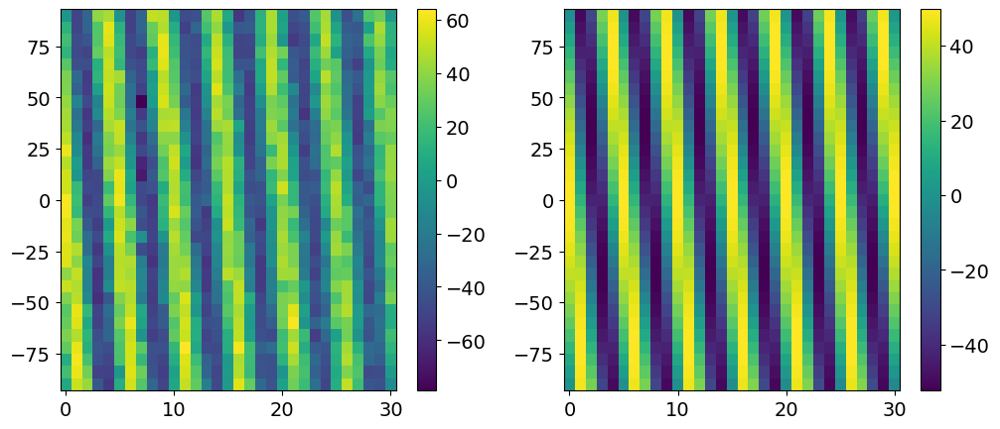

In [17]:
sta.analyze()

In [19]:
for init_stor in [1]: #range(1,8):
    ro_stor = 0
    expt_params = dict(
        expts = 1,
        reps = 500,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
        ro_stor = ro_stor, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        # detunes=np.linspace(-0.1,0.1,101).tolist(),
        detune = 0,
        phases=np.linspace(-90,90,91).tolist(),
        # wait=10, # wait time between two hpi pulses in us
        waits = np.linspace(0,2,51).tolist(),
        swept_params = ['phase', 'wait'],
        # usage: if you want to sweep cfg.expt.paramName, 
        # include paramName here in this list 
        # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
        # (You want a list instead of numpy array for better yaml export.)
        # Currently handles 1D and 2D sweeps and plots only.
        # For 2D, order is [outer, inner].
        normalize = False,
        active_reset = True,
        man_reset = True, 
        storage_reset = True, 
        advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
        echoes = [False, 0], # [on/off, number of echoes]
    )
    
    sta = SidebandStarkExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandStark_S{expt_params['init_stor']}",
        config_file=config_path,
        expt_params = expt_params,
        progress=True)
    
    sta.cfg.device.readout.relax_delay = [200]  # Wait time between experiments [us]
    sta.go(analyze=False, display=False, progress=True, save=True)

  0%|          | 0/91 [00:00<?, ?it/s]

KeyboardInterrupt: 

### new base class general 2D

In [20]:
from multimode_expts.experiments.qsim.sideband_stark import SidebandStarkProgram
from multimode_expts.experiments.qsim.qsim_base import QsimExperiment

  0%|          | 0/101 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250708_qsim\data\00002_SidebandStark_S2.h5


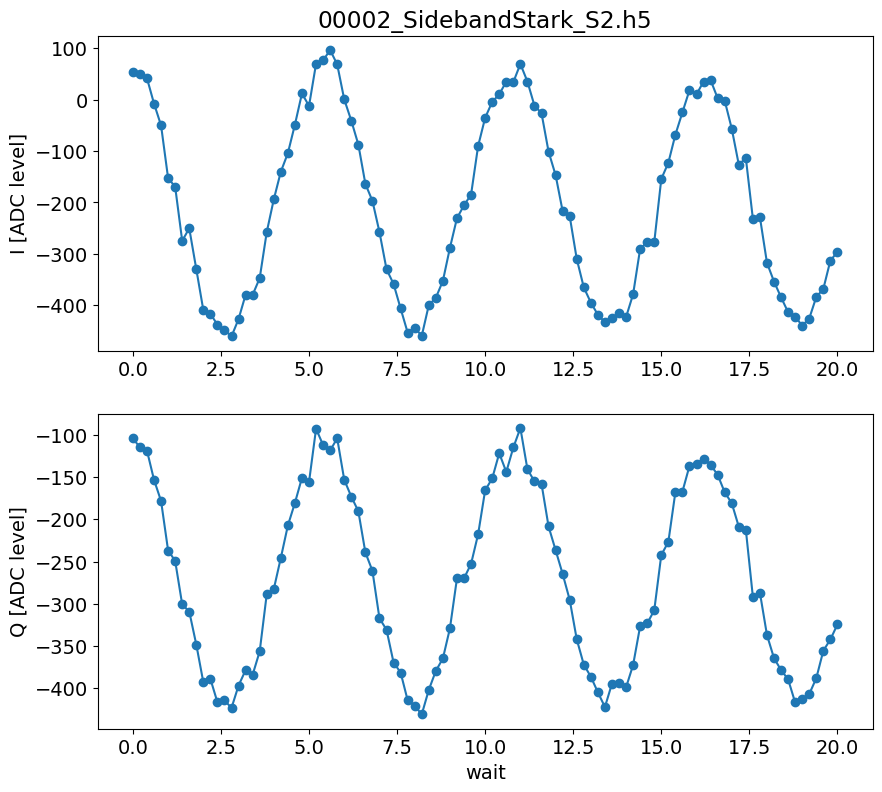

In [106]:
for init_stor in [2]: #range(1,8):
    ro_stor = 0
    expt_params = dict(
        expts = 1,
        reps = 100,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
        ro_stor = ro_stor, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        detune = 0,
        # detunes=np.linspace(-0.1,0.1,101).tolist(),
        advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
        # advance_phases=np.linspace(-90,90,91).tolist(),
        # wait=10, # wait time between two hpi pulses in us
        waits = np.linspace(0,20,101).tolist(),
        swept_params = ['wait'],
        # usage: if you want to sweep cfg.expt.paramName, 
        # include paramName here in this list 
        # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
        # (You want a list instead of numpy array for better yaml export.)
        # Currently handles 1D and 2D sweeps and plots only.
        # For 2D, order is [outer, inner].
        normalize = False,
        active_reset = False,
        man_reset = True, 
        storage_reset = True, 
        echoes = [False, 0], # [on/off, number of echoes]
    )
    
    qbe = QsimExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandStark_S{expt_params['init_stor']}",
        config_file=config_path,
        expt_params=expt_params,
        program=SidebandStarkProgram,
        progress=True)
    
    qbe.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
    qbe.go(analyze=False, display=True, progress=True, save=True)

### T1

In [ ]:
from multimode_expts.experiments.qsim.sideband_scramble import StorageT1Program

  0%|          | 0/51 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00003_StorageT1_S0.h5


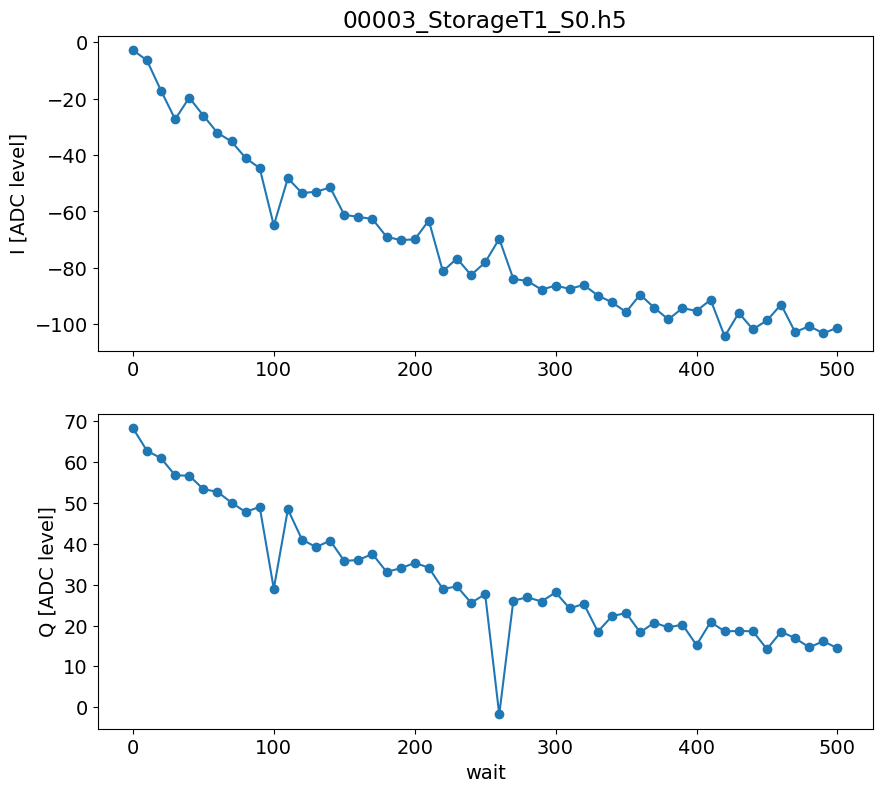

In [53]:
init_stor = 0
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
    ro_stor = init_stor, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    # wait=10, # wait time between two hpi pulses in us
    waits = np.linspace(0,500,51).tolist(),
    swept_params = ['wait'],
    # usage: if you want to sweep cfg.expt.paramName, 
    # include paramName here in this list 
    # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
    # (You want a list instead of numpy array for better yaml export.)
    # Currently handles 1D and 2D sweeps and plots only.
    # For 2D, order is [outer, inner].
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    prepulse = True,
    postpulse = True,
    echoes = [False, 0], # [on/off, number of echoes]
)

qbe = QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"StorageT1_S{expt_params['init_stor']}",
    config_file=config_path,
    expt_params=expt_params,
    program=StorageT1Program,
    progress=True)

qbe.cfg.device.readout.relax_delay = [5000]  # Wait time between experiments [us]
qbe.go(analyze=False, display=True, progress=True, save=True)

# Kerr engineering

  0%|          | 0/200 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00014_KerrQBHeating.h5


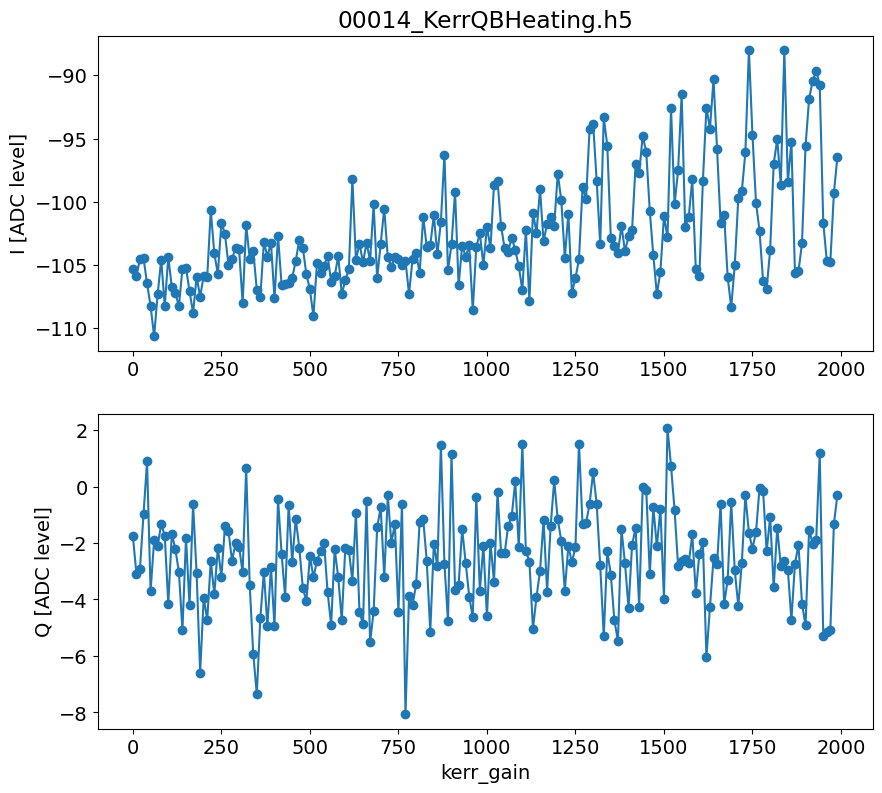

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 0, # storage mode number to initialize to n=1 Fock state
    ro_stor = 0, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    echoes = [False, 0], # [on/off, number of echoes]
    # === new class
    # kerr_gain = 1000,
    kerr_detune = -10,
    kerr_length = 10,
    swept_params = ['kerr_gain'],
    # kerr_lengths = np.linspace(0.007,5,21).tolist(),
    kerr_gains = np.arange(0,2000,10).tolist(),
    prepulse = False,
    postpulse = False,
)

qbe = QsimExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"KerrQBHeating",
    config_file=config_path,
    expt_params=expt_params,
    program=meas.KerrEngBaseProgram,
    progress=True)

qbe.cfg.device.readout.relax_delay = [2000]  # Wait time between experiments [us]
qbe.go(analyze=False, display=True, progress=True, save=True)

## Cavity Ramsey 

This is to find out $\chi$, $\chi'$, $\Delta$ and $K_c$

In [34]:
def do_cavity_ramsey(
    config_thisrun,
    expt_path,
    config_path,
    start=0.01,           # start delay
    step=0.05,            # step size
    expts=200,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,            
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first = True,
    relax_delay=2500      # relax delay
):
    """
    Run the Cavity Ramsey experiment using the specified configuration.
    """
    if user_defined_pulse is None:
        user_defined_pulse = [True, config_thisrun.device.manipulate.f_ge[man_mode_no-1], 10, 
                                config_thisrun.device.manipulate.displace_sigma[man_mode_no-1], 0,
                                  4]
        
    #[on/off, freq, gain, sigma (mus), phase, channel] 
    if man_ramsey is None:
        man_ramsey = [False, man_mode_no -1]
    if custom_coupler_pulse is None:
        custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if pre_sweep_pulse is None:
        pre_sweep_pulse = []
    if post_sweep_pulse is None:
        post_sweep_pulse = []

    cavity_ramsey = meas.single_qubit.t2_cavity.CavityRamseyExperiment(
        soccfg=soc, path=expt_path, prefix='CavityRamseyExperiment', config_file=config_path
    )

    cavity_ramsey.cfg = AttrDict(deepcopy(config_thisrun))

    cavity_ramsey.cfg.expt = dict(
        start=start,                    # start delay
        step=step,                      # step size
        expts=expts,                    # number of experiments
        ramsey_freq=ramsey_freq,        # Ramsey frequency
        reps=reps,                      # repetitions
        rounds=rounds,                  # rounds
        qubits=qubits,                  # qubits
        checkEF=checkEF,                # check EF
        f0g1_cavity=f0g1_cavity,        # f0g1 cavity
        init_gf=init_gf,                # initialize gf
        active_reset=active_reset,      # active reset
        man_reset=man_reset,            # manipulate reset
        storage_reset=storage_reset,    # storage reset
        user_defined_pulse=user_defined_pulse, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
        parity_meas=parity_meas,        # parity measurement
        man_mode_no=man_mode_no,                # manipulate index
        storage_ramsey=storage_ramsey,  # storage Ramsey
        man_ramsey=man_ramsey,          # manipulate Ramsey
        coupler_ramsey=coupler_ramsey,  # coupler Ramsey
        custom_coupler_pulse=custom_coupler_pulse, # custom coupler pulse
        echoes=echoes,                  # echoes
        prepulse=prepulse,              # prepulse
        postpulse=postpulse,            # postpulse
        gate_based=gate_based,          # gate based
        pre_sweep_pulse=pre_sweep_pulse,# pre sweep pulse
        post_sweep_pulse=post_sweep_pulse, # post sweep pulse
        prep_e_first=prep_e_first,  # prepare e first
    )

    cavity_ramsey.cfg.device.readout.relax_delay = [relax_delay]
    cavity_ramsey.go(analyze=False, display=False, progress=True, save=True)
    return cavity_ramsey

In [ ]:
cavity_ramsey = do_cavity_ramsey(
    config_thisrun=config_thisrun,
    expt_path=expt_path,
    config_path=config_file,
    man_mode_no=1, 
    ramsey_freq=1,
    step = 0.02, 
    expts = 100, 
    reps = 100,
    prep_e_first = False,
    # user_defined_pulse=[True, expts_base_inst.config_thisrun.device.manipulate.f_ge[0], 1500, 
    #                             expts_base_inst.config_thisrun.device.manipulate.displace_sigma[0],
    #                               0, 4])
    user_defined_pulse=[True, config_thisrun.device.manipulate.f_ge[0], 2000, 
                                config_thisrun.device.manipulate.displace_sigma[0],
                                  0, 4])


    #user defined pulse [on/off, freq, gain, sigma (mus), phase, channel] )

100


  0%|          | 0/10000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00035_CavityRamseyExperiment.h5


No echoes in the data
Attempted to init fitparam 4 to -39.526406277056275, which is out of bounds -8.151926406926407 to 5.25439393939394. Instead init to -1.4487662337662335
Using user defined frequency: 4984.619558610203 MHz
Current pi pulse frequency: 4984.619558610203
Fit frequency from I [MHz]: 0.36424401901754655 +/- 0.0011338325591566745
Suggested new pi pulse frequency from fit I [MHz]:
 	4984.655314591186
 	4985.383802629221
T2 Ramsey from fit I [us]: 68.42134499725387
Fit frequency from Q [MHz]: 0.35470452184700024 +/- 0.011681988196307986
Suggested new pi pulse frequencies from fit Q [MHz]:
 	4984.664854088356
 	4985.37426313205
T2 Ramsey from fit Q [us]: 6.467222310401915


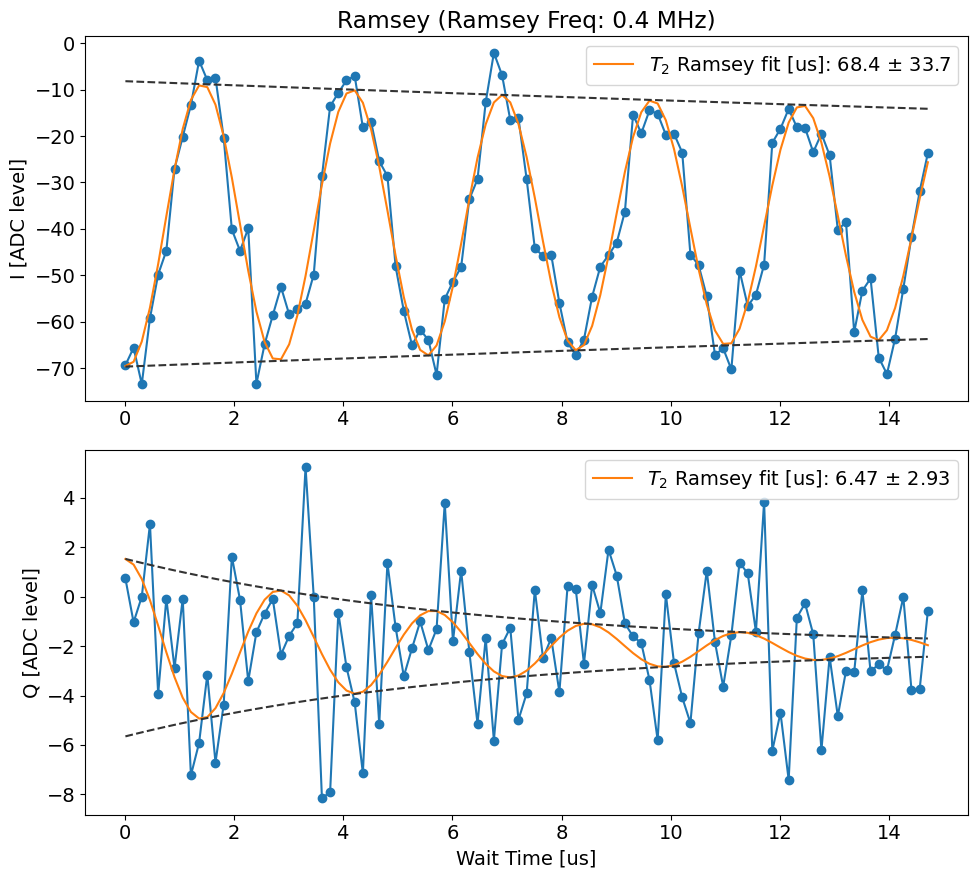

supertitle is  None
Plot saved to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs/plots\2025-11-07_14-36-00_Ramsey.png
Plot path appended to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs\2025-11-07.md


In [40]:
cavity_ramsey.analyze()
cavity_ramsey.display()

### vs gain

In [25]:
def do_cavity_ramsey_gain_sweep(
    config_thisrun,
    expt_path,
    config_path,
    start=0.01,           # start delay
    step=0.05,            # step size
    expts=200,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    gain_start = 1000,  # start gain
    gain_step = 1000,      # step size for gain
    gain_expts = 5,        # number of experiments for gain
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,            
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    relax_delay=2500,      # relax delay
    do_g_and_e=False, # do e-f first
):
    """
    Run the Cavity Ramsey experiment using the specified configuration.
    """
    if user_defined_pulse is None:
        user_defined_pulse = [True,
                              config_thisrun.device.manipulate.f_ge[man_mode_no-1], 
                              1000, 
                              config_thisrun.device.manipulate.displace_sigma[man_mode_no-1], 
                              0,
                              4]
    #[on/off, freq, gain, sigma (mus), length, channel] 
    if man_ramsey is None:
        man_ramsey = [False, man_mode_no -1]
    if custom_coupler_pulse is None:
        custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if pre_sweep_pulse is None:
        pre_sweep_pulse = []
    if post_sweep_pulse is None:
        post_sweep_pulse = []

    cavity_ramsey = meas.single_qubit.t2_cavity.CavityRamseyGainSweepExperiment(
        soccfg=soc, path=expt_path, prefix='CavityRamseyGainSweepExperiment', config_file=config_path
    )

    cavity_ramsey.cfg = AttrDict(deepcopy(config_thisrun))

    cavity_ramsey.cfg.expt = dict(
        start=start,                    # start delay
        step=step,                      # step size
        expts=expts,                    # number of experiments
        ramsey_freq=ramsey_freq,        # Ramsey frequency
        gain_start=gain_start,          # start gain
        gain_step=gain_step,            # step size for gain
        gain_expts=gain_expts,          # number of experiments for gain
        reps=reps,                      # repetitions
        rounds=rounds,                  # rounds
        qubits=qubits,                  # qubits
        checkEF=checkEF,                # check EF
        f0g1_cavity=f0g1_cavity,        # f0g1 cavity
        init_gf=init_gf,                # initialize gf
        active_reset=active_reset,      # active reset
        man_reset=man_reset,            # manipulate reset
        storage_reset=storage_reset,    # storage reset
        user_defined_pulse=user_defined_pulse, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
        parity_meas=parity_meas,        # parity measurement
        man_mode_no=man_mode_no,                # manipulate index
        storage_ramsey=storage_ramsey,  # storage Ramsey
        man_ramsey=man_ramsey,          # manipulate Ramsey
        coupler_ramsey=coupler_ramsey,  # coupler Ramsey
        custom_coupler_pulse=custom_coupler_pulse, # custom coupler pulse
        echoes=echoes,                  # echoes
        prepulse=prepulse,              # prepulse
        postpulse=postpulse,            # postpulse
        gate_based=gate_based,          # gate based
        pre_sweep_pulse=pre_sweep_pulse,# pre sweep pulse
        post_sweep_pulse=post_sweep_pulse, # post sweep pulse
        do_g_and_e=do_g_and_e,  # do e-f first

        qubit_drive_pulse=[True],
    )

    cavity_ramsey.cfg.device.readout.relax_delay = [relax_delay]
    cavity_ramsey.go(analyze=False, display=False, progress=True, save=True)
    return cavity_ramsey



In [29]:
gain_start = 1000
gain_stop = 7000
gain_step = 1000
gain_expts = int((gain_stop - gain_start) / gain_step) + 1
print(f'Gain start: {gain_start}, Gain stop: {gain_stop}, Gain step: {gain_step}, Gain expts: {gain_expts}')

Gain start: 1000, Gain stop: 7000, Gain step: 1000, Gain expts: 7


In [41]:
cavity_ramsey_sweep = do_cavity_ramsey_gain_sweep(
    config_thisrun=config_thisrun,
    expt_path=expt_path,
    config_path=config_file,
    gain_start=gain_start,  # start gain
    gain_step=gain_step,      # step size for gain
    gain_expts=gain_expts,        # number of experiments for gain
    ramsey_freq=0.8,
    step = 0.05, 
    expts = 100, 
    reps = 100,
    do_g_and_e=False,
)

  0%|          | 0/7 [00:00<?, ?it/s]

{(0, '0'): (0, 0), (0, 'freq'): (0, 22), (0, 'phase'): (0, 23), (0, 'addr'): (0, 24), (0, 'gain'): (0, 25), (0, 'mode'): (0, 26), (0, 't'): (0, 27), (0, 'addr2'): (0, 28), (0, 'gain2'): (0, 29), (0, 'mode2'): (0, 30), (0, 'mode3'): (0, 31), (1, '0'): (1, 0), (1, 'freq'): (1, 12), (1, 'phase'): (1, 13), (1, 'addr'): (1, 14), (1, 'gain'): (1, 15), (1, 'mode'): (1, 16), (1, 't'): (1, 17), (1, 'addr2'): (1, 18), (1, 'gain2'): (1, 19), (1, 'mode2'): (1, 20), (1, 'mode3'): (1, 21), (2, '0'): (1, 0), (2, 'freq'): (1, 22), (2, 'phase'): (1, 23), (2, 'addr'): (1, 24), (2, 'gain'): (1, 25), (2, 'mode'): (1, 26), (2, 't'): (1, 27), (2, 'addr2'): (1, 28), (2, 'gain2'): (1, 29), (2, 'mode2'): (1, 30), (2, 'mode3'): (1, 31), (3, '0'): (2, 0), (3, 'freq'): (2, 12), (3, 'phase'): (2, 13), (3, 'addr'): (2, 14), (3, 'gain'): (2, 15), (3, 'mode'): (2, 16), (3, 't'): (2, 17), (3, 'addr2'): (2, 18), (3, 'gain2'): (2, 19), (3, 'mode2'): (2, 20), (3, 'mode3'): (2, 21), (4, '0'): (2, 0), (4, 'freq'): (2, 22),

 14%|█▍        | 1/7 [00:25<02:31, 25.29s/it]

{(0, '0'): (0, 0), (0, 'freq'): (0, 22), (0, 'phase'): (0, 23), (0, 'addr'): (0, 24), (0, 'gain'): (0, 25), (0, 'mode'): (0, 26), (0, 't'): (0, 27), (0, 'addr2'): (0, 28), (0, 'gain2'): (0, 29), (0, 'mode2'): (0, 30), (0, 'mode3'): (0, 31), (1, '0'): (1, 0), (1, 'freq'): (1, 12), (1, 'phase'): (1, 13), (1, 'addr'): (1, 14), (1, 'gain'): (1, 15), (1, 'mode'): (1, 16), (1, 't'): (1, 17), (1, 'addr2'): (1, 18), (1, 'gain2'): (1, 19), (1, 'mode2'): (1, 20), (1, 'mode3'): (1, 21), (2, '0'): (1, 0), (2, 'freq'): (1, 22), (2, 'phase'): (1, 23), (2, 'addr'): (1, 24), (2, 'gain'): (1, 25), (2, 'mode'): (1, 26), (2, 't'): (1, 27), (2, 'addr2'): (1, 28), (2, 'gain2'): (1, 29), (2, 'mode2'): (1, 30), (2, 'mode3'): (1, 31), (3, '0'): (2, 0), (3, 'freq'): (2, 12), (3, 'phase'): (2, 13), (3, 'addr'): (2, 14), (3, 'gain'): (2, 15), (3, 'mode'): (2, 16), (3, 't'): (2, 17), (3, 'addr2'): (2, 18), (3, 'gain2'): (2, 19), (3, 'mode2'): (2, 20), (3, 'mode3'): (2, 21), (4, '0'): (2, 0), (4, 'freq'): (2, 22),

 29%|██▊       | 2/7 [00:50<02:06, 25.29s/it]

...

{(0, '0'): (0, 0), (0, 'freq'): (0, 22), (0, 'phase'): (0, 23), (0, 'addr'): (0, 24), (0, 'gain'): (0, 25), (0, 'mode'): (0, 26), (0, 't'): (0, 27), (0, 'addr2'): (0, 28), (0, 'gain2'): (0, 29), (0, 'mode2'): (0, 30), (0, 'mode3'): (0, 31), (1, '0'): (1, 0), (1, 'freq'): (1, 12), (1, 'phase'): (1, 13), (1, 'addr'): (1, 14), (1, 'gain'): (1, 15), (1, 'mode'): (1, 16), (1, 't'): (1, 17), (1, 'addr2'): (1, 18), (1, 'gain2'): (1, 19), (1, 'mode2'): (1, 20), (1, 'mode3'): (1, 21), (2, '0'): (1, 0), (2, 'freq'): (1, 22), (2, 'phase'): (1, 23), (2, 'addr'): (1, 24), (2, 'gain'): (1, 25), (2, 'mode'): (1, 26), (2, 't'): (1, 27), (2, 'addr2'): (1, 28), (2, 'gain2'): (1, 29), (2, 'mode2'): (1, 30), (2, 'mode3'): (1, 31), (3, '0'): (2, 0), (3, 'freq'): (2, 12), (3, 'phase'): (2, 13), (3, 'addr'): (2, 14), (3, 'gain'): (2, 15), (3, 'mode'): (2, 16), (3, 't'): (2, 17), (3, 'addr2'): (2, 18), (3, 'gain2'): (2, 19), (3, 'mode2'): (2, 20), (3, 'mode3'): (2, 21), (4, '0'): (2, 0), (4, 'freq'): (2, 22),

 86%|████████▌ | 6/7 [02:31<00:25, 25.29s/it]

{(0, '0'): (0, 0), (0, 'freq'): (0, 22), (0, 'phase'): (0, 23), (0, 'addr'): (0, 24), (0, 'gain'): (0, 25), (0, 'mode'): (0, 26), (0, 't'): (0, 27), (0, 'addr2'): (0, 28), (0, 'gain2'): (0, 29), (0, 'mode2'): (0, 30), (0, 'mode3'): (0, 31), (1, '0'): (1, 0), (1, 'freq'): (1, 12), (1, 'phase'): (1, 13), (1, 'addr'): (1, 14), (1, 'gain'): (1, 15), (1, 'mode'): (1, 16), (1, 't'): (1, 17), (1, 'addr2'): (1, 18), (1, 'gain2'): (1, 19), (1, 'mode2'): (1, 20), (1, 'mode3'): (1, 21), (2, '0'): (1, 0), (2, 'freq'): (1, 22), (2, 'phase'): (1, 23), (2, 'addr'): (1, 24), (2, 'gain'): (1, 25), (2, 'mode'): (1, 26), (2, 't'): (1, 27), (2, 'addr2'): (1, 28), (2, 'gain2'): (1, 29), (2, 'mode2'): (1, 30), (2, 'mode3'): (1, 31), (3, '0'): (2, 0), (3, 'freq'): (2, 12), (3, 'phase'): (2, 13), (3, 'addr'): (2, 14), (3, 'gain'): (2, 15), (3, 'mode'): (2, 16), (3, 't'): (2, 17), (3, 'addr2'): (2, 18), (3, 'gain2'): (2, 19), (3, 'mode2'): (2, 20), (3, 'mode3'): (2, 21), (4, '0'): (2, 0), (4, 'freq'): (2, 22),

100%|██████████| 7/7 [02:56<00:00, 25.29s/it]

Saving D:\experiments\251031_qsim\data\00011_CavityRamseyGainSweepExperiment.h5


C:\_Lib\python\multimode_expts\fit_display_classes.py:494: RuntimeWarning: invalid value encountered in divide
  _pop_norm = (_pop - np.max(_pop)) / (np.min(_pop) - np.max(_pop))


gain_to_alpha 0.0002459735289304684
kwargs {}
Kerr : -14.092 +/- 4.863 kHz
detuning Ground State: -52.443 +/- 7.605 kHz


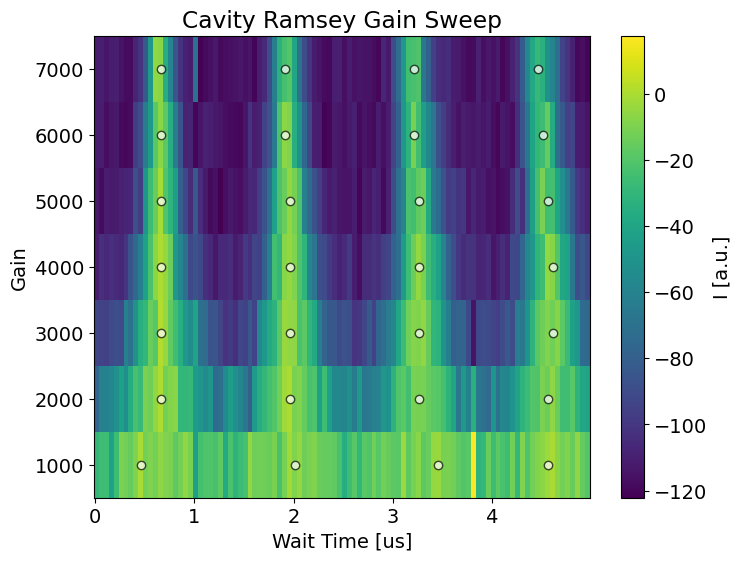

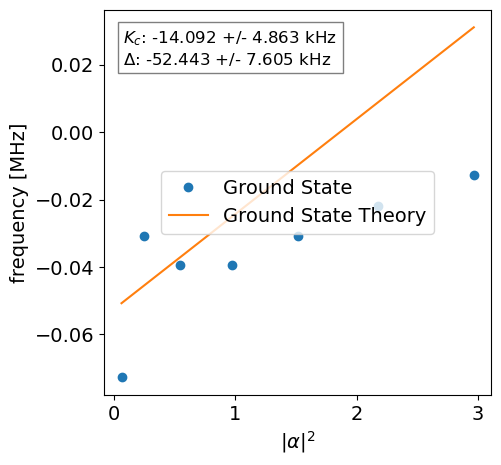

In [42]:
cavity_ramsey_sweep.analyze()
cavity_ramsey_sweep.display()
delta_g = cavity_ramsey_sweep.data['detuning_g']

# config_thisrun.device.manipulate.f_ge[0] -= delta_g
# print(f"Updated f_ge frequency: {config_thisrun.device.manipulate.f_ge[0]} MHz")

## with kerr

In [9]:
kerr_ramsey_defaults = AttrDict(dict(
    start=0.01,           # start delay
    step=0.02,            # step size
    expts=100,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    kerr_gain=2000,
    kerr_detune=-10,
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=False,     # parity measurement # this will not do anything if doing a displacement because the code is cursed
    man_mode_no=1,
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first=True,
    normalize=False,
    swept_params=['displace_gain', 'kerr_detune'],
    kerr_detunes = np.linspace(-100, 100, 5).tolist(),
    displace_gains = np.arange(2000, 8001, 1000).tolist(),
    kerr_drive_type='man-qubit', # 'man-coupler', 'qubit'
    relax_delay=2500,
))

def kerr_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    man_mode_no = expt_cfg.man_mode_no
    hw = station.hardware_cfg

    if expt_cfg.user_defined_pulse is None:
        expt_cfg.user_defined_pulse = [
            True,
            hw.device.manipulate.f_ge[man_mode_no - 1], # freq
            2000,  # will be overridden if expt_cfg.displace_gain is set! # gain
            hw.device.manipulate.displace_sigma[man_mode_no - 1], # sigma
            0, # length
            4, # proxy for ch for displacement, 4 = man
        ]
    
    # [on/off, freq, gain, sigma (mus), length, channel]
    if expt_cfg.man_ramsey is None:
        expt_cfg.man_ramsey = [False, man_mode_no - 1]
    if expt_cfg.custom_coupler_pulse is None and expt_cfg.kerr_drive_type == 'man-coupler':
        expt_cfg.custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if expt_cfg.pre_sweep_pulse is None:
        expt_cfg.pre_sweep_pulse = []
    if expt_cfg.post_sweep_pulse is None:
        expt_cfg.post_sweep_pulse = []

    print(expt_cfg)
    return expt_cfg

def kerr_ramsey_postproc(station, expt):
    expt = meas.KerrCavityRamseyExperiment.from_h5file(expt.fname)
    expt.analyze()
    expt.display()

In [28]:
kerr_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimExperiment,
    ExptProgram=meas.qsim.kerr.KerrCavityRamseyProgram,
    default_expt_cfg=kerr_ramsey_defaults,
    preprocessor=kerr_ramsey_preproc,
    # postprocessor=kerr_ramsey_postproc,
    job_client=client,
)

# kerr_detunes = np.linspace(-50, -10, 5).tolist()
kerr_detunes = [0]
# kerr_gains = np.arange(500, 3000, 500)
kerr_gains = [0]
# kerr_gain = station.ds_storage.get_gain('M1')

# kerr_lengths = np.linspace(0.010, 3, 75).tolist()
# displace_gains = np.arange(2000, 7001, 1000).tolist()
kerr_lengths = np.linspace(0.010, 15, 300).tolist()
displace_gains = np.arange(2000, 15001, 3000).tolist()
print("kerr_detunes", kerr_detunes)
print("kerr_gains", kerr_gains)

print("kerr_lengths", kerr_lengths)
print("displace_gains", displace_gains)

kerr_expts = []

for kerr_gain in kerr_gains:
    for kerr_detune in kerr_detunes:
        print("kerr gain:", kerr_gain)
        print("kerr detune:", kerr_detune)
        kerr_ramsey = kerr_ramsey_runner.execute(
            ramsey_freq=1,
            kerr_gain=kerr_gain, # gain for kerr pulse
            kerr_detune=kerr_detune,
            reps=50,
            prep_e_first=False,

            swept_params = ['displace_gain', 'kerr_length'],
            kerr_lengths = kerr_lengths,
            displace_gains = displace_gains,
            # displace_gain = 5000,
            kerr_drive_type=None, # 'man-qubit', # 'man-coupler', 'qubit

            # active_reset=False,
            # # man_reset=True,

            active_reset=True,
            man_reset=True,
            # storage_reset=[cross_kerr_stor],
            storage_reset=False,
            use_qubit_man_reset=True,
            pre_selection_reset=False,
            relax_delay=1500,
        )
        kerr_expts.append(kerr_ramsey)
        # kerr_ramsey.display()
        plt.show()

kerr_detunes [0]
kerr_gains [0]
kerr_lengths [0.01, 0.06013377926421405, 0.1102675585284281, 0.16040133779264215, 0.2105351170568562, 0.26066889632107026, 0.3108026755852843, 0.3609364548494984, 0.4110702341137124, 0.46120401337792644, 0.5113377926421405, 0.5614715719063545, 0.6116053511705686, 0.6617391304347826, 0.7118729096989967, 0.7620066889632108, 0.8121404682274248, 0.8622742474916388, 0.9124080267558529, 0.962541806020067, 1.012675585284281, 1.062809364548495, 1.112943143812709, 1.1630769230769231, 1.2132107023411371, 1.2633444816053512, 1.3134782608695652, 1.3636120401337795, 1.4137458193979935, 1.4638795986622075, 1.5140133779264215, 1.5641471571906356, 1.6142809364548496, 1.6644147157190636, 1.7145484949832777, 1.7646822742474917, 1.8148160535117057, 1.8649498327759197, 1.915083612040134, 1.965217391304348, 2.015351170568562, 2.0654849498327756, 2.11561872909699, 2.165752508361204, 2.215886287625418, 2.266020066889632, 2.316153846153846, 2.3662876254180603, 2.416421404682274

D:\experiments\260218_qsim_scramble_low_kerr\data\JOB-20260225-00040_QsimBaseExperiment.h5


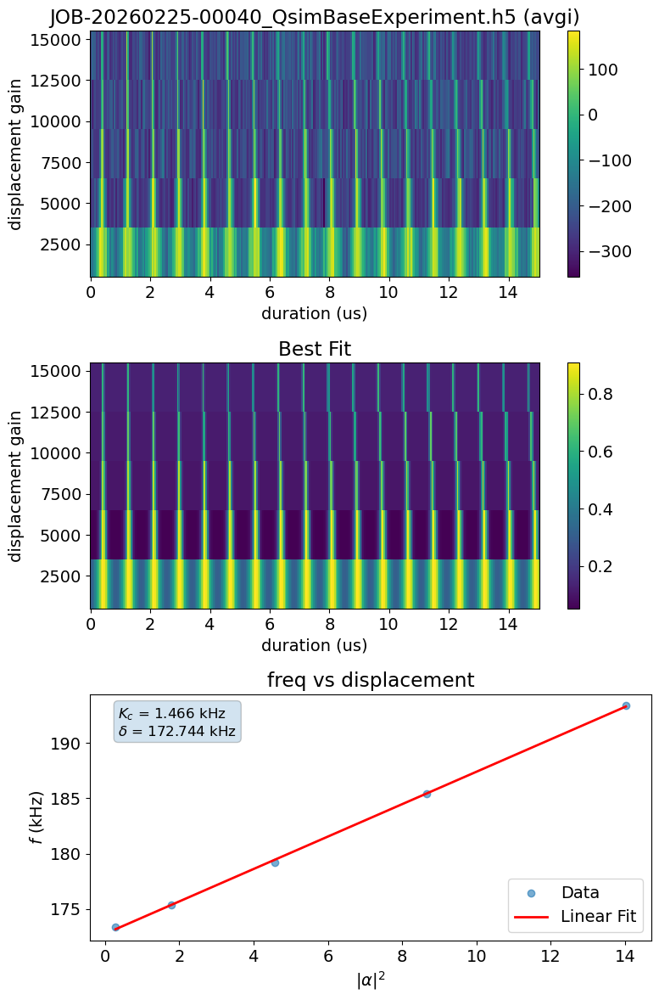

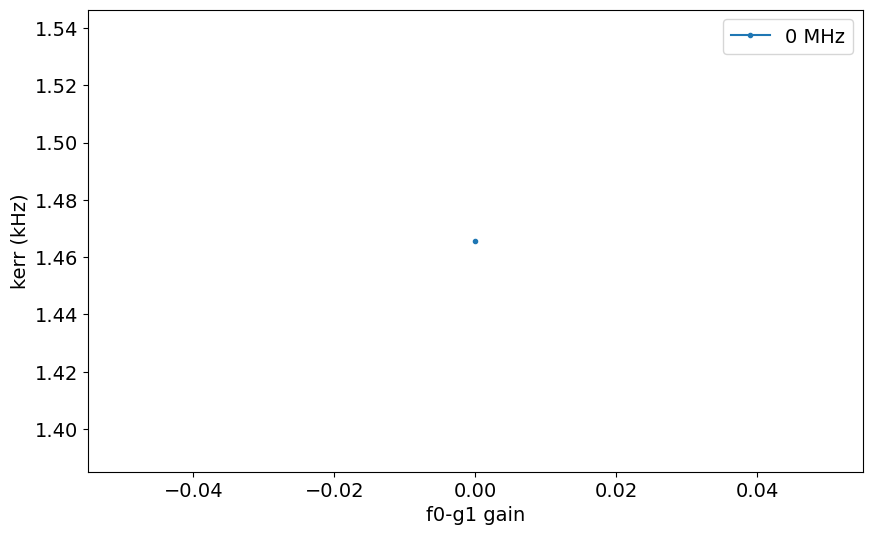

In [29]:
kerr_meas = []
for kerr_expt in kerr_expts:
    print(kerr_expt.fname)
    expt = meas.KerrCavityRamseyExperiment.from_h5file(kerr_expt.fname)
    data = expt.data
    expt.analyze()
    expt.display()
    kerr_meas.append(expt.fit_results['kc'])

kerr_meas = np.array(kerr_meas)
plt.figure()
plt.plot(kerr_gains, 1e3*np.array(kerr_meas), '.-', label=f'{kerr_detunes[0]} MHz') 
plt.xlabel("f0-g1 gain")
plt.ylabel("kerr (kHz)")
plt.legend()
plt.show()

kerr detune: -50.0


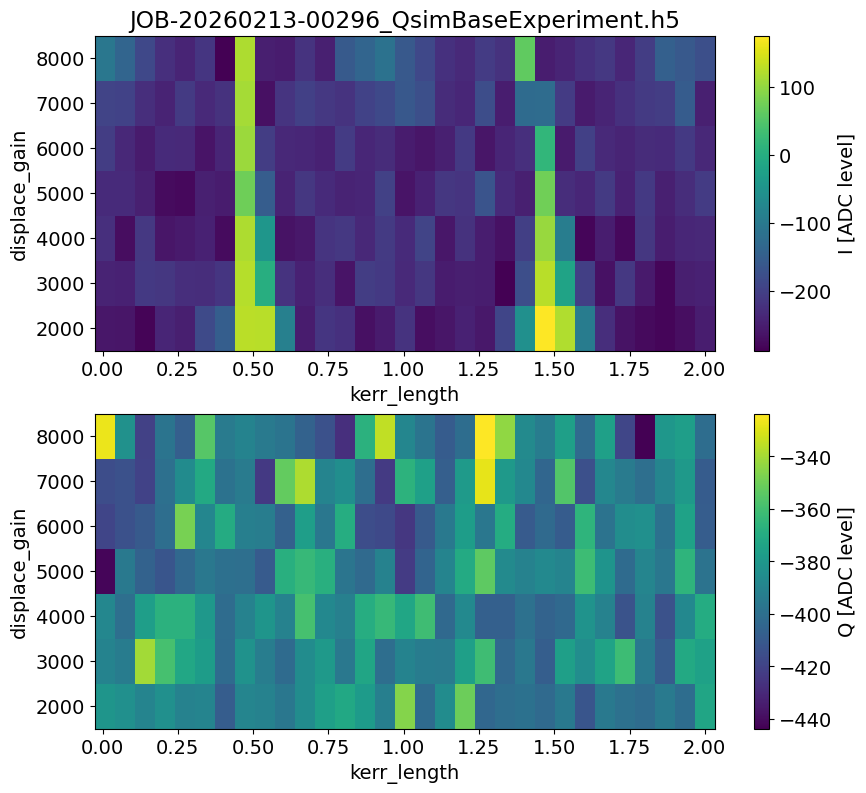

kerr detune: -16.666666666666664


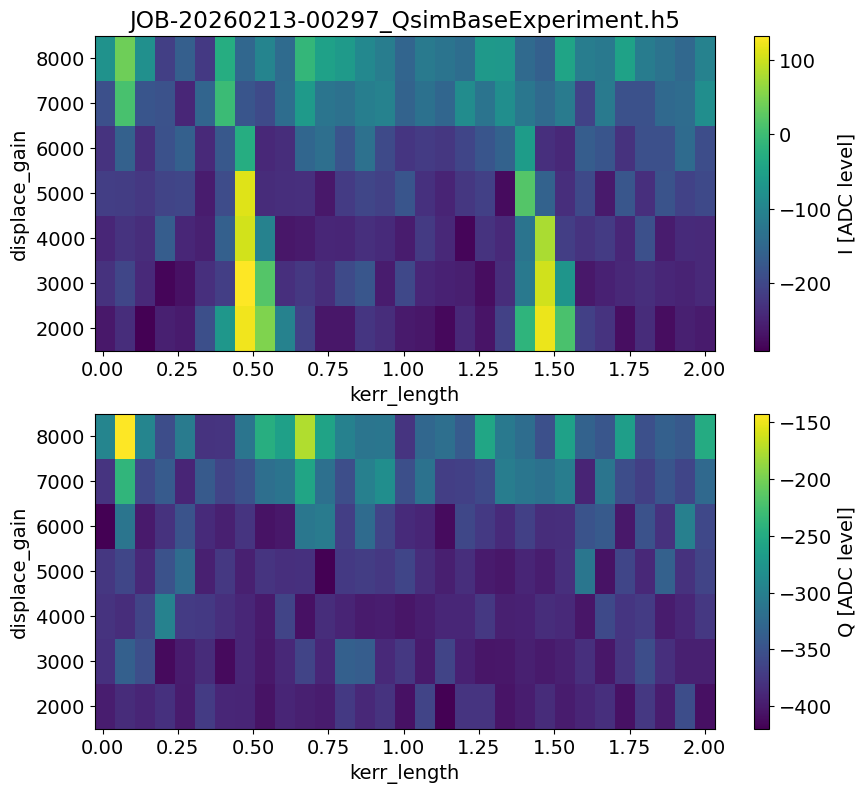

kerr detune: 16.66666666666667


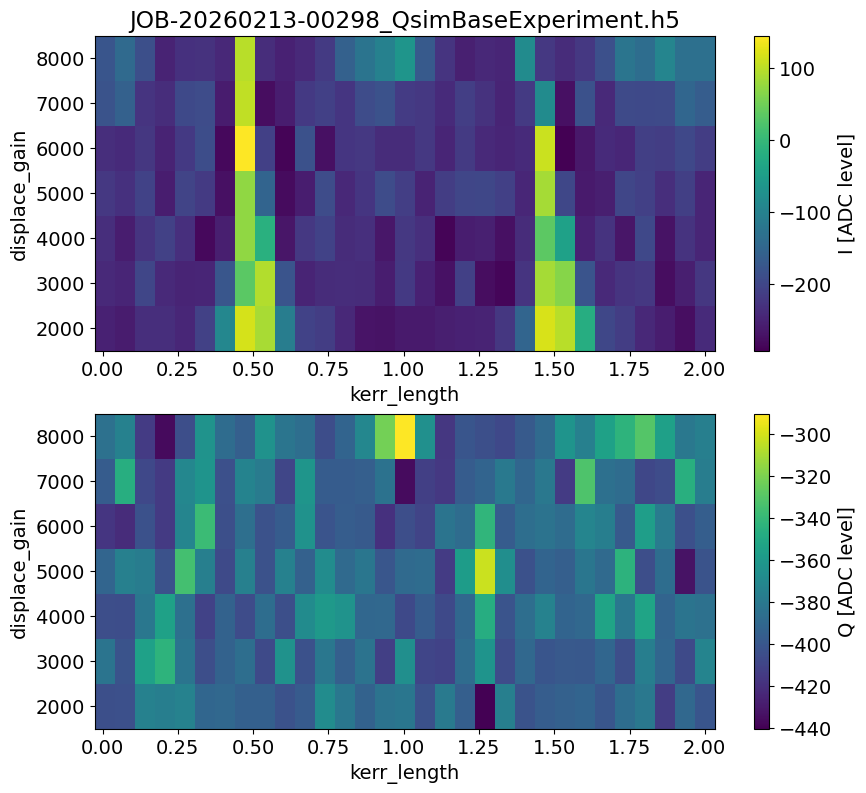

kerr detune: 50.0


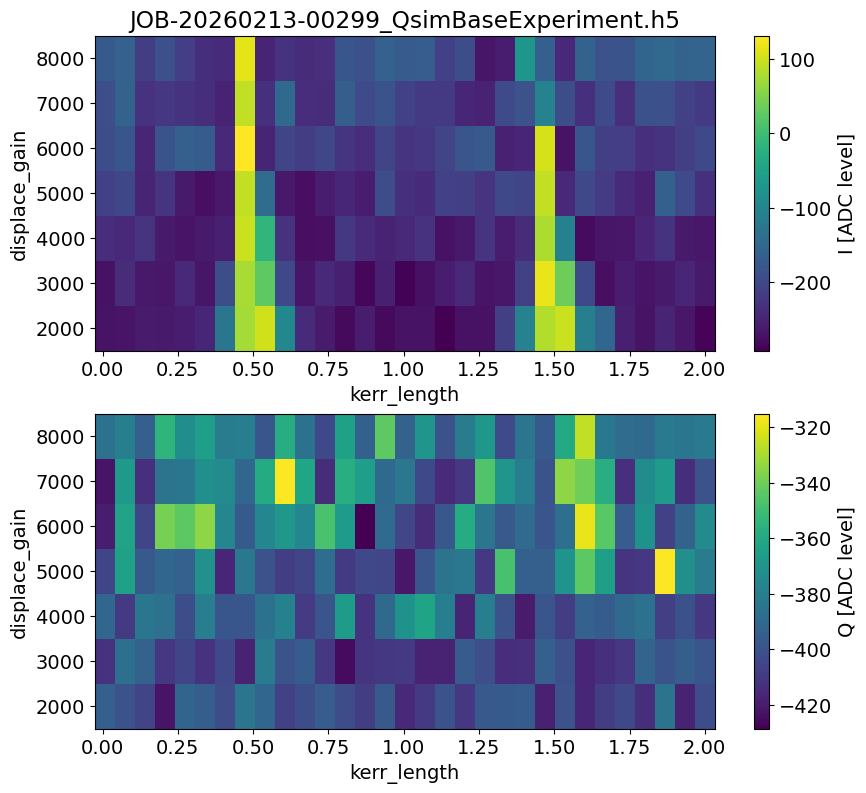

In [22]:
# Reopen old data
expt_objs = [
    "D:\\experiments\\260130_qsim_kerr_engineering\\expt_objs\\JOB-20260213-00296_expt.pkl",
    "D:\\experiments\\260130_qsim_kerr_engineering\\expt_objs\\JOB-20260213-00297_expt.pkl",
    "D:\\experiments\\260130_qsim_kerr_engineering\\expt_objs\\JOB-20260213-00298_expt.pkl",
    "D:\\experiments\\260130_qsim_kerr_engineering\\expt_objs\\JOB-20260213-00299_expt.pkl",
]

# h5_files = [
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00129_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00131_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00133_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00134_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00136_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00138_QsimWignerBaseExperiment.h5"
# ]

import pickle
for i, expt_obj in enumerate(expt_objs):
    print("kerr detune:", kerr_detunes[i])
    with open(expt_obj, "rb") as f:
        kerr_ramsey = pickle.load(f)
        kerr_ramsey.display()
        plt.show()

In [ ]:
for kerr_detune in [-30,-20,-10,-5,0,5,10,20,30]:
    print(f'detune {kerr_detune}')
    for kerr_gain in range(200,2901,300):
        # print(f"Running Kerr Ramsey with kerr_gain = {kerr_gain}")
        kerr_ramsey = do_kerr_ramsey(
            config_thisrun=config_thisrun,
            expt_path=expt_path,
            config_path=config_file,
            ramsey_freq=1.5,
            kerr_gain=kerr_gain,
            kerr_detune=kerr_detune,
            # step = 0.04, 
            # expts = 150, 
            reps = 100,
            prep_e_first=False,
            # active_reset=True,
            # man_reset=True,
            # relax_delay=300,
        )

## cross kerr

(no kerr engineering)

currently this requires that man is displaced and stor mode has 1 prepared (because the t2 cavity experiment does prepulse before doing man displacement, there is no way to directly displace stor without going through man)

run this once with cross_kerr_init_state = 0 and once with 1


I DON'T THINK THIS WORKS... use the t2_cavity_mode experiment in single qubit autocalibrate: manipulate -> t2

In [18]:
cross_kerr_sweep_defaults = AttrDict(dict(
    start=0.01,           # start delay
    step=0.05,            # step size
    expts=200,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    gain_start = 1000,  # start gain
    gain_step = 1000,      # step size for gain
    gain_expts = 5,        # number of experiments for gain
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=False,     # parity measurement # this will not do anything if doing a displacement because the code is cursed
    man_mode_no=1,            
    ramsey_stor=0, # mode to do displacements on
    cross_kerr_stor=1, # mode to check cross kerr from
    cross_kerr_init_fock=0, # fock state to init the cross kerr stor mode
    coupler_ramsey=False, # coupler Ramsey
    man_ramsey=[False, None], # this is to put a fock state in man!!!
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=True,       # prepulse before doing the displacement of man
    postpulse=False,      # postpulse
    gate_based=True,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    relax_delay=2500,      # relax delay
    do_g_and_e=False, # do e-f first
))

def cross_kerr_sweep_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    man_mode_no = expt_cfg.man_mode_no
    cross_kerr_stor = expt_cfg.cross_kerr_stor # 0 for man, >0 for stor
    if expt_cfg.cross_kerr_stor is not None:
        assert cross_kerr_stor != expt_cfg.ramsey_stor
        assert expt_cfg.ramsey_stor == 0, "currently not implemented stor-stor cross kerr, this would need a prepulse that is a displacement"
    expt_cfg.storage_ramsey = [False]

    if expt_cfg.user_defined_pulse is None: # this is to do the man displacement, CavityRamseyGainSweepExperiment will sweep the gain
        dummy_gain = 0
        expt_cfg.user_defined_pulse = [True, station.hardware_cfg.device.manipulate.f_ge[man_mode_no-1], dummy_gain, station.hardware_cfg.device.manipulate.displace_sigma[man_mode_no-1], 0, 4] # 4 means to use the man_ch (not the f0g1 ch)

    if expt_cfg.pre_sweep_pulse is None and expt_cfg.prepulse:
        assert expt_cfg.gate_based
        expt_cfg.pre_sweep_pulse = []
        if expt_cfg.cross_kerr_init_fock == 1:
            expt_cfg.pre_sweep_pulse = [
                ['qubit', 'ge', 'pi', 0,],
                ['qubit', 'ef', 'pi', 0,], # qubit in f
                ['man', 'M1', 'pi', 0,], # f0-g1 --> man in 1
                ['storage', f'M1-S{expt_cfg.cross_kerr_stor}', 'pi', 0,],
            ]
        if expt_cfg.cross_kerr_init_fock > 1: assert False, "initializing stor mode in fock state > 1 is not supported currently"

    if expt_cfg.post_sweep_pulse is None:
        expt_cfg.post_sweep_pulse = [] # directly do the slow pi pulse: qubit in e if man is in 0, else qubit in g

    return expt_cfg

cross_kerr_gain_sweep_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t2_cavity.CavityRamseyGainSweepExperiment,
    default_expt_cfg=cross_kerr_sweep_defaults,
    preprocessor=cross_kerr_sweep_preproc,
    job_client=client,
)

Gain start: 3000, Gain stop: 15000, Gain step: 5000, Gain expts: 3
Job submitted: JOB-20260225-00033 (queue position: 1)

[0.1s] Job JOB-20260225-00033: pending

[2.1s] Job JOB-20260225-00033: running
[WORKER] Loading CavityRamseyGainSweepExperiment from experiments.single_qubit.t2_cavity
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260225-00033_CavityRamseyGainSweepExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 67%|█████████████████████████████▎              | 2/3 [00:23<00:11, 11.86s/it]
[43.3s] Job JOB-20260225-00033: completed
100%|████████████████████████████████████████████| 3/3 [00:35<00:00, 11.82s/it]
gain_to_alpha 0.0002674345185926559
kwargs {}
Saving D:\experiments\260218_qsim_scramble_low_kerr\data\JOB-20260225-00033_CavityRamseyGainSweepExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260218_qsim_scramble_low_kerr\expt_objs\

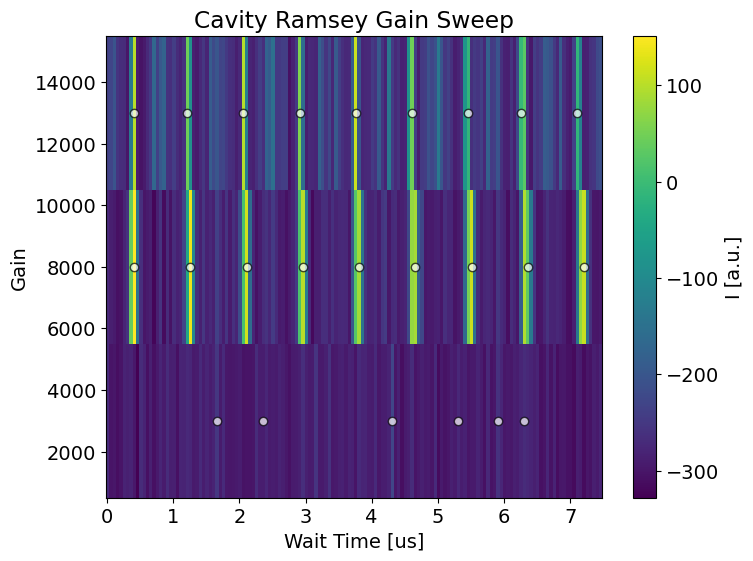

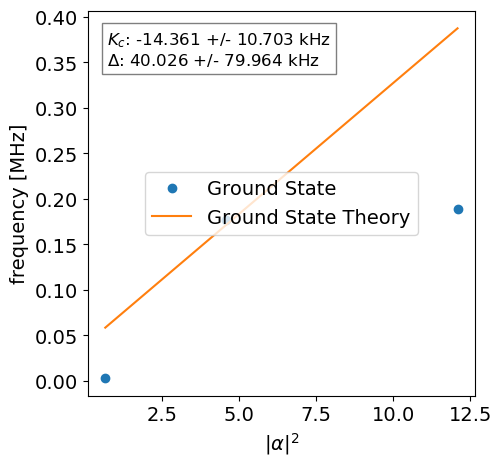

In [ ]:
gain_start = 3000
gain_stop = 15000
gain_step = 5000

cross_kerr_stor = None

gain_expts = int((gain_stop - gain_start) / gain_step) + 1
print(f'Gain start: {gain_start}, Gain stop: {gain_stop}, Gain step: {gain_step}, Gain expts: {gain_expts}')

cross_kerr_gain_sweep_expts = []

for cross_kerr_init_fock in [0]:
# for cross_kerr_init_fock in [0, 1]:
    cross_kerr_gain_sweep_expt = cross_kerr_gain_sweep_runner.execute(
        # ramsey_freq=0.1,
        # step=0.4,
        # expts=70,
        ramsey_freq=1,
        step=0.05,
        expts=150, #300,
        prepulse=False,

        reps=50,
        gain_start=gain_start,  # start gain
        gain_step=gain_step,      # step size for gain
        gain_expts=gain_expts,        # number of experiments for gain
        do_g_and_e=False,
        ramsey_stor=0,
        cross_kerr_stor=cross_kerr_stor,

        cross_kerr_init_fock=cross_kerr_init_fock,

        # active_reset=False,
        # relax_delay=8000,

        active_reset=True,
        man_reset=True,
        # storage_reset=[cross_kerr_stor],
        storage_reset=False,
        use_qubit_man_reset=True,
        pre_selection_reset=False,
        relax_delay=1500,
    )
    cross_kerr_gain_sweep_expts.append(cross_kerr_gain_sweep_expt)
    cross_kerr_gain_sweep_expt.display()
    plt.show()

Gain start: 3000, Gain stop: 3200, Gain step: 200, Gain expts: 2
Job submitted: JOB-20260224-00329 (queue position: 1)

[0.1s] Job JOB-20260224-00329: pending

[18.9s] Job JOB-20260224-00329: running
[WORKER] Loading CavityRamseyGainSweepExperiment from experiments.single_qubit.t2_cavity
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260224-00329_CavityRamseyGainSweepExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
  0%|                                                    | 0/2 [00:00<?, ?it/s]pre pulse
gate based prepulse
 50%|█████████████████████▌                     | 1/2 [02:00<02:00, 120.66s/it]pre pulse
gate based prepulse

[277.5s] Job JOB-20260224-00329: completed
100%|███████████████████████████████████████████| 2/2 [04:01<00:00, 120.51s/it]
gain_to_alpha 0.00031210237952875226
kwargs {}
Saving D:\experiments\260224_cross_kerr\data\JOB-20260224-

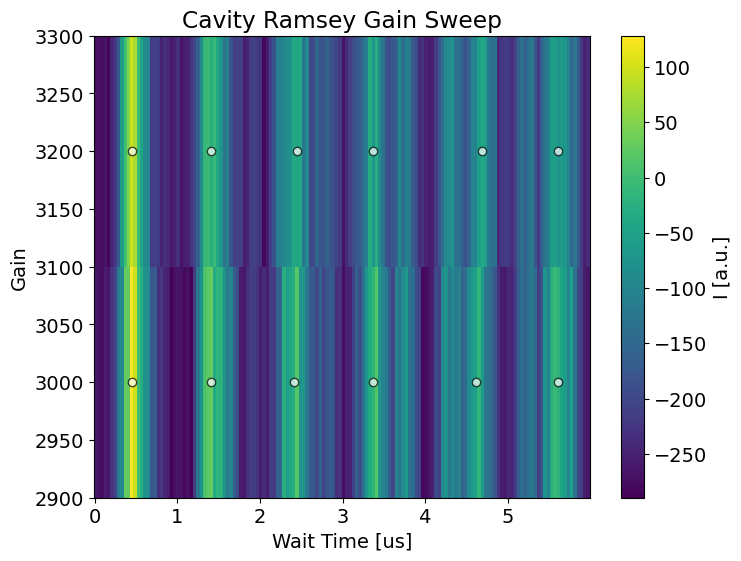

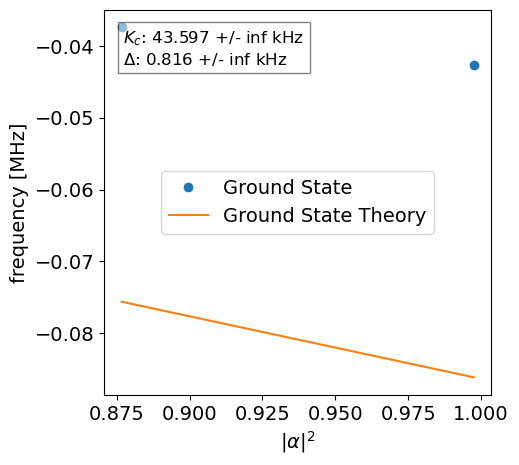

Job submitted: JOB-20260224-00331 (queue position: 1)

[0.1s] Job JOB-20260224-00331: pending

[67.8s] Job JOB-20260224-00331: running
[WORKER] Loading CavityRamseyGainSweepExperiment from experiments.single_qubit.t2_cavity
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260224-00331_CavityRamseyGainSweepExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
  0%|                                                    | 0/2 [00:00<?, ?it/s]pre pulse
gate based prepulse
 50%|█████████████████████▌                     | 1/2 [02:00<02:00, 120.35s/it]pre pulse
gate based prepulse

[327.7s] Job JOB-20260224-00331: completed
100%|███████████████████████████████████████████| 2/2 [04:00<00:00, 120.35s/it]
gain_to_alpha 0.00031210237952875226
kwargs {}
Saving D:\experiments\260224_cross_kerr\data\JOB-20260224-00331_CavityRamseyGainSweepExperiment.h5
[WORKER] Saving expt obj

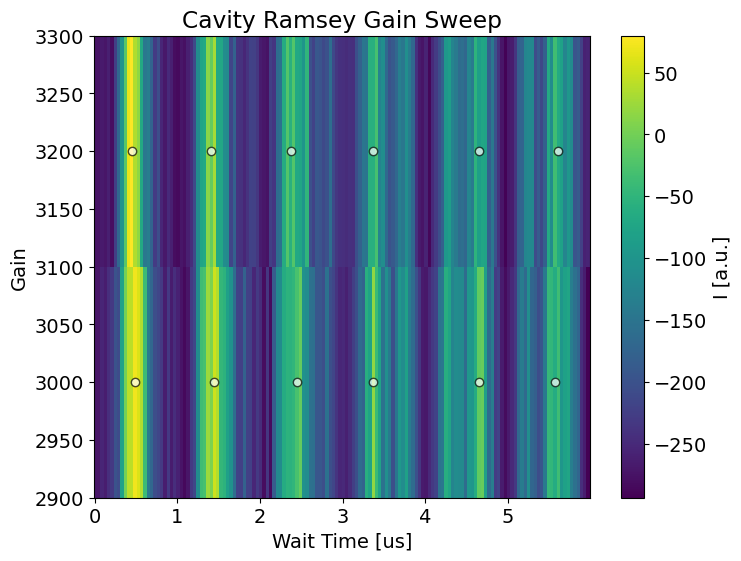

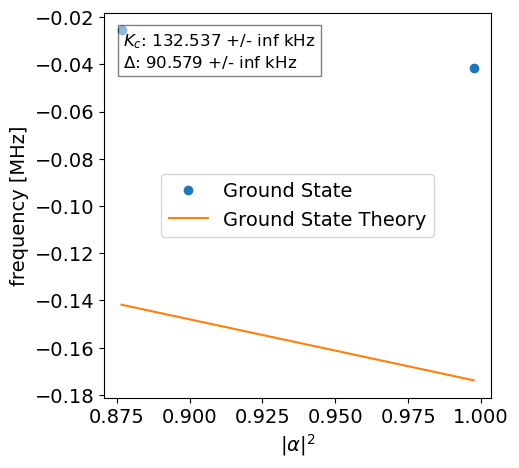

In [48]:
gain_start = 3000
gain_stop = 3200
gain_step = 200

cross_kerr_stor = 7

gain_expts = int((gain_stop - gain_start) / gain_step) + 1
print(f'Gain start: {gain_start}, Gain stop: {gain_stop}, Gain step: {gain_step}, Gain expts: {gain_expts}')

cross_kerr_gain_sweep_expts = []

for cross_kerr_init_state in [0, 1]:
    cross_kerr_gain_sweep_expt = cross_kerr_gain_sweep_runner.execute(
        ramsey_freq=1,
        step=0.040,
        expts=150,
        reps=100,
        gain_start=gain_start,  # start gain
        gain_step=gain_step,      # step size for gain
        gain_expts=gain_expts,        # number of experiments for gain
        do_g_and_e=False,
        ramsey_stor=0,
        cross_kerr_stor=cross_kerr_stor,

        cross_kerr_init_state=cross_kerr_init_state,

        active_reset=False,
        relax_delay=8000,

        # active_reset=True,
        # man_reset=True,
        # storage_reset=[cross_kerr_stor],
        # use_qubit_man_reset=True,
        # pre_selection_reset=False,
        # relax_delay=1500,
    )
    cross_kerr_gain_sweep_expts.append(cross_kerr_gain_sweep_expt)
    cross_kerr_gain_sweep_expt.display()
    plt.show()

In [16]:
kerr_meas = []
for kerr_expt in [cross_kerr_gain_sweep]:
    print(kerr_expt.fname)
    expt = meas.KerrCavityRamseyExperiment.from_h5file(kerr_expt.fname)
    expt.analyze()
    expt.display()
    kerr_meas.append(expt.fit_results['kc'])

kerr_meas = np.array(kerr_meas)
plt.figure()
plt.plot(kerr_gains, 1e3*np.array(kerr_meas), '.-', label=f'{kerr_detunes[0]} MHz') 
plt.xlabel("f0-g1 gain")
plt.ylabel("kerr (kHz)")
plt.legend()
plt.show()

D:\experiments\260224_cross_kerr\data\JOB-20260224-00270_CavityRamseyGainSweepExperiment.h5


KeyError: 'ypts'

In [ ]:
# def do_kerr_ramsey(
#     config_thisrun,
#     expt_path,
#     config_path,
#     start=0.01,           # start delay
#     step=0.02,            # step size
#     expts=100,            # number of experiments
#     ramsey_freq=3.7,      # Ramsey frequency
#     kerr_gain=2000,
#     kerr_detune=-10,
#     reps=100,              # repetitions
#     rounds=1,             # rounds
#     qubits=[0],           # qubits
#     checkEF=False,        # check EF
#     f0g1_cavity=0,        # f0g1 cavity
#     init_gf=False,        # initialize gf
#     active_reset=False,   # active reset
#     man_reset=True,       # manipulate reset
#     storage_reset=True,   # storage reset
#     user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
#     parity_meas=True,     # parity measurement
#     man_mode_no=1,            
#     storage_ramsey=[False, 2, True], # storage Ramsey
#     man_ramsey=None,      # manipulate Ramsey
#     coupler_ramsey=False, # coupler Ramsey
#     custom_coupler_pulse=None, # custom coupler pulse
#     echoes=[False, 0],    # echoes
#     prepulse=False,       # prepulse
#     postpulse=False,      # postpulse
#     gate_based=False,     # gate based
#     pre_sweep_pulse=None, # pre sweep pulse
#     post_sweep_pulse=None,# post sweep pulse
#     prep_e_first = True,
#     relax_delay=2500      # relax delay
# ):
#     """
#     Run the Cavity Ramsey experiment using the specified configuration.
#     """
#     if user_defined_pulse is None:
#         user_defined_pulse = [True,
#                               config_thisrun.device.manipulate.f_ge[man_mode_no-1], 
#                               2000, # will be overridden if expt_params.displace_gain is set! 
#                               config_thisrun.device.manipulate.displace_sigma[man_mode_no-1], 
#                               0,
#                               4]
        
#     #[on/off, freq, gain, sigma (mus), length, channel] 
#     if man_ramsey is None:
#         man_ramsey = [False, man_mode_no -1]
#     if custom_coupler_pulse is None:
#         custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
#     if pre_sweep_pulse is None:
#         pre_sweep_pulse = []
#     if post_sweep_pulse is None:
#         post_sweep_pulse = []

#     expt_params = dict(
#         start=start,                    # start delay
#         step=step,                      # step size
#         expts=expts,                    # number of experiments
#         ramsey_freq=ramsey_freq,        # Ramsey frequency
#         reps=reps,                      # repetitions
#         rounds=rounds,                  # rounds
#         qubits=qubits,                  # qubits
#         checkEF=checkEF,                # check EF
#         f0g1_cavity=f0g1_cavity,        # f0g1 cavity
#         init_gf=init_gf,                # initialize gf
#         active_reset=active_reset,      # active reset
#         man_reset=man_reset,            # manipulate reset
#         storage_reset=storage_reset,    # storage reset
#         user_defined_pulse=user_defined_pulse, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
#         parity_meas=parity_meas,        # parity measurement
#         man_mode_no=man_mode_no,                # manipulate index
#         storage_ramsey=storage_ramsey,  # storage Ramsey
#         man_ramsey=man_ramsey,          # manipulate Ramsey
#         coupler_ramsey=coupler_ramsey,  # coupler Ramsey
#         custom_coupler_pulse=custom_coupler_pulse, # custom coupler pulse
#         echoes=echoes,                  # echoes
#         prepulse=prepulse,              # prepulse
#         postpulse=postpulse,            # postpulse
#         gate_based=gate_based,          # gate based
#         pre_sweep_pulse=pre_sweep_pulse,# pre sweep pulse
#         post_sweep_pulse=post_sweep_pulse, # post sweep pulse
#         prep_e_first=prep_e_first,  # prepare e first
#         normalize = False,
#         kerr_gain = kerr_gain,
#         kerr_detune = kerr_detune,
#         # kerr_length = 10,
#         # swept_params = ['kerr_length'],
#         swept_params = ['displace_gain', 'kerr_detune'],
#         # swept_params = ['displace_gain', 'kerr_length'],
#         # kerr_lengths = np.linspace(0.007,3,101).tolist(),
#         kerr_detunes = np.linspace(-100, 100, 5).tolist()
#         displace_gains = np.arange(2000,8001,1000).tolist(),
#         # displace_gain = 5000,
#         kerr_drive_type='man-qubit', # 'man-coupler', 'qubit
#     )

#     cavity_ramsey = QsimExperiment(
#     soccfg=soc,
#     path=expt_path,
#     prefix=f"KerrRamseyExperiment",
#     config_file=config_path,
#     expt_params=expt_params,
#     program=meas.qsim.kerr.KerrCavityRamseyProgram,
#     progress=True)

#     cavity_ramsey.cfg = AttrDict(deepcopy(config_thisrun))

#     cavity_ramsey.cfg.expt = expt_params

#     cavity_ramsey.cfg.device.readout.relax_delay = [relax_delay]
#     cavity_ramsey.go(analyze=False, display=False, progress=True, save=True)
#     return cavity_ramsey


In [ ]:
# kerr_ramsey = do_kerr_ramsey(
#     config_thisrun=config_thisrun,
#     expt_path=expt_path,
#     config_path=config_file,
#     ramsey_freq=1,
#     kerr_gain=0,
#     kerr_detune=-30,
#     # step = 0.04, 
#     # expts = 150, 
#     reps = 100,
#     prep_e_first=False,
#     # active_reset=True,
#     # man_reset=True,
#     # relax_delay=300,
# )

  0%|          | 0/7 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00362_KerrRamseyExperiment.h5


## Qubit rabi

In [20]:
from multimode_expts.experiments.single_qubit.amplitude_rabi import AmplitudeRabiExperiment, AmplitudeRabiChevronExperiment
from multimode_expts.experiments.single_qubit.length_rabi import LengthRabiExperiment

  0%|          | 0/100 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00003_LengthRabiExperiment.h5
Decay from avgi [us] 6.2438527410153455
Pi length from avgi data [us]: 0.031232802297960428
	Pi/2 length from avgi data [us]: 0.015616401148980214

Decay from avgq [us] 2.236423934894977
Pi length from avgq data [us]: 0.030617603252438664
Pi/2 length from avgq data [us]: 0.015308801626219332


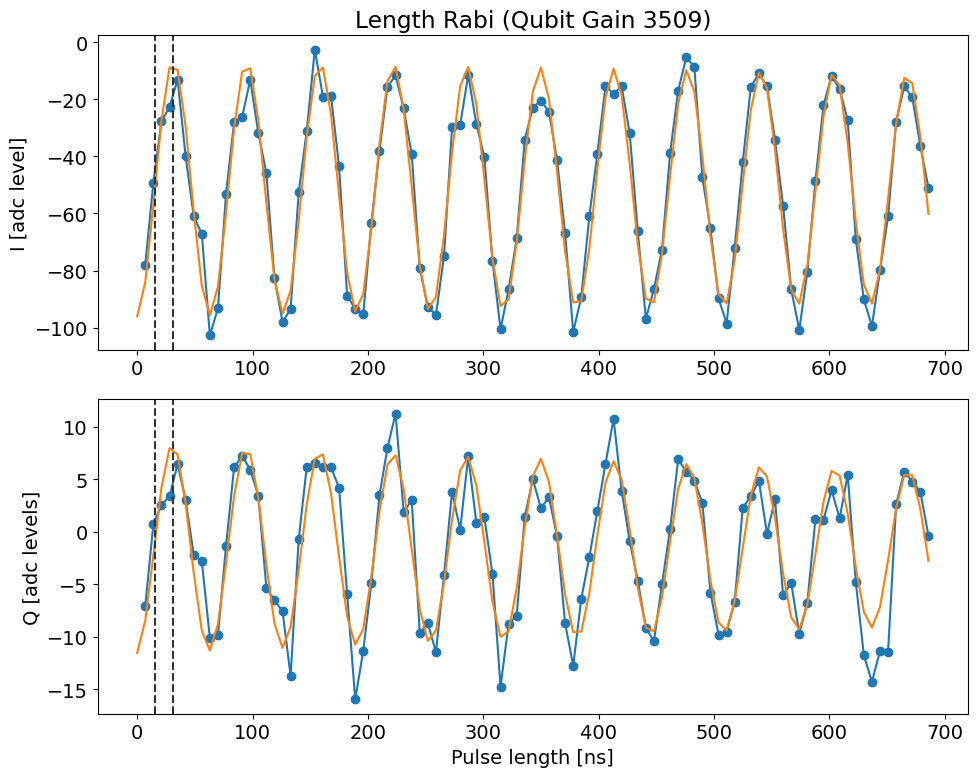

In [21]:
rabi = LengthRabiExperiment(
        soccfg=soc, 
        path=expt_path, 
        prefix='LengthRabiExperiment', 
        config_file=config_path
    )

rabi.cfg = AttrDict(deepcopy(config_thisrun))
rabi.cfg.expt = dict(
    start=0,                    # start delay
    step=0.007,                      # step size
    expts=100,                    # number of experiments
    reps=100,                      # repetitions
    rounds=1,                  # rounds
    qubits=[0],                  # qubits
    checkEF=False,                # check EF
    checkZZ=False,               # check ZZ
    pulse_type='const',        # pulse type
    repeat_time = 1,
    pre_pulse=False,       # pre pulse
    post_pulse=False,            # post pulse
)

rabi.cfg.device.readout.relax_delay = [500]
rabi.go(analyze=True, display=True, progress=True, save=True)

  0%|          | 0/21 [00:00<?, ?it/s]

Saving H:\Shared drives\SLab\Multimode\experiment\250812_qsim\data\00002_AmplitudeRabiChevronExperiment.h5


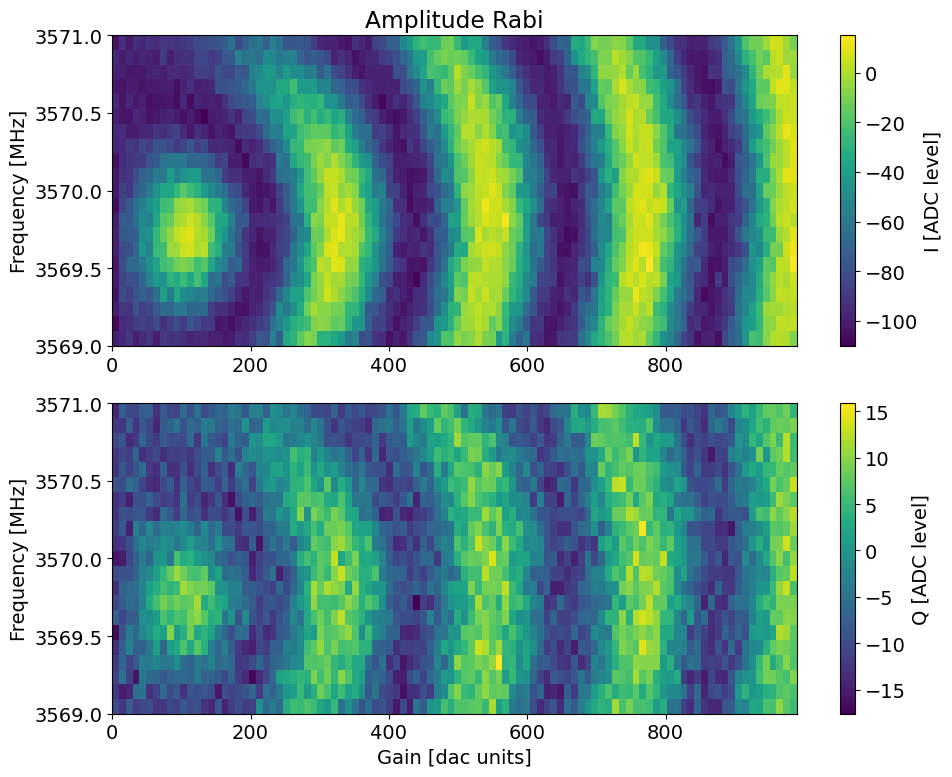

In [37]:
rabi = AmplitudeRabiChevronExperiment(
        soccfg=soc, 
        path=expt_path, 
        prefix='AmplitudeRabiChevronExperiment', 
        config_file=config_path
    )

rabi.cfg = AttrDict(deepcopy(config_thisrun))
rabi.cfg.expt = dict(
    start_f=3569,                # start frequency
    step_f=0.1,                 # f step size
    expts_f=21,                 # number of experiments
    start_gain=0,                    # start delay
    step_gain=10,                      # step size
    expts_gain=100,                    # number of experiments
    reps=100,                      # repetitions
    rounds=1,                  # rounds
    flat_length=0,
    sigma_test=1,
    user_defined_freq=[False,0],  # [on/off, freq]
    qubits=[0],                  # qubits
    checkEF=False,                # check EF
    checkZZ=False,                # check ZZ
    pulse_type='const',        # pulse type
    prepulse=False,       # pre pulse
    postpulse=False,            # post pulse
    pulse_ge_init=False,
    pulse_ge_after=False,
)

rabi.cfg.device.readout.relax_delay = [1500]
rabi.go(analyze=True, display=True, progress=True, save=True)

# Ramp current

In [20]:
# coupler
dcflux = YokogawaGS200(address="192.168.137.148")
dcflux.set_output(True)
dcflux.set_mode('current')
dcflux.ramp_current(0.5e-3, sweeprate=0.0001)

In [ ]:
# jpa
dcflux = YokogawaGS200(address="192.168.137.149")
dcflux.set_output(True)
dcflux.set_mode('current')
dcflux.ramp_current(0.000, sweeprate=0.002)

In [36]:
# jpa
dcflux = YokogawaGS200(address="192.168.137.149")
dcflux.ramp_current(-0.00454, sweeprate=0.002)

In [20]:
# jpa
dcflux = YokogawaGS200(address="192.168.137.149")
dcflux.ramp_current(0, sweeprate=0.002)

In [20]:
# coupler
dcflux = YokogawaGS200(address="192.168.137.148")
dcflux.ramp_current(0e-3, sweeprate=1e-4)

## Manipulate parity spectroscopy


In [23]:
def do_parity_freq_experiment(
    start=4960,
    stop=5020,
    step=0.60,
    reps=100,
    rounds=1,
    qubit=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=10000,
    span=20,
    manipulate_no=1,
    displace=(True, 0.1, 1000),
    const_pulse=(False, 1),
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500
):
    """
    Run the Parity Frequency Experiment with configurable parameters.
    """
    
    expt_cfg = {
        'start': start,
        'stop': stop,
        'step': step,
        'reps': reps,
        'rounds': rounds,
        'qubits': qubit,
        'normalize': normalize,
        'single_shot': single_shot,
        'singleshot_reps': singleshot_reps,
        'span': span,
        'manipulate': manipulate_no,
        'displace': list(displace),
        'const_pulse': list(const_pulse),
        'f0g1_cavity': f0g1_cavity,
        'prepulse': prepulse,
        'pre_sweep_pulse': pre_sweep_pulse
    }
    # Example usage of relax_delay in experiment config:
    parity_freq_exp = meas.single_qubit.parity_freq.ParityFreqExperiment(
        soccfg=soc, path=expt_path, 
        prefix='ParityFreqExperiment', config_file=config_file
    )
    parity_freq_exp.cfg = AttrDict(deepcopy(config_thisrun))
    parity_freq_exp.cfg.expt = expt_cfg
    parity_freq_exp.cfg.device.readout.relax_delay = [relax_delay]
    parity_freq_exp.go(analyze=False, display=False, progress=True, save=True)
    return parity_freq_exp


In [24]:
parity_freq_exp = do_parity_freq_experiment()

  0%|          | 0/100 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00095_ParityFreqExperiment.h5


Found peak in amps at [MHz] 4979.615462461978, HWHM 1.5240490397392101
Found peak in I at [MHz] 4979.549216957419, HWHM 2.2344682216010305
Found peak in Q at [MHz] 4983.343914390137, HWHM 13.55073301977434


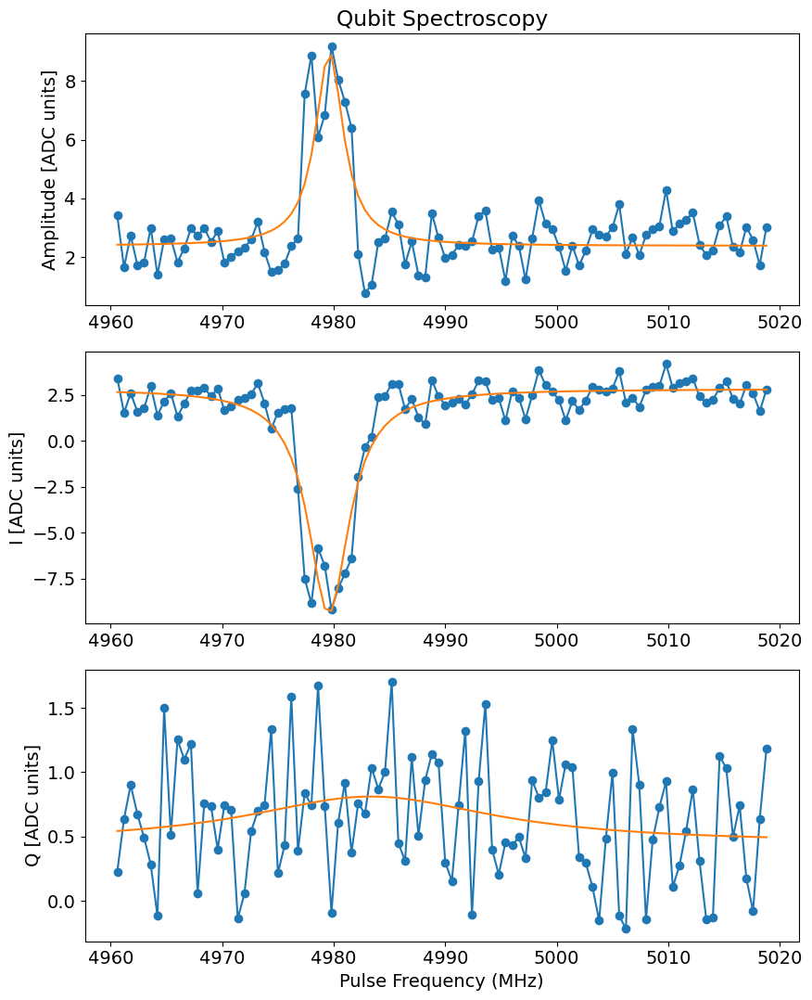

In [28]:
from fitting.fit_display_classes import Spectroscopy
spec = Spectroscopy(parity_freq_exp.data, config=parity_freq_exp.cfg)
spec.analyze()
spec.display()

In [23]:
config_thisrun.device.manipulate.f_ge[0] = spec.data['fit_avgi'][2]

## Gain to alpha

In [29]:
def do_parity_gain_experiment(
    config_thisrun,
    expt_path,
    config_path,
    start=0,
    step=100,
    expts=40,
    reps=250,
    rounds=1,
    qubit=0,
    qubits=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=1000,
    singleshot_active_reset=False,
    singleshot_man_reset=True,
    singleshot_storage_reset=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    span=1000,
    prep_e=False,
    manipulate=1,
    displace=(True, 0.05), # [enable, sigma] (gaussian length is 4sigma)
    const_pulse=(False, 1), # [enable, length]
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500, 
    pulse_correction=False
):
    """
    Run the Parity Gain Experiment with configurable parameters.
    """
    expt_cfg = {
        'start': start,
        'step': step,
        'expts': expts,
        'reps': reps,
        'rounds': rounds,
        'qubit': qubit,
        'qubits': qubits,
        'normalize': normalize,
        'single_shot': single_shot,
        'singleshot_reps': singleshot_reps,
        'singleshot_active_reset': singleshot_active_reset,
        'singleshot_man_reset': singleshot_man_reset,
        'singleshot_storage_reset': singleshot_storage_reset,
        'active_reset': active_reset,
        'man_reset': man_reset,
        'storage_reset': storage_reset,
        'span': span,
        'prep_e': prep_e,
        'manipulate': manipulate,
        'displace': list(displace),
        'const_pulse': list(const_pulse),
        'f0g1_cavity': f0g1_cavity,
        'prepulse': prepulse,
        'pre_sweep_pulse': pre_sweep_pulse if pre_sweep_pulse is not None else [],
        'pulse_correction': pulse_correction
    }
    parity_gain_exp = meas.single_qubit.parity_gain.ParityGainExperiment(
        soccfg=soc, path=expt_path, prefix='ParityGainExperiment', config_file=config_path
    )
    parity_gain_exp.cfg = AttrDict(deepcopy(config_thisrun))
    parity_gain_exp.cfg.expt = expt_cfg
    parity_gain_exp.cfg.device.readout.relax_delay = [relax_delay]
    
    parity_gain_exp.go(analyze=False, display=False, progress=True, save=True)
    return parity_gain_exp


4979.50248109926
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

4979.50248109926
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00331_ParityGainExperiment.h5
Gain to Alpha Conversion Factor: 0.0006606564470537082


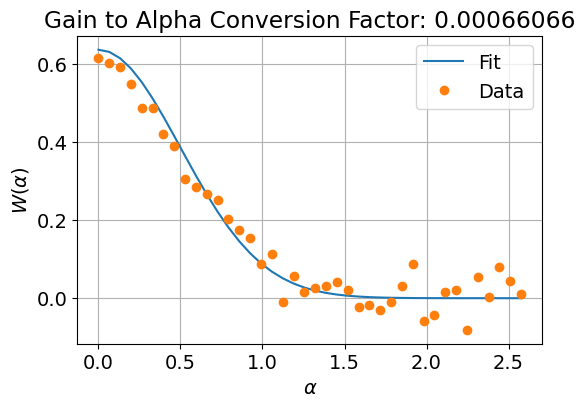

supertitle is  None
Plot saved to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs/plots\2025-11-21_14-06-49_Gain_to_Alpha_Conversion_Factor_0.00066066.png
Plot path appended to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs\2025-11-21.md
alpha = 1 requires gain of : 1513.64601747


{'xpts': array([   0,  100,  200,  300,  400,  500,  600,  700,  800,  900, 1000,
        1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100,
        2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200,
        3300, 3400, 3500, 3600, 3700, 3800, 3900,    0,  100,  200,  300,
         400,  500,  600,  700,  800,  900, 1000, 1100, 1200, 1300, 1400,
        1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500,
        2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600,
        3700, 3800, 3900]),
 'avgi': array([-19.67612554, -19.27963203, -19.61218615, -18.78654762,
        -17.2320671 , -16.32030303, -16.19962121, -16.01557359,
        -13.90439394, -13.85480519, -13.16258658, -13.53778139,
        -12.42669913, -11.36353896, -11.75844156, -10.27902597,
         -9.75880952,  -8.60227273,  -9.52790043,  -8.37634199,
         -9.70314935,  -9.29048701,  -9.54634199,  -7.76404762,
         -6.67811688,  -9.18925325,  -7.50772727,  -8.

In [30]:
parity_gain_expt = do_parity_gain_experiment(
    config_thisrun=config_thisrun,
    expt_path=expt_path,
    config_path=config_file,
    pulse_correction=True,
    reps=200,
)

parity_gain_expt.analyze()

In [26]:
#update device
gain_to_alpha = parity_gain_expt.data['gain_to_alpha']
print(f'Gain to alpha: {gain_to_alpha}')
config_thisrun.device.manipulate.gain_to_alpha[0] = gain_to_alpha

Gain to alpha: 0.00026453214215320896


### monitoring

Pulse correction is applied
4984.619558610203
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 200


  0%|          | 0/8000 [00:00<?, ?it/s]

4984.619558610203
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 0], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 200


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00228_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.00026365685319433124
alpha = 1 requires gain of : 3792.80867493
Pulse correction is applied
4984.619558610203
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 200


...

Saving D:\experiments\251031_qsim\data\00326_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.0002491632312560154
alpha = 1 requires gain of : 4013.43326204
Pulse correction is applied
4984.619558610203
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 200


  0%|          | 0/8000 [00:00<?, ?it/s]

4984.619558610203
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 0], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 200


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00327_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.00026881234012999963
alpha = 1 requires gain of : 3720.06731356


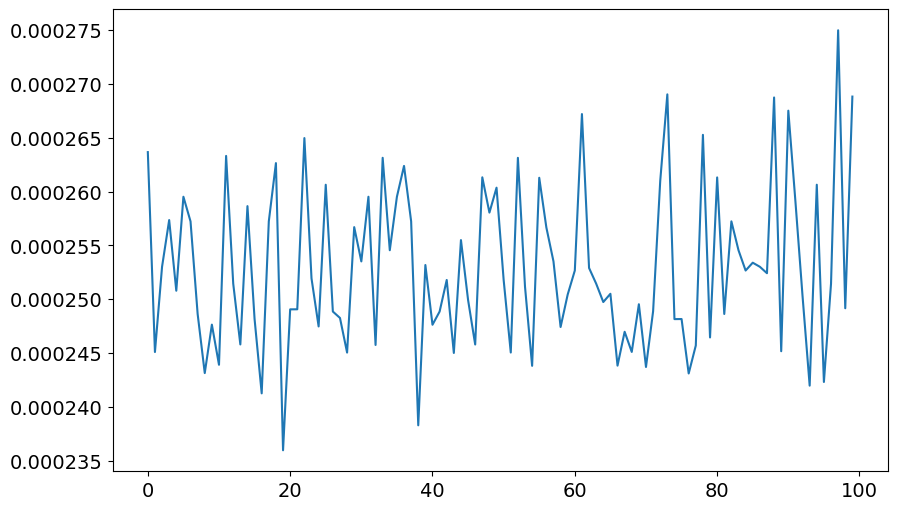

In [70]:
from time import sleep

all_gtas = []

for i in range(100):
    parity_gain_expt = do_parity_gain_experiment(
        config_thisrun=config_thisrun,
        expt_path=expt_path,
        config_path=config_file,
        pulse_correction=True,
        reps=200,
    )

    parity_gain_expt.analyze(plot=False)
    gain_to_alpha = parity_gain_expt.data['gain_to_alpha']
    all_gtas.append(gain_to_alpha)
    sleep(300)

plt.plot(all_gtas)

## nonlinearity vs flux bias

In [24]:
np.linspace(0.75e-3, 0.1e-3, 66)[:40]

array([0.00075, 0.00074, 0.00073, 0.00072, 0.00071, 0.0007 , 0.00069,
       0.00068, 0.00067, 0.00066, 0.00065, 0.00064, 0.00063, 0.00062,
       0.00061, 0.0006 , 0.00059, 0.00058, 0.00057, 0.00056, 0.00055,
       0.00054, 0.00053, 0.00052, 0.00051, 0.0005 , 0.00049, 0.00048,
       0.00047, 0.00046, 0.00045, 0.00044, 0.00043, 0.00042, 0.00041,
       0.0004 , 0.00039, 0.00038, 0.00037, 0.00036])

  0%|          | 0/100 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00075_ParityFreqExperiment.h5
Pulse correction is applied
5005.112257677008
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

5005.112257677008
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 0], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00002_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.0002949515473738482


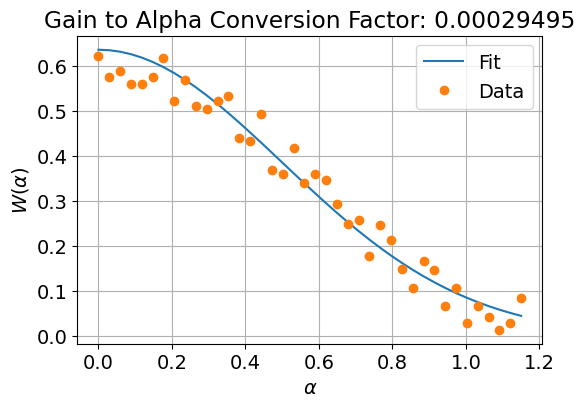

supertitle is  None
Plot saved to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs/plots\2025-11-04_23-36-42_Gain_to_Alpha_Conversion_Factor_0.00029495.png
Plot path appended to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs\2025-11-04.md
alpha = 1 requires gain of : 3390.38736668
Gain to alpha: 0.0002949515473738482


  0%|          | 0/16 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00123_KerrRamseyExperiment.h5


  0%|          | 0/100 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00076_ParityFreqExperiment.h5
Pulse correction is applied
5003.048330496247
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

5003.048330496247
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 0], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00003_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.0003011569859539486


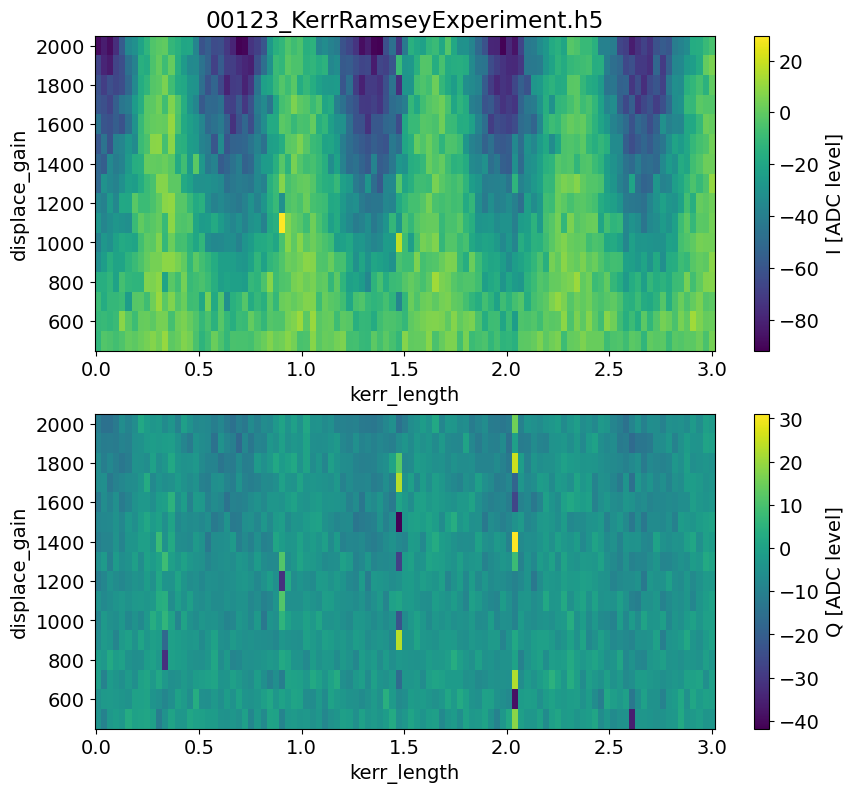

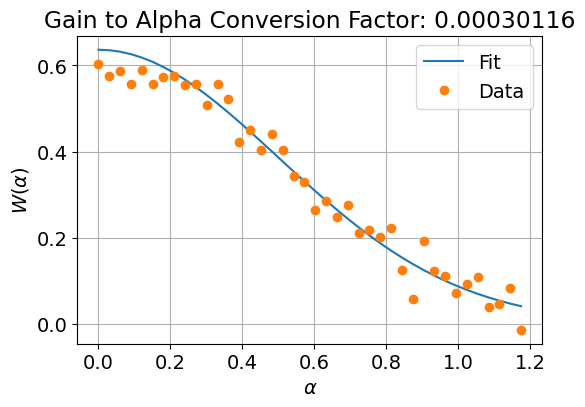

supertitle is  None
Plot saved to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs/plots\2025-11-04_23-50-48_Gain_to_Alpha_Conversion_Factor_0.00030116.png
Plot path appended to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs\2025-11-04.md
alpha = 1 requires gain of : 3320.52732176
Gain to alpha: 0.0003011569859539486


  0%|          | 0/16 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00124_KerrRamseyExperiment.h5


  0%|          | 0/100 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00077_ParityFreqExperiment.h5
Pulse correction is applied
5000.478613968114
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

5000.478613968114
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 0], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00004_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.0002814281053857867


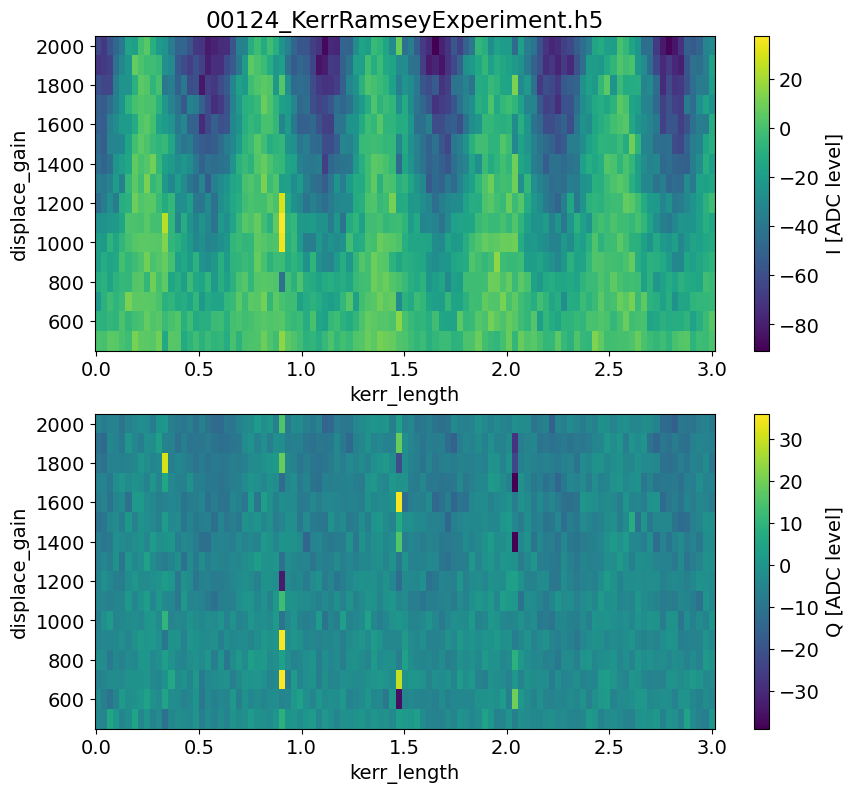

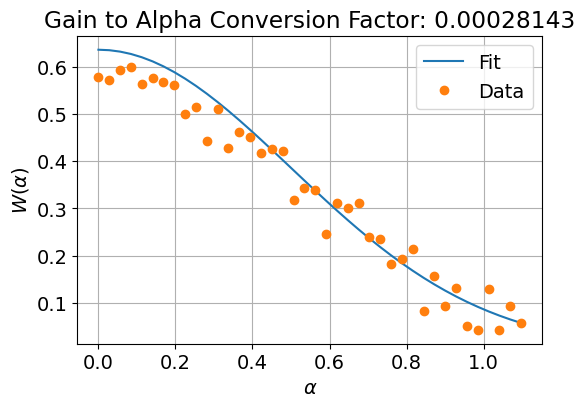

supertitle is  None
Plot saved to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs/plots\2025-11-05_00-05-17_Gain_to_Alpha_Conversion_Factor_0.00028143.png
Plot path appended to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs\2025-11-05.md
alpha = 1 requires gain of : 3553.30537662
Gain to alpha: 0.0002814281053857867


  0%|          | 0/16 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00125_KerrRamseyExperiment.h5


  0%|          | 0/100 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00078_ParityFreqExperiment.h5
Pulse correction is applied
4998.478183853273
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

4998.478183853273
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 0], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00005_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.000272831170696058


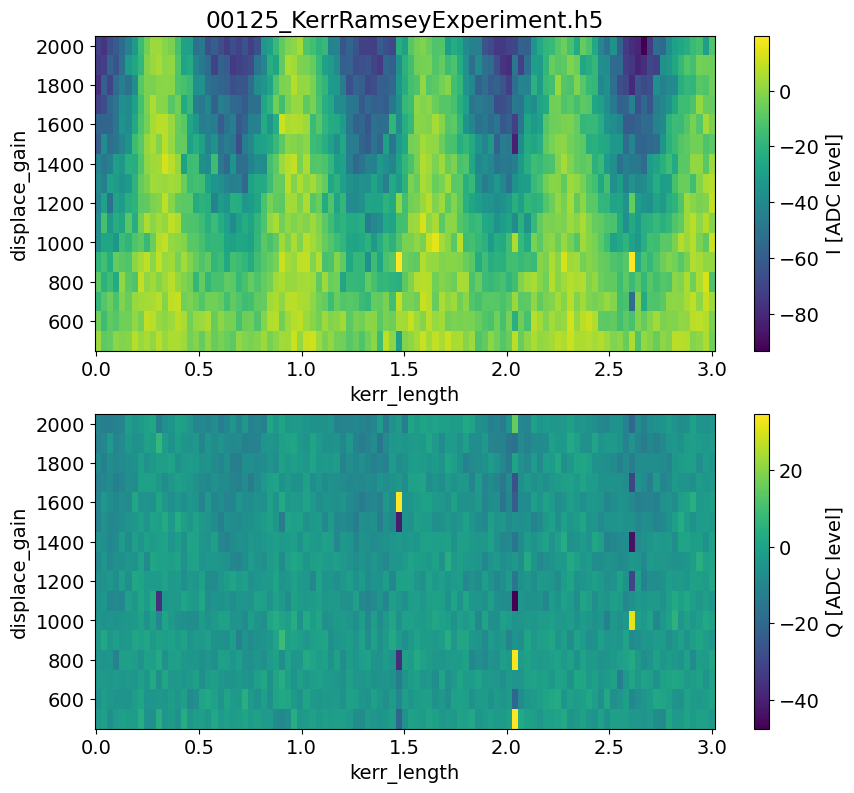

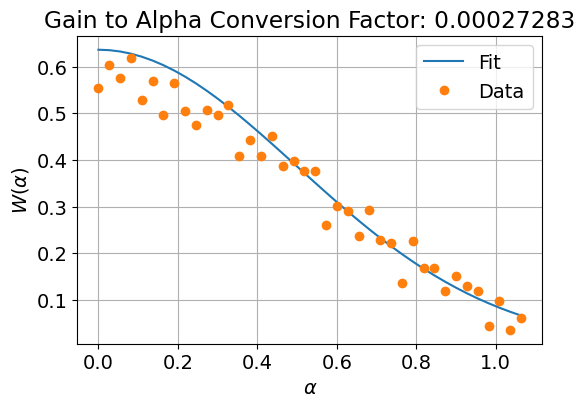

supertitle is  None
Plot saved to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs/plots\2025-11-05_00-19-48_Gain_to_Alpha_Conversion_Factor_0.00027283.png
Plot path appended to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs\2025-11-05.md
alpha = 1 requires gain of : 3665.27034814
Gain to alpha: 0.000272831170696058


  0%|          | 0/16 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00126_KerrRamseyExperiment.h5


  0%|          | 0/100 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00079_ParityFreqExperiment.h5
Pulse correction is applied
4995.866772755788
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

4995.866772755788
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 0], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00006_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.0002859405023926809


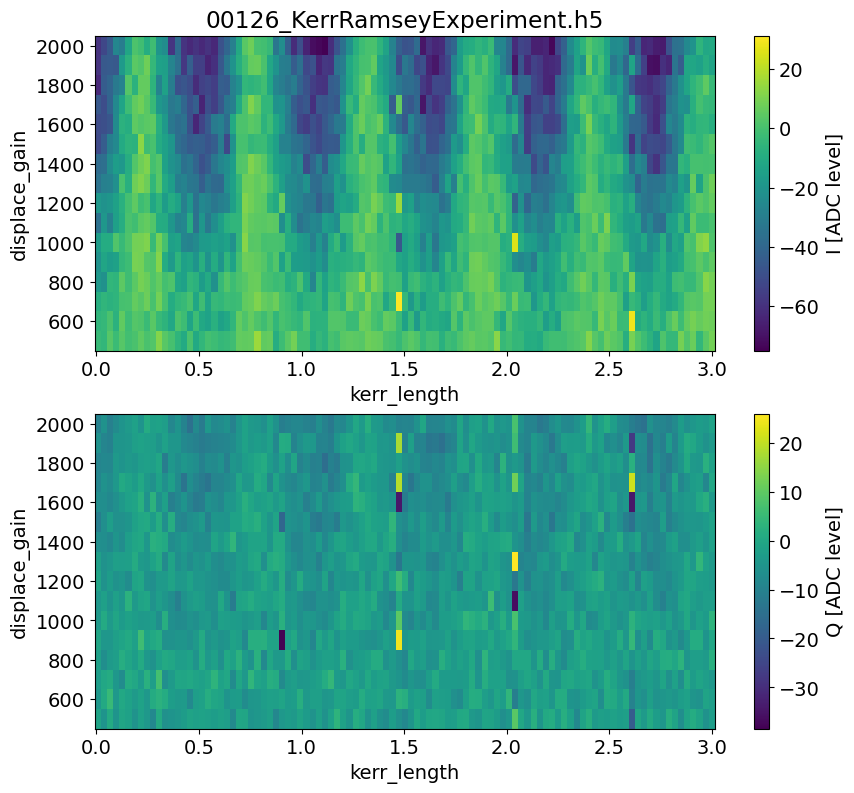

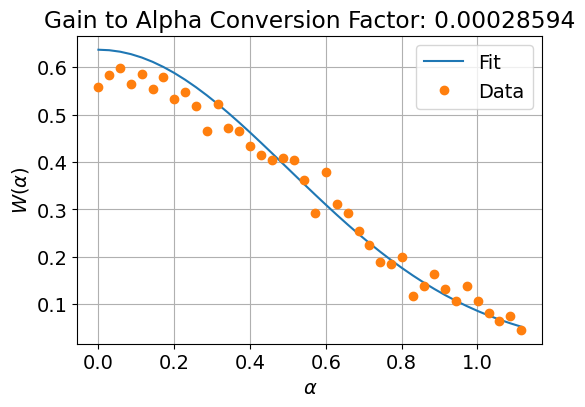

supertitle is  None
Plot saved to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs/plots\2025-11-05_00-34-17_Gain_to_Alpha_Conversion_Factor_0.00028594.png
Plot path appended to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs\2025-11-05.md
alpha = 1 requires gain of : 3497.23103804
Gain to alpha: 0.0002859405023926809


  0%|          | 0/16 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00127_KerrRamseyExperiment.h5


  0%|          | 0/100 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00080_ParityFreqExperiment.h5
Pulse correction is applied
4993.86402893229
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 180], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

4993.86402893229
parity pulse: [[3569.7124052990084, 3569.7124052990084, 3569.7124052990084], [1714, 0, 1714], [0.0, 1.6251210080098948, 0.0], [0, 0, 0], [2, 2, 2], ['gauss', 'const', 'gauss'], [0.035, 0.0, 0.035]]
Updating gain register 100


  0%|          | 0/8000 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00007_ParityGainExperiment.h5
(200, 40)
(200, 40)
Gain to Alpha Conversion Factor: 0.00030102387737308194


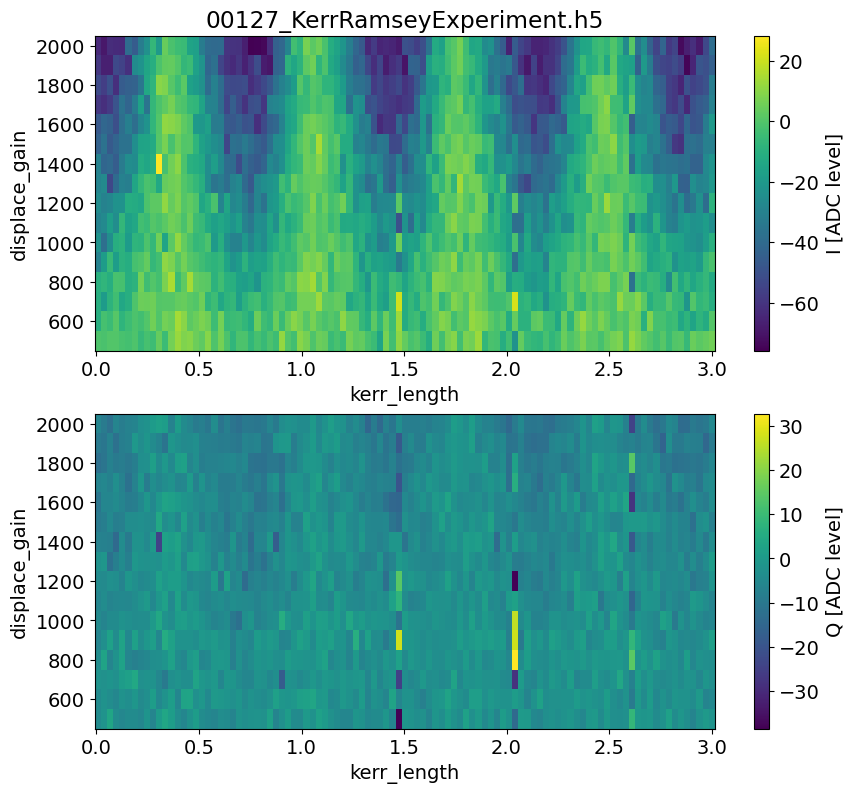

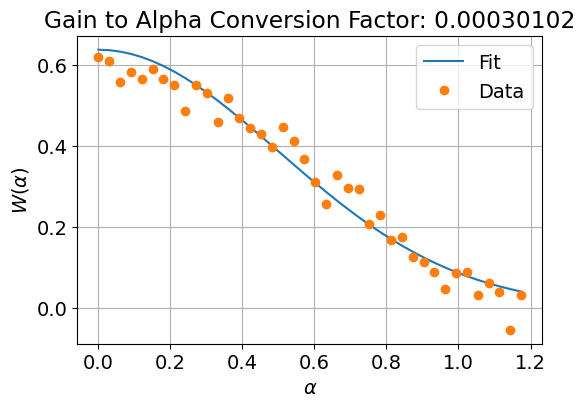

supertitle is  None
Plot saved to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs/plots\2025-11-05_00-48-49_Gain_to_Alpha_Conversion_Factor_0.00030102.png
Plot path appended to H:\Shared drives\SLab\Multimode\experiment\250505_craqm\data\plots_and_logs\2025-11-05.md
alpha = 1 requires gain of : 3321.99561286
Gain to alpha: 0.00030102387737308194


  0%|          | 0/16 [00:00<?, ?it/s]

Saving D:\experiments\251031_qsim\data\00128_KerrRamseyExperiment.h5


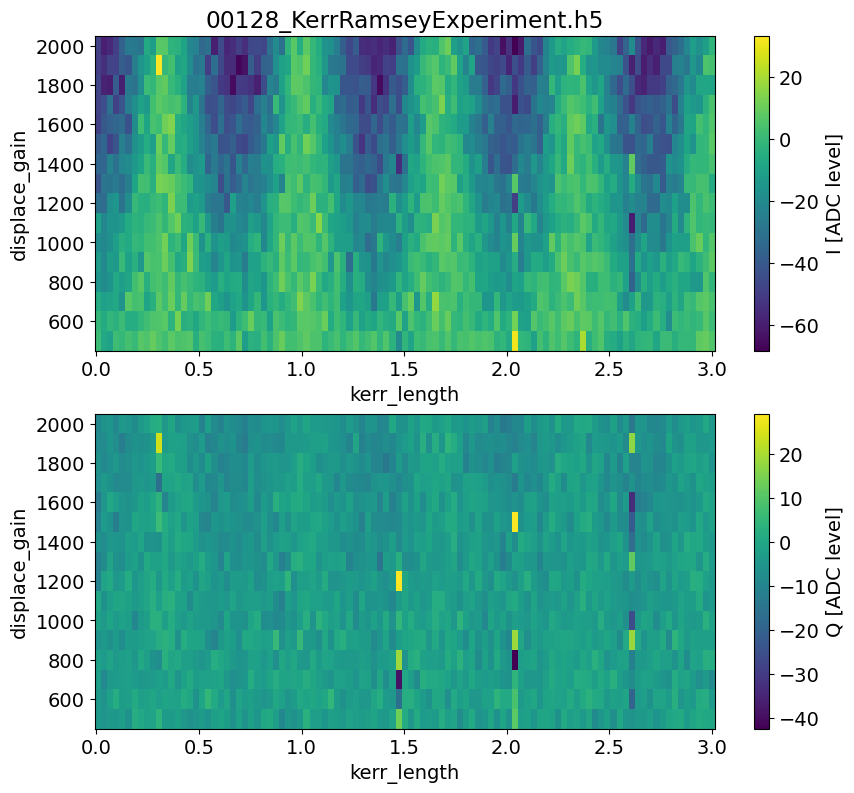

In [30]:
flux_currents = np.linspace(0, 0.15e-3, 6)
for flux_current in flux_currents:
    # set current
    dcflux.ramp_current(flux_current, sweeprate=1e-4)
    parity_freq_exp = do_parity_freq_experiment()

    # find manipulate f_ge
    spec = Spectroscopy(parity_freq_exp.data, config=parity_freq_exp.cfg)
    spec.analyze()
    config_thisrun.device.manipulate.f_ge[0] = spec.data['fit_avgi'][2]

    # calibrate parity to gain
    parity_gain_expt = do_parity_gain_experiment(
        config_thisrun=config_thisrun,
        expt_path=expt_path,
        config_path=config_file,
        pulse_correction=True,
        reps=200,
    )
    parity_gain_expt.analyze()
    gain_to_alpha = parity_gain_expt.data['gain_to_alpha']
    print(f'Gain to alpha: {gain_to_alpha}')
    config_thisrun.device.manipulate.gain_to_alpha[0] = gain_to_alpha
    
    # do cavity ramsey
    kerr_ramsey = do_kerr_ramsey(
        config_thisrun=config_thisrun,
        expt_path=expt_path,
        config_path=config_file,
        ramsey_freq=1.5,
        kerr_gain=0,
        # step = 0.04, 
        # expts = 150, 
        reps = 100,
        prep_e_first=False,
        # active_reset=True,
        # man_reset=True,
        # relax_delay=300,
    )